In [1]:
import os
import re
import copy
import joblib
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torch.multiprocessing as mp
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

mp.set_sharing_strategy("file_system")

# =========================
# Configuration
# =========================
#BASE_DIR = "/mnt/erencem-ozbey/ber_estimation"
BASE_DIR = "./"
DATA_PATH = os.path.join(BASE_DIR, "data_physics_with_variances_total.csv")

BEST_MODEL_SAVE_PATH = os.path.join(BASE_DIR, "ber_multiscale_rescnn_multiobjective_val_loss_best_stable.pth")
LAST_MODEL_SAVE_PATH = os.path.join(BASE_DIR, "ber_multiscale_rescnn_multiobjective_val_loss_last_stable.pth")
SCALER_SAVE_PATH = os.path.join(BASE_DIR, "ber_multiscale_rescnn_multiobjective_val_loss_stable_scalers.pkl")

EPS = 1e-12


# =========================
# Utilities
# =========================
def get_sorted_seq_cols(columns, prefix):
    pattern = re.compile(rf"^{re.escape(prefix)}_(\d+)$")
    matched = []
    for col in columns:
        m = pattern.match(col)
        if m:
            matched.append((int(m.group(1)), col))
    matched.sort(key=lambda x: x[0])
    return [col for _, col in matched]


def make_strat_bins(y_log, n_bins=10):
    """
    Build stratification bins from log10(BER).
    Falls back safely if quantile edges collapse.
    """
    y_flat = y_log.reshape(-1)
    quantiles = np.linspace(0, 1, n_bins + 1)
    edges = np.quantile(y_flat, quantiles)
    edges = np.unique(edges)

    if len(edges) < 3:
        return None

    bins = np.digitize(y_flat, edges[1:-1], right=True)
    counts = np.bincount(bins)
    if np.any(counts < 2):
        return None
    return bins


def has_nonfinite_tensor(x):
    return not torch.isfinite(x).all().item()


# =========================
# Stable Multi-objective Loss
# =========================
class StableMultiObjectiveBERLoss(nn.Module):
    """
    Stable multi-objective loss:
      - Huber loss in log10(BER) space
      - Huber loss in raw BER space
      - optional regime weighting based on raw BER

    Critical stability fix:
      pred_log is CLAMPED BEFORE conversion to raw BER to avoid overflow in 10**pred_log.
    """
    def __init__(
        self,
        log_delta=0.5,
        raw_delta=0.01,
        alpha_log=0.9,
        beta_raw=0.1,
        use_regime_weights=False,
        low_thr=1e-6,
        mid_thr=1e-3,
        w_low=1.0,
        w_mid=1.25,
        w_high=1.75,
        min_log_ber=-12.0,
        max_log_ber=0.0,
    ):
        super().__init__()
        self.log_delta = log_delta
        self.raw_delta = raw_delta
        self.alpha_log = alpha_log
        self.beta_raw = beta_raw

        self.use_regime_weights = use_regime_weights
        self.low_thr = low_thr
        self.mid_thr = mid_thr
        self.w_low = w_low
        self.w_mid = w_mid
        self.w_high = w_high

        self.min_log_ber = min_log_ber
        self.max_log_ber = max_log_ber

    @staticmethod
    def huber_elementwise(pred, target, delta):
        err = pred - target
        abs_err = err.abs()
        return torch.where(
            abs_err < delta,
            0.5 * err * err,
            delta * (abs_err - 0.5 * delta)
        )

    def forward(self, pred_log, target_log):
        # Log-space term uses the raw network output directly.
        log_loss = self.huber_elementwise(pred_log, target_log, self.log_delta)

        # Stability fix:
        # Clamp BEFORE conversion to raw BER so pow(10, pred_log) cannot overflow.
        pred_log_for_raw = pred_log.clamp(min=self.min_log_ber, max=self.max_log_ber)
        target_log_for_raw = target_log.clamp(min=self.min_log_ber, max=self.max_log_ber)

        pred_raw = torch.pow(10.0, pred_log_for_raw)
        target_raw = torch.pow(10.0, target_log_for_raw)

        raw_loss = self.huber_elementwise(pred_raw, target_raw, self.raw_delta)

        total = self.alpha_log * log_loss + self.beta_raw * raw_loss

        if self.use_regime_weights:
            weights = torch.full_like(target_raw, self.w_high)
            weights = torch.where(target_raw < self.mid_thr, torch.full_like(weights, self.w_mid), weights)
            weights = torch.where(target_raw < self.low_thr, torch.full_like(weights, self.w_low), weights)
            total = total * weights

        return total.mean()


# =========================
# Blocks
# =========================
class SqueezeExcite1D(nn.Module):
    def __init__(self, channels, reduction=8):
        super().__init__()
        hidden = max(channels // reduction, 8)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(
            nn.Conv1d(channels, hidden, kernel_size=1),
            nn.GELU(),
            nn.Conv1d(hidden, channels, kernel_size=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        scale = self.pool(x)
        scale = self.fc(scale)
        return x * scale


class ConvBNAct(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size, dilation=1, stride=1, groups=1):
        super().__init__()
        padding = ((kernel_size - 1) // 2) * dilation
        self.block = nn.Sequential(
            nn.Conv1d(
                in_ch, out_ch,
                kernel_size=kernel_size,
                stride=stride,
                padding=padding,
                dilation=dilation,
                groups=groups,
                bias=False
            ),
            nn.BatchNorm1d(out_ch),
            nn.GELU()
        )

    def forward(self, x):
        return self.block(x)


class MultiScaleResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.1, se=True):
        super().__init__()
        b1 = out_ch // 3
        b2 = out_ch // 3
        b3 = out_ch - b1 - b2

        self.branch1 = ConvBNAct(in_ch, b1, kernel_size=3, dilation=1)
        self.branch2 = ConvBNAct(in_ch, b2, kernel_size=5, dilation=1)
        self.branch3 = ConvBNAct(in_ch, b3, kernel_size=3, dilation=2)

        self.mix = nn.Sequential(
            nn.Conv1d(out_ch, out_ch, kernel_size=1, bias=False),
            nn.BatchNorm1d(out_ch),
            nn.GELU(),
            nn.Dropout(dropout)
        )

        self.se = SqueezeExcite1D(out_ch) if se else nn.Identity()

        self.skip = (
            nn.Sequential(
                nn.Conv1d(in_ch, out_ch, kernel_size=1, bias=False),
                nn.BatchNorm1d(out_ch)
            )
            if in_ch != out_ch else nn.Identity()
        )

        self.out_act = nn.GELU()

    def forward(self, x):
        residual = self.skip(x)
        out = torch.cat(
            [self.branch1(x), self.branch2(x), self.branch3(x)],
            dim=1
        )
        out = self.mix(out)
        out = self.se(out)
        out = out + residual
        out = self.out_act(out)
        return out


class DownsampleResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.1, se=True):
        super().__init__()
        self.pre = MultiScaleResidualBlock(in_ch, out_ch, dropout=dropout, se=se)
        self.down = nn.Sequential(
            nn.Conv1d(
                out_ch, out_ch,
                kernel_size=3,
                stride=2,
                padding=1,
                bias=False
            ),
            nn.BatchNorm1d(out_ch),
            nn.GELU()
        )

    def forward(self, x):
        x = self.pre(x)
        x = self.down(x)
        return x


class ThresholdFiLM(nn.Module):
    def __init__(self, threshold_dim, feature_dim, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(threshold_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, feature_dim * 2)
        )
        self.scale = nn.Parameter(torch.tensor(0.25, dtype=torch.float32))

    def forward(self, x, thr_emb):
        gamma_beta = self.net(thr_emb)
        gamma, beta = torch.chunk(gamma_beta, 2, dim=1)
        gamma = gamma.unsqueeze(-1)
        beta = beta.unsqueeze(-1)
        return x * (1.0 + self.scale * gamma) + self.scale * beta


class SequenceStem(nn.Module):
    def __init__(self, in_ch, stem_ch=32):
        super().__init__()
        self.net = nn.Sequential(
            ConvBNAct(in_ch, stem_ch, kernel_size=5),
            MultiScaleResidualBlock(stem_ch, stem_ch, dropout=0.05, se=True)
        )

    def forward(self, x):
        return self.net(x)


class LightSelfAttention1D(nn.Module):
    def __init__(self, dim, num_heads=4, mlp_ratio=2.0, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(
            embed_dim=dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )
        self.norm2 = nn.LayerNorm(dim)

        hidden = int(dim * mlp_ratio)
        self.mlp = nn.Sequential(
            nn.Linear(dim, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, dim),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        x_seq = x.transpose(1, 2)  # [B, L, C]
        y = self.norm1(x_seq)
        attn_out, _ = self.attn(y, y, y, need_weights=False)
        x_seq = x_seq + attn_out
        x_seq = x_seq + self.mlp(self.norm2(x_seq))
        return x_seq.transpose(1, 2)


class MultiHeadAttentionPooling(nn.Module):
    def __init__(self, input_dim, attn_dim=128, num_heads=4):
        super().__init__()
        self.score = nn.Sequential(
            nn.Conv1d(input_dim, attn_dim, kernel_size=1),
            nn.GELU(),
            nn.Conv1d(attn_dim, num_heads, kernel_size=1)
        )
        self.num_heads = num_heads
        self.input_dim = input_dim

    def forward(self, x):
        logits = self.score(x)
        weights = torch.softmax(logits, dim=-1)
        pooled = torch.einsum("bhl,bcl->bhc", weights, x)
        pooled = pooled.reshape(x.size(0), self.num_heads * self.input_dim)
        return pooled


class StagePooling(nn.Module):
    def __init__(self, channels, num_attn_heads=2, attn_dim=64):
        super().__init__()
        self.attn_pool = MultiHeadAttentionPooling(
            input_dim=channels,
            attn_dim=attn_dim,
            num_heads=num_attn_heads
        )
        self.out_dim = num_attn_heads * channels + 3 * channels

    def forward(self, x):
        attn = self.attn_pool(x)
        mean = x.mean(dim=-1)
        std = x.std(dim=-1, unbiased=False)
        maxv = x.amax(dim=-1)
        return torch.cat([attn, mean, std, maxv], dim=1)


# =========================
# Model
# =========================
class BERMultiScaleResCNNv2(nn.Module):
    """
    Input seq channels:
      0 -> scaled tap means
      1 -> scaled variances
      2 -> normalized position
      3 -> abs(scaled tap means)
      4 -> raw-ish log SNR proxy (scaled separately)

    Output:
      predicted log10(BER)
    """
    def __init__(
        self,
        threshold_dim=1,
        stem_ch=32,
        channels=(64, 96, 128),
        dropout=0.10,
        stage_pool_heads=(2, 2, 2, 4),
        attn_heads=4
    ):
        super().__init__()

        self.mean_stem = SequenceStem(in_ch=1, stem_ch=stem_ch)
        self.var_stem = SequenceStem(in_ch=1, stem_ch=stem_ch)

        self.extra_proj = nn.Sequential(
            nn.Conv1d(3, stem_ch, kernel_size=1, bias=False),
            nn.BatchNorm1d(stem_ch),
            nn.GELU()
        )

        fusion_in = stem_ch * 3

        self.thr_embed = nn.Sequential(
            nn.Linear(threshold_dim, 32),
            nn.GELU(),
            nn.Linear(32, 32),
            nn.GELU()
        )

        self.stage1 = MultiScaleResidualBlock(fusion_in, channels[0], dropout=dropout, se=True)
        self.film1 = ThresholdFiLM(32, channels[0], hidden_dim=64)

        self.stage2 = DownsampleResidualBlock(channels[0], channels[1], dropout=dropout, se=True)
        self.film2 = ThresholdFiLM(32, channels[1], hidden_dim=64)

        self.stage3 = DownsampleResidualBlock(channels[1], channels[2], dropout=dropout, se=True)
        self.film3 = ThresholdFiLM(32, channels[2], hidden_dim=64)

        self.self_attn = LightSelfAttention1D(
            dim=channels[2],
            num_heads=attn_heads,
            mlp_ratio=2.0,
            dropout=dropout
        )

        self.bottleneck = nn.Sequential(
            MultiScaleResidualBlock(channels[2], channels[2], dropout=dropout, se=True),
            MultiScaleResidualBlock(channels[2], channels[2], dropout=dropout, se=True),
        )

        self.pool1 = StagePooling(channels[0], num_attn_heads=stage_pool_heads[0], attn_dim=64)
        self.pool2 = StagePooling(channels[1], num_attn_heads=stage_pool_heads[1], attn_dim=64)
        self.pool3 = StagePooling(channels[2], num_attn_heads=stage_pool_heads[2], attn_dim=64)
        self.poolb = StagePooling(channels[2], num_attn_heads=stage_pool_heads[3], attn_dim=128)

        head_in = (
            self.pool1.out_dim +
            self.pool2.out_dim +
            self.pool3.out_dim +
            self.poolb.out_dim +
            32
        )

        self.head = nn.Sequential(
            nn.Linear(head_in, 512),
            nn.GELU(),
            nn.Dropout(0.20),
            nn.Linear(512, 256),
            nn.GELU(),
            nn.Dropout(0.15),
            nn.Linear(256, 128),
            nn.GELU(),
            nn.Linear(128, 1)
        )

    def forward(self, seq, threshold):
        mean_x = seq[:, 0:1, :]
        var_x = seq[:, 1:2, :]
        extra_x = seq[:, 2:5, :]

        mean_f = self.mean_stem(mean_x)
        var_f = self.var_stem(var_x)
        extra_f = self.extra_proj(extra_x)

        x = torch.cat([mean_f, var_f, extra_f], dim=1)
        thr = self.thr_embed(threshold)

        x1 = self.stage1(x)
        x1 = self.film1(x1, thr)

        x2 = self.stage2(x1)
        x2 = self.film2(x2, thr)

        x3 = self.stage3(x2)
        x3 = self.film3(x3, thr)

        x3 = self.self_attn(x3)
        xb = self.bottleneck(x3)

        p1 = self.pool1(x1)
        p2 = self.pool2(x2)
        p3 = self.pool3(x3)
        pb = self.poolb(xb)

        fused = torch.cat([p1, p2, p3, pb, thr], dim=1)
        return self.head(fused)


# =========================
# Data
# =========================
def prepare_data(csv_path, batch_size=256, nrows=5000000, num_workers=0):
    df = pd.read_csv(csv_path, nrows=nrows)

    if "mem_len" not in df.columns:
        raise ValueError("Required column 'mem_len' not found.")

    df = df[df["mem_len"] != 1].copy()

    tap_cols = get_sorted_seq_cols(df.columns, "tap")
    var_cols = get_sorted_seq_cols(df.columns, "var")

    if not tap_cols:
        raise ValueError("No tap_* columns found.")
    if not var_cols:
        raise ValueError("No var_* columns found.")
    if len(tap_cols) != len(var_cols):
        raise ValueError(
            f"tap/var length mismatch: {len(tap_cols)} tap cols vs {len(var_cols)} var cols"
        )

    required_cols = tap_cols + var_cols + ["threshold", "BER"]
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    df[tap_cols] = df[tap_cols].fillna(0.0)
    df[var_cols] = df[var_cols].fillna(0.0)
    df["threshold"] = df["threshold"].fillna(0.0)
    df["BER"] = df["BER"].fillna(0.0)

    df = df[(df["threshold"] > 0) & (df["BER"] > 0)].copy()

    X_taps_raw = df[tap_cols].to_numpy(dtype=np.float32)
    X_vars_raw = df[var_cols].to_numpy(dtype=np.float32)

    X_thr_raw = df["threshold"].to_numpy(dtype=np.float32).reshape(-1, 1)
    y_raw = df["BER"].to_numpy(dtype=np.float32).reshape(-1, 1)

    X_thr = np.log10(X_thr_raw + EPS).astype(np.float32)
    y_log = np.log10(y_raw + EPS).astype(np.float32)

    if np.all(X_vars_raw >= 0):
        X_vars_feat = np.log10(X_vars_raw + EPS).astype(np.float32)
    else:
        X_vars_feat = X_vars_raw.astype(np.float32)

    if np.all(X_vars_raw >= 0):
        snr_raw = np.log10((X_taps_raw ** 2) / (X_vars_raw + 1e-12) + 1e-12).astype(np.float32)
    else:
        snr_raw = np.log10((X_taps_raw ** 2) / (np.abs(X_vars_raw) + 1e-12) + 1e-12).astype(np.float32)

    abs_taps_raw = np.abs(X_taps_raw).astype(np.float32)

    strat_labels = make_strat_bins(y_log, n_bins=10)

    split_args = dict(test_size=0.30, random_state=42)
    if strat_labels is not None:
        split_args["stratify"] = strat_labels

    (
        t_taps_raw, temp_taps_raw,
        t_vars_feat, temp_vars_feat,
        t_abs_raw, temp_abs_raw,
        t_snr_raw, temp_snr_raw,
        t_thr, temp_thr,
        t_y_log, temp_y_log
    ) = train_test_split(
        X_taps_raw, X_vars_feat, abs_taps_raw, snr_raw, X_thr, y_log,
        **split_args
    )

    temp_strat = make_strat_bins(temp_y_log, n_bins=6)

    split_args2 = dict(test_size=0.50, random_state=42)
    if temp_strat is not None:
        split_args2["stratify"] = temp_strat

    (
        v_taps_raw, te_taps_raw,
        v_vars_feat, te_vars_feat,
        v_abs_raw, te_abs_raw,
        v_snr_raw, te_snr_raw,
        v_thr, te_thr,
        v_y_log, te_y_log
    ) = train_test_split(
        temp_taps_raw, temp_vars_feat, temp_abs_raw, temp_snr_raw, temp_thr, temp_y_log,
        **split_args2
    )

    tap_scaler = StandardScaler()
    var_scaler = StandardScaler()
    abs_scaler = StandardScaler()
    snr_scaler = StandardScaler()
    thr_scaler = StandardScaler()

    t_taps = tap_scaler.fit_transform(t_taps_raw).astype(np.float32)
    v_taps = tap_scaler.transform(v_taps_raw).astype(np.float32)
    te_taps = tap_scaler.transform(te_taps_raw).astype(np.float32)

    t_vars = var_scaler.fit_transform(t_vars_feat).astype(np.float32)
    v_vars = var_scaler.transform(v_vars_feat).astype(np.float32)
    te_vars = var_scaler.transform(te_vars_feat).astype(np.float32)

    t_abs = abs_scaler.fit_transform(t_abs_raw).astype(np.float32)
    v_abs = abs_scaler.transform(v_abs_raw).astype(np.float32)
    te_abs = abs_scaler.transform(te_abs_raw).astype(np.float32)

    t_snr = snr_scaler.fit_transform(t_snr_raw).astype(np.float32)
    v_snr = snr_scaler.transform(v_snr_raw).astype(np.float32)
    te_snr = snr_scaler.transform(te_snr_raw).astype(np.float32)

    t_thr = thr_scaler.fit_transform(t_thr).astype(np.float32)
    v_thr = thr_scaler.transform(v_thr).astype(np.float32)
    te_thr = thr_scaler.transform(te_thr).astype(np.float32)

    L = t_taps.shape[1]
    pos = np.linspace(0.0, 1.0, L, dtype=np.float32)

    def build_features(taps_scaled, vars_scaled, abs_scaled, snr_scaled):
        pos_ch = np.tile(pos, (taps_scaled.shape[0], 1)).astype(np.float32)
        seq = np.stack(
            [taps_scaled, vars_scaled, pos_ch, abs_scaled, snr_scaled],
            axis=1
        ).astype(np.float32)
        return seq

    t_seq = build_features(t_taps, t_vars, t_abs, t_snr)
    v_seq = build_features(v_taps, v_vars, v_abs, v_snr)
    te_seq = build_features(te_taps, te_vars, te_abs, te_snr)

    train_ds = TensorDataset(
        torch.from_numpy(t_seq),
        torch.from_numpy(t_thr),
        torch.from_numpy(t_y_log)
    )
    val_ds = TensorDataset(
        torch.from_numpy(v_seq),
        torch.from_numpy(v_thr),
        torch.from_numpy(v_y_log)
    )
    test_ds = TensorDataset(
        torch.from_numpy(te_seq),
        torch.from_numpy(te_thr),
        torch.from_numpy(te_y_log)
    )

    pin_mem = torch.cuda.is_available()

    train_loader = DataLoader(
        train_ds,
        batch_size=batch_size,
        shuffle=True,
        pin_memory=pin_mem,
        num_workers=num_workers
    )
    val_loader = DataLoader(
        val_ds,
        batch_size=batch_size,
        shuffle=False,
        pin_memory=pin_mem,
        num_workers=num_workers
    )
    test_loader = DataLoader(
        test_ds,
        batch_size=batch_size,
        shuffle=False,
        pin_memory=pin_mem,
        num_workers=num_workers
    )

    scalers = {
        "tap_scaler": tap_scaler,
        "var_scaler": var_scaler,
        "abs_scaler": abs_scaler,
        "snr_scaler": snr_scaler,
        "thr_scaler": thr_scaler,
        "tap_cols": tap_cols,
        "var_cols": var_cols,
        "seq_channels": 5,
        "feature_order": ["tap", "var", "pos", "abs_tap", "snr_proxy_log"],
    }

    return train_loader, val_loader, test_loader, scalers, len(tap_cols)


# =========================
# Evaluation
# =========================
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_preds_log = []
    all_targets_log = []

    with torch.no_grad():
        for b_seq, b_thr, b_y_log in loader:
            b_seq = b_seq.to(device, non_blocking=True)
            b_thr = b_thr.to(device, non_blocking=True)
            b_y_log = b_y_log.to(device, non_blocking=True)

            pred_log = model(b_seq, b_thr)

            if has_nonfinite_tensor(pred_log):
                raise RuntimeError("Non-finite prediction detected during evaluation.")

            loss = criterion(pred_log, b_y_log)

            if has_nonfinite_tensor(loss):
                raise RuntimeError("Non-finite loss detected during evaluation.")

            total_loss += loss.item()
            all_preds_log.append(pred_log.cpu().numpy())
            all_targets_log.append(b_y_log.cpu().numpy())

    avg_loss = total_loss / max(len(loader), 1)

    preds_log = np.vstack(all_preds_log)
    targets_log = np.vstack(all_targets_log)

    preds_raw = np.clip(10 ** np.clip(preds_log, -12.0, 0.0), EPS, 1.0)
    targets_raw = np.clip(10 ** np.clip(targets_log, -12.0, 0.0), EPS, 1.0)

    rmse_log = float(np.sqrt(np.mean((preds_log - targets_log) ** 2)))
    mae_log = float(np.mean(np.abs(preds_log - targets_log)))
    factor_error = float(10 ** rmse_log)

    rmse_raw = float(np.sqrt(np.mean((preds_raw - targets_raw) ** 2)))
    mae_raw = float(np.mean(np.abs(preds_raw - targets_raw)))

    return avg_loss, rmse_log, mae_log, factor_error, rmse_raw, mae_raw


def evaluate_by_target_range(model, loader, device):
    model.eval()
    all_preds_log = []
    all_targets_log = []

    with torch.no_grad():
        for b_seq, b_thr, b_y_log in loader:
            b_seq = b_seq.to(device, non_blocking=True)
            b_thr = b_thr.to(device, non_blocking=True)
            pred_log = model(b_seq, b_thr)

            if has_nonfinite_tensor(pred_log):
                raise RuntimeError("Non-finite prediction detected during per-range evaluation.")

            all_preds_log.append(pred_log.cpu().numpy())
            all_targets_log.append(b_y_log.numpy())

    preds_log = np.vstack(all_preds_log).reshape(-1)
    targets_log = np.vstack(all_targets_log).reshape(-1)

    preds_raw = np.clip(10 ** np.clip(preds_log, -12.0, 0.0), EPS, 1.0)
    targets_raw = np.clip(10 ** np.clip(targets_log, -12.0, 0.0), EPS, 1.0)

    ranges = {
        "low_BER(y<1e-6)": targets_raw < 1e-6,
        "mid_BER(1e-6<=y<1e-3)": (targets_raw >= 1e-6) & (targets_raw < 1e-3),
        "high_BER(y>=1e-3)": targets_raw >= 1e-3,
    }

    metrics = {}
    for name, mask in ranges.items():
        if np.any(mask):
            rmse_log = float(np.sqrt(np.mean((preds_log[mask] - targets_log[mask]) ** 2)))
            mae_log = float(np.mean(np.abs(preds_log[mask] - targets_log[mask])))
            rmse_raw = float(np.sqrt(np.mean((preds_raw[mask] - targets_raw[mask]) ** 2)))
            mae_raw = float(np.mean(np.abs(preds_raw[mask] - targets_raw[mask])))

            metrics[name] = {
                "count": int(mask.sum()),
                "rmse_log": rmse_log,
                "mae_log": mae_log,
                "factor_error": float(10 ** rmse_log),
                "rmse_raw": rmse_raw,
                "mae_raw": mae_raw,
            }
        else:
            metrics[name] = None

    return metrics


# =========================
# Training
# =========================
def train_engine():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Executing on: {device}")

    train_loader, val_loader, test_loader, scalers, seq_len = prepare_data(
        DATA_PATH,
        batch_size=256,
        nrows=500000,
        num_workers=0
    )

    joblib.dump(scalers, SCALER_SAVE_PATH)

    model = BERMultiScaleResCNNv2(
        threshold_dim=1,
        stem_ch=32,
        channels=(64, 96, 128),
        dropout=0.10,
        stage_pool_heads=(2, 2, 2, 4),
        attn_heads=4
    ).to(device)

    # Slightly lower LR for extra stability
    optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)

    criterion = StableMultiObjectiveBERLoss(
        log_delta=0.5,
        raw_delta=0.01,
        alpha_log=0.9,
        beta_raw=0.1,
        use_regime_weights=False,
        low_thr=1e-6,
        mid_thr=1e-3,
        w_low=1.0,
        w_mid=1.25,
        w_high=1.75,
        min_log_ber=-12.0,
        max_log_ber=0.0,
    )

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        patience=4,
        factor=0.5
    )

    best_val_loss = float("inf")
    best_state = None
    patience = 12
    wait = 0
    min_epochs_before_early_stop = 60

    print(f"Detected sequence length L = {seq_len}")

    training_broke = False

    for epoch in range(100):
        model.train()

        for batch_idx, (b_seq, b_thr, b_y_log) in enumerate(train_loader):
            b_seq = b_seq.to(device, non_blocking=True)
            b_thr = b_thr.to(device, non_blocking=True)
            b_y_log = b_y_log.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            pred_log = model(b_seq, b_thr)
            if has_nonfinite_tensor(pred_log):
                print(f"Non-finite prediction detected at epoch {epoch+1}, batch {batch_idx+1}.")
                training_broke = True
                break

            loss = criterion(pred_log, b_y_log)
            if has_nonfinite_tensor(loss):
                print(f"Non-finite loss detected at epoch {epoch+1}, batch {batch_idx+1}.")
                training_broke = True
                break

            loss.backward()

            # Tighter clipping for stability
            grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            if not torch.isfinite(grad_norm):
                print(f"Non-finite gradient norm detected at epoch {epoch+1}, batch {batch_idx+1}.")
                training_broke = True
                break

            optimizer.step()

            # Catch parameter corruption immediately
            bad_param = False
            for name, param in model.named_parameters():
                if param.requires_grad and param.data is not None and not torch.isfinite(param.data).all():
                    print(f"Non-finite parameter detected after optimizer step: {name}")
                    bad_param = True
                    break
            if bad_param:
                training_broke = True
                break

        if training_broke:
            print("Training stopped because non-finite values were detected.")
            break

        try:
            train_loss, train_rmse_log, train_mae_log, train_factor, train_rmse_raw, train_mae_raw = evaluate(
                model, train_loader, criterion, device
            )
            val_loss, val_rmse_log, val_mae_log, val_factor, val_rmse_raw, val_mae_raw = evaluate(
                model, val_loader, criterion, device
            )
        except RuntimeError as e:
            print(f"Evaluation failed at epoch {epoch+1}: {e}")
            break

        scheduler.step(val_loss)
        current_lr = optimizer.param_groups[0]["lr"]

        print(
            f"Epoch {epoch+1:03d} | "
            f"LR: {current_lr:.2e} | "
            f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
            f"Train RMSE(log10): {train_rmse_log:.4f} (~{train_factor:.2f}x) | "
            f"Val RMSE(log10): {val_rmse_log:.4f} (~{val_factor:.2f}x) | "
            f"Train MAE(log10): {train_mae_log:.4f} | Val MAE(log10): {val_mae_log:.4f} | "
            f"Train MAE(raw): {train_mae_raw:.6f} | Val MAE(raw): {val_mae_raw:.6f}"
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
            print(f"  -> New best model saved at epoch {epoch+1} with Val Loss: {val_loss:.6f}")
        else:
            if epoch + 1 >= min_epochs_before_early_stop:
                wait += 1
                if wait >= patience:
                    print("Early stopping triggered.")
                    break

    # Save last model state, whether or not it is best
    torch.save(model.state_dict(), LAST_MODEL_SAVE_PATH)
    print(f"Last model saved to: {LAST_MODEL_SAVE_PATH}")

    if best_state is not None:
        model.load_state_dict(best_state)
        torch.save(model.state_dict(), BEST_MODEL_SAVE_PATH)
        print(f"Best model saved to: {BEST_MODEL_SAVE_PATH}")
    else:
        print("Warning: no valid best checkpoint was found.")

    test_loss, test_rmse_log, test_mae_log, test_factor, test_rmse_raw, test_mae_raw = evaluate(
        model, test_loader, criterion, device
    )

    print(
        f"Test Loss: {test_loss:.4f} | "
        f"Test RMSE(log10): {test_rmse_log:.4f} | "
        f"Test MAE(log10): {test_mae_log:.4f} | "
        f"Typical multiplicative error: ~{test_factor:.2f}x | "
        f"Test RMSE(raw): {test_rmse_raw:.6f} | "
        f"Test MAE(raw): {test_mae_raw:.6f}"
    )

    range_metrics = evaluate_by_target_range(model, test_loader, device)
    print("\nPer-range test diagnostics:")
    for name, stats in range_metrics.items():
        if stats is None:
            print(f"{name}: no samples")
        else:
            print(
                f"{name} | count={stats['count']} | "
                f"RMSE(log10)={stats['rmse_log']:.4f} | "
                f"MAE(log10)={stats['mae_log']:.4f} | "
                f"factor~{stats['factor_error']:.2f}x | "
                f"RMSE(raw)={stats['rmse_raw']:.6f} | "
                f"MAE(raw)={stats['mae_raw']:.6f}"
            )

    return model


if __name__ == "__main__":
    os.makedirs(BASE_DIR, exist_ok=True)

    if os.path.exists(DATA_PATH):
        print(f"Reading data from: {DATA_PATH}")
        trained_model = train_engine()
        print(f"Scalers saved to: {SCALER_SAVE_PATH}")
    else:
        print(f"Critical Error: Data file not found at {DATA_PATH}")


Reading data from: ./data_physics_with_variances_total.csv
Executing on: cuda
Detected sequence length L = 14
Epoch 001 | LR: 1.00e-04 | Train Loss: 0.2729 | Val Loss: 0.2646 | Train RMSE(log10): 2.0027 (~100.63x) | Val RMSE(log10): 1.9514 (~89.41x) | Train MAE(log10): 0.7445 | Val MAE(log10): 0.7260 | Train MAE(raw): 0.064538 | Val MAE(raw): 0.063569
  -> New best model saved at epoch 1 with Val Loss: 0.264610
Epoch 002 | LR: 1.00e-04 | Train Loss: 0.2094 | Val Loss: 0.2081 | Train RMSE(log10): 1.8113 (~64.76x) | Val RMSE(log10): 1.8104 (~64.62x) | Train MAE(log10): 0.5768 | Val MAE(log10): 0.5751 | Train MAE(raw): 0.034731 | Val MAE(raw): 0.034887
  -> New best model saved at epoch 2 with Val Loss: 0.208068
Epoch 003 | LR: 1.00e-04 | Train Loss: 0.1553 | Val Loss: 0.1565 | Train RMSE(log10): 1.4870 (~30.69x) | Val RMSE(log10): 1.4983 (~31.50x) | Train MAE(log10): 0.4515 | Val MAE(log10): 0.4544 | Train MAE(raw): 0.046025 | Val MAE(raw): 0.045870
  -> New best model saved at epoch 3 w

Epoch 032 | LR: 2.50e-05 | Train Loss: 0.0365 | Val Loss: 0.0375 | Train RMSE(log10): 0.4629 (~2.90x) | Val RMSE(log10): 0.4860 (~3.06x) | Train MAE(log10): 0.1623 | Val MAE(log10): 0.1644 | Train MAE(raw): 0.017242 | Val MAE(raw): 0.017139
  -> New best model saved at epoch 32 with Val Loss: 0.037527
Epoch 033 | LR: 2.50e-05 | Train Loss: 0.0619 | Val Loss: 0.0615 | Train RMSE(log10): 0.7474 (~5.59x) | Val RMSE(log10): 0.7494 (~5.62x) | Train MAE(log10): 0.2235 | Val MAE(log10): 0.2225 | Train MAE(raw): 0.018267 | Val MAE(raw): 0.018251
Epoch 034 | LR: 2.50e-05 | Train Loss: 0.0633 | Val Loss: 0.0632 | Train RMSE(log10): 0.7131 (~5.17x) | Val RMSE(log10): 0.7194 (~5.24x) | Train MAE(log10): 0.2184 | Val MAE(log10): 0.2178 | Train MAE(raw): 0.017419 | Val MAE(raw): 0.017410
Epoch 035 | LR: 2.50e-05 | Train Loss: 0.0650 | Val Loss: 0.0658 | Train RMSE(log10): 0.7401 (~5.50x) | Val RMSE(log10): 0.7532 (~5.67x) | Train MAE(log10): 0.2357 | Val MAE(log10): 0.2373 | Train MAE(raw): 0.018112

Epoch 065 | LR: 7.81e-07 | Train Loss: 0.0363 | Val Loss: 0.0373 | Train RMSE(log10): 0.5106 (~3.24x) | Val RMSE(log10): 0.5319 (~3.40x) | Train MAE(log10): 0.1653 | Val MAE(log10): 0.1674 | Train MAE(raw): 0.015409 | Val MAE(raw): 0.015407
Epoch 066 | LR: 7.81e-07 | Train Loss: 0.0409 | Val Loss: 0.0415 | Train RMSE(log10): 0.4896 (~3.09x) | Val RMSE(log10): 0.5069 (~3.21x) | Train MAE(log10): 0.1790 | Val MAE(log10): 0.1800 | Train MAE(raw): 0.016673 | Val MAE(raw): 0.016684
Epoch 067 | LR: 7.81e-07 | Train Loss: 0.0396 | Val Loss: 0.0405 | Train RMSE(log10): 0.5374 (~3.45x) | Val RMSE(log10): 0.5579 (~3.61x) | Train MAE(log10): 0.1745 | Val MAE(log10): 0.1762 | Train MAE(raw): 0.016692 | Val MAE(raw): 0.016697
Epoch 068 | LR: 7.81e-07 | Train Loss: 0.0436 | Val Loss: 0.0442 | Train RMSE(log10): 0.5659 (~3.68x) | Val RMSE(log10): 0.5869 (~3.86x) | Train MAE(log10): 0.1840 | Val MAE(log10): 0.1854 | Train MAE(raw): 0.016532 | Val MAE(raw): 0.016523
Epoch 069 | LR: 7.81e-07 | Train Los

In [2]:
import os
import re
import copy
import joblib
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torch.multiprocessing as mp
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

mp.set_sharing_strategy("file_system")

# =========================
# Configuration
# =========================
BASE_DIR = "./"
DATA_PATH = os.path.join(BASE_DIR, "data_physics_with_variances_total.csv")

BEST_MODEL_SAVE_PATH = os.path.join(
    BASE_DIR, "ber_multiscale_rescnn_firstflag_posemb_best.pth"
)
LAST_MODEL_SAVE_PATH = os.path.join(
    BASE_DIR, "ber_multiscale_rescnn_firstflag_posemb_last.pth"
)
SCALER_SAVE_PATH = os.path.join(
    BASE_DIR, "ber_multiscale_rescnn_firstflag_posemb_scalers.pkl"
)

EPS = 1e-12
MIN_LOG_BER = -12.0
MAX_LOG_BER = 0.0


# =========================
# Utilities
# =========================
def get_sorted_seq_cols(columns, prefix):
    pattern = re.compile(rf"^{re.escape(prefix)}_(\d+)$")
    matched = []
    for col in columns:
        m = pattern.match(col)
        if m:
            matched.append((int(m.group(1)), col))
    matched.sort(key=lambda x: x[0])
    return [col for _, col in matched]


def make_strat_bins(y_log, n_bins=10):
    """
    Build stratification bins from log10(BER).
    Falls back safely if quantile edges collapse.
    """
    y_flat = y_log.reshape(-1)
    quantiles = np.linspace(0, 1, n_bins + 1)
    edges = np.quantile(y_flat, quantiles)
    edges = np.unique(edges)

    if len(edges) < 3:
        return None

    bins = np.digitize(y_flat, edges[1:-1], right=True)
    counts = np.bincount(bins)
    if np.any(counts < 2):
        return None
    return bins


def has_nonfinite_tensor(x):
    return not torch.isfinite(x).all().item()


def bounded_log10_output(raw_out, min_log_ber=MIN_LOG_BER, max_log_ber=MAX_LOG_BER):
    """
    Smoothly bounds model output into [min_log_ber, max_log_ber].
    """
    return min_log_ber + (max_log_ber - min_log_ber) * torch.sigmoid(raw_out)


# =========================
# Stable Multi-objective Loss
# =========================
class StableMultiObjectiveBERLoss(nn.Module):
    """
    Multi-objective loss:
      - Huber loss in log10(BER) space
      - Huber loss in raw BER space
      - optional regime weighting based on raw BER

    Since the model output is already bounded into [min_log_ber, max_log_ber],
    the raw conversion is stable by construction.
    """
    def __init__(
        self,
        log_delta=0.5,
        raw_delta=0.01,
        alpha_log=0.9,
        beta_raw=0.1,
        use_regime_weights=False,
        low_thr=1e-6,
        mid_thr=1e-3,
        w_low=1.0,
        w_mid=1.25,
        w_high=1.75,
        min_log_ber=MIN_LOG_BER,
        max_log_ber=MAX_LOG_BER,
    ):
        super().__init__()
        self.log_delta = log_delta
        self.raw_delta = raw_delta
        self.alpha_log = alpha_log
        self.beta_raw = beta_raw

        self.use_regime_weights = use_regime_weights
        self.low_thr = low_thr
        self.mid_thr = mid_thr
        self.w_low = w_low
        self.w_mid = w_mid
        self.w_high = w_high

        self.min_log_ber = min_log_ber
        self.max_log_ber = max_log_ber

    @staticmethod
    def huber_elementwise(pred, target, delta):
        err = pred - target
        abs_err = err.abs()
        return torch.where(
            abs_err < delta,
            0.5 * err * err,
            delta * (abs_err - 0.5 * delta)
        )

    def forward(self, pred_log, target_log):
        pred_log = pred_log.clamp(min=self.min_log_ber, max=self.max_log_ber)
        target_log = target_log.clamp(min=self.min_log_ber, max=self.max_log_ber)

        log_loss = self.huber_elementwise(pred_log, target_log, self.log_delta)

        pred_raw = torch.pow(10.0, pred_log)
        target_raw = torch.pow(10.0, target_log)

        raw_loss = self.huber_elementwise(pred_raw, target_raw, self.raw_delta)

        total = self.alpha_log * log_loss + self.beta_raw * raw_loss

        if self.use_regime_weights:
            weights = torch.full_like(target_raw, self.w_high)
            weights = torch.where(
                target_raw < self.mid_thr,
                torch.full_like(weights, self.w_mid),
                weights
            )
            weights = torch.where(
                target_raw < self.low_thr,
                torch.full_like(weights, self.w_low),
                weights
            )
            total = total * weights

        return total.mean()


# =========================
# Blocks
# =========================
class SqueezeExcite1D(nn.Module):
    def __init__(self, channels, reduction=8):
        super().__init__()
        hidden = max(channels // reduction, 8)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(
            nn.Conv1d(channels, hidden, kernel_size=1),
            nn.GELU(),
            nn.Conv1d(hidden, channels, kernel_size=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        scale = self.pool(x)
        scale = self.fc(scale)
        return x * scale


class ConvBNAct(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size, dilation=1, stride=1, groups=1):
        super().__init__()
        padding = ((kernel_size - 1) // 2) * dilation
        self.block = nn.Sequential(
            nn.Conv1d(
                in_ch, out_ch,
                kernel_size=kernel_size,
                stride=stride,
                padding=padding,
                dilation=dilation,
                groups=groups,
                bias=False
            ),
            nn.BatchNorm1d(out_ch),
            nn.GELU()
        )

    def forward(self, x):
        return self.block(x)


class MultiScaleResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.1, se=True):
        super().__init__()
        b1 = out_ch // 3
        b2 = out_ch // 3
        b3 = out_ch - b1 - b2

        self.branch1 = ConvBNAct(in_ch, b1, kernel_size=3, dilation=1)
        self.branch2 = ConvBNAct(in_ch, b2, kernel_size=5, dilation=1)
        self.branch3 = ConvBNAct(in_ch, b3, kernel_size=3, dilation=2)

        self.mix = nn.Sequential(
            nn.Conv1d(out_ch, out_ch, kernel_size=1, bias=False),
            nn.BatchNorm1d(out_ch),
            nn.GELU(),
            nn.Dropout(dropout)
        )

        self.se = SqueezeExcite1D(out_ch) if se else nn.Identity()

        self.skip = (
            nn.Sequential(
                nn.Conv1d(in_ch, out_ch, kernel_size=1, bias=False),
                nn.BatchNorm1d(out_ch)
            )
            if in_ch != out_ch else nn.Identity()
        )

        self.out_act = nn.GELU()

    def forward(self, x):
        residual = self.skip(x)
        out = torch.cat(
            [self.branch1(x), self.branch2(x), self.branch3(x)],
            dim=1
        )
        out = self.mix(out)
        out = self.se(out)
        out = out + residual
        out = self.out_act(out)
        return out


class DownsampleResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.1, se=True):
        super().__init__()
        self.pre = MultiScaleResidualBlock(in_ch, out_ch, dropout=dropout, se=se)
        self.down = nn.Sequential(
            nn.Conv1d(
                out_ch, out_ch,
                kernel_size=3,
                stride=2,
                padding=1,
                bias=False
            ),
            nn.BatchNorm1d(out_ch),
            nn.GELU()
        )

    def forward(self, x):
        x = self.pre(x)
        x = self.down(x)
        return x


class ThresholdFiLM(nn.Module):
    def __init__(self, threshold_dim, feature_dim, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(threshold_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, feature_dim * 2)
        )
        self.scale = nn.Parameter(torch.tensor(0.25, dtype=torch.float32))

    def forward(self, x, thr_emb):
        gamma_beta = self.net(thr_emb)
        gamma, beta = torch.chunk(gamma_beta, 2, dim=1)
        gamma = gamma.unsqueeze(-1)
        beta = beta.unsqueeze(-1)
        return x * (1.0 + self.scale * gamma) + self.scale * beta


class SequenceStem(nn.Module):
    def __init__(self, in_ch, stem_ch=32):
        super().__init__()
        self.net = nn.Sequential(
            ConvBNAct(in_ch, stem_ch, kernel_size=5),
            MultiScaleResidualBlock(stem_ch, stem_ch, dropout=0.05, se=True)
        )

    def forward(self, x):
        return self.net(x)


class LightSelfAttention1D(nn.Module):
    def __init__(self, dim, num_heads=4, mlp_ratio=2.0, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(
            embed_dim=dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )
        self.norm2 = nn.LayerNorm(dim)

        hidden = int(dim * mlp_ratio)
        self.mlp = nn.Sequential(
            nn.Linear(dim, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, dim),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        x_seq = x.transpose(1, 2)  # [B, L, C]
        y = self.norm1(x_seq)
        attn_out, _ = self.attn(y, y, y, need_weights=False)
        x_seq = x_seq + attn_out
        x_seq = x_seq + self.mlp(self.norm2(x_seq))
        return x_seq.transpose(1, 2)


class MultiHeadAttentionPooling(nn.Module):
    def __init__(self, input_dim, attn_dim=128, num_heads=4):
        super().__init__()
        self.score = nn.Sequential(
            nn.Conv1d(input_dim, attn_dim, kernel_size=1),
            nn.GELU(),
            nn.Conv1d(attn_dim, num_heads, kernel_size=1)
        )
        self.num_heads = num_heads
        self.input_dim = input_dim

    def forward(self, x):
        logits = self.score(x)
        weights = torch.softmax(logits, dim=-1)
        pooled = torch.einsum("bhl,bcl->bhc", weights, x)
        pooled = pooled.reshape(x.size(0), self.num_heads * self.input_dim)
        return pooled


class StagePooling(nn.Module):
    def __init__(self, channels, num_attn_heads=2, attn_dim=64):
        super().__init__()
        self.attn_pool = MultiHeadAttentionPooling(
            input_dim=channels,
            attn_dim=attn_dim,
            num_heads=num_attn_heads
        )
        self.out_dim = num_attn_heads * channels + 3 * channels

    def forward(self, x):
        attn = self.attn_pool(x)
        mean = x.mean(dim=-1)
        std = x.std(dim=-1, unbiased=False)
        maxv = x.amax(dim=-1)
        return torch.cat([attn, mean, std, maxv], dim=1)


# =========================
# Model
# =========================
class BERMultiScaleResCNNv3(nn.Module):
    """
    Input seq channels:
      0 -> scaled tap means
      1 -> scaled variances
      2 -> normalized position
      3 -> abs(scaled tap means)
      4 -> raw-ish log SNR proxy (scaled separately)
      5 -> first-position indicator

    In addition:
      learned absolute positional embedding is concatenated inside the model.

    Output:
      predicted log10(BER), bounded to [MIN_LOG_BER, MAX_LOG_BER]
    """
    def __init__(
        self,
        seq_len,
        threshold_dim=1,
        stem_ch=32,
        channels=(64, 96, 128),
        dropout=0.10,
        stage_pool_heads=(2, 2, 2, 4),
        attn_heads=4,
        pos_emb_dim=8,
        min_log_ber=MIN_LOG_BER,
        max_log_ber=MAX_LOG_BER,
    ):
        super().__init__()

        self.seq_len = seq_len
        self.pos_emb_dim = pos_emb_dim
        self.min_log_ber = min_log_ber
        self.max_log_ber = max_log_ber

        self.mean_stem = SequenceStem(in_ch=1, stem_ch=stem_ch)
        self.var_stem = SequenceStem(in_ch=1, stem_ch=stem_ch)

        # extra channels now:
        # normalized position, abs tap, snr proxy, first-flag
        self.extra_proj = nn.Sequential(
            nn.Conv1d(4, stem_ch, kernel_size=1, bias=False),
            nn.BatchNorm1d(stem_ch),
            nn.GELU()
        )

        # learned absolute positional embedding
        self.pos_embedding = nn.Parameter(
            torch.randn(1, pos_emb_dim, seq_len) * 0.02
        )

        self.pos_emb_proj = nn.Sequential(
            nn.Conv1d(pos_emb_dim, stem_ch, kernel_size=1, bias=False),
            nn.BatchNorm1d(stem_ch),
            nn.GELU()
        )

        fusion_in = stem_ch * 4

        self.thr_embed = nn.Sequential(
            nn.Linear(threshold_dim, 32),
            nn.GELU(),
            nn.Linear(32, 32),
            nn.GELU()
        )

        self.stage1 = MultiScaleResidualBlock(
            fusion_in, channels[0], dropout=dropout, se=True
        )
        self.film1 = ThresholdFiLM(32, channels[0], hidden_dim=64)

        self.stage2 = DownsampleResidualBlock(
            channels[0], channels[1], dropout=dropout, se=True
        )
        self.film2 = ThresholdFiLM(32, channels[1], hidden_dim=64)

        self.stage3 = DownsampleResidualBlock(
            channels[1], channels[2], dropout=dropout, se=True
        )
        self.film3 = ThresholdFiLM(32, channels[2], hidden_dim=64)

        self.self_attn = LightSelfAttention1D(
            dim=channels[2],
            num_heads=attn_heads,
            mlp_ratio=2.0,
            dropout=dropout
        )

        self.bottleneck = nn.Sequential(
            MultiScaleResidualBlock(channels[2], channels[2], dropout=dropout, se=True),
            MultiScaleResidualBlock(channels[2], channels[2], dropout=dropout, se=True),
        )

        self.pool1 = StagePooling(
            channels[0], num_attn_heads=stage_pool_heads[0], attn_dim=64
        )
        self.pool2 = StagePooling(
            channels[1], num_attn_heads=stage_pool_heads[1], attn_dim=64
        )
        self.pool3 = StagePooling(
            channels[2], num_attn_heads=stage_pool_heads[2], attn_dim=64
        )
        self.poolb = StagePooling(
            channels[2], num_attn_heads=stage_pool_heads[3], attn_dim=128
        )

        head_in = (
            self.pool1.out_dim +
            self.pool2.out_dim +
            self.pool3.out_dim +
            self.poolb.out_dim +
            32
        )

        self.head = nn.Sequential(
            nn.Linear(head_in, 512),
            nn.GELU(),
            nn.Dropout(0.20),
            nn.Linear(512, 256),
            nn.GELU(),
            nn.Dropout(0.15),
            nn.Linear(256, 128),
            nn.GELU(),
            nn.Linear(128, 1)
        )

    def forward(self, seq, threshold):
        mean_x = seq[:, 0:1, :]
        var_x = seq[:, 1:2, :]
        extra_x = seq[:, 2:6, :]  # pos, abs, snr, first-flag

        mean_f = self.mean_stem(mean_x)
        var_f = self.var_stem(var_x)
        extra_f = self.extra_proj(extra_x)

        pos_emb = self.pos_embedding.expand(seq.size(0), -1, -1)
        pos_f = self.pos_emb_proj(pos_emb)

        x = torch.cat([mean_f, var_f, extra_f, pos_f], dim=1)
        thr = self.thr_embed(threshold)

        x1 = self.stage1(x)
        x1 = self.film1(x1, thr)

        x2 = self.stage2(x1)
        x2 = self.film2(x2, thr)

        x3 = self.stage3(x2)
        x3 = self.film3(x3, thr)

        x3 = self.self_attn(x3)
        xb = self.bottleneck(x3)

        p1 = self.pool1(x1)
        p2 = self.pool2(x2)
        p3 = self.pool3(x3)
        pb = self.poolb(xb)

        fused = torch.cat([p1, p2, p3, pb, thr], dim=1)

        raw_out = self.head(fused)
        pred_log = bounded_log10_output(
            raw_out,
            min_log_ber=self.min_log_ber,
            max_log_ber=self.max_log_ber
        )
        return pred_log


# =========================
# Data
# =========================
def prepare_data(csv_path, batch_size=256, nrows=500000, num_workers=0):
    df = pd.read_csv(csv_path, nrows=nrows)

    if "mem_len" not in df.columns:
        raise ValueError("Required column 'mem_len' not found.")

    df = df[df["mem_len"] != 1].copy()

    tap_cols = get_sorted_seq_cols(df.columns, "tap")
    var_cols = get_sorted_seq_cols(df.columns, "var")

    if not tap_cols:
        raise ValueError("No tap_* columns found.")
    if not var_cols:
        raise ValueError("No var_* columns found.")
    if len(tap_cols) != len(var_cols):
        raise ValueError(
            f"tap/var length mismatch: {len(tap_cols)} tap cols vs {len(var_cols)} var cols"
        )

    required_cols = tap_cols + var_cols + ["threshold", "BER"]
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    df[tap_cols] = df[tap_cols].fillna(0.0)
    df[var_cols] = df[var_cols].fillna(0.0)
    df["threshold"] = df["threshold"].fillna(0.0)
    df["BER"] = df["BER"].fillna(0.0)

    df = df[(df["threshold"] > 0) & (df["BER"] > 0)].copy()

    X_taps_raw = df[tap_cols].to_numpy(dtype=np.float32)
    X_vars_raw = df[var_cols].to_numpy(dtype=np.float32)
    X_thr_raw = df["threshold"].to_numpy(dtype=np.float32).reshape(-1, 1)
    y_raw = df["BER"].to_numpy(dtype=np.float32).reshape(-1, 1)

    X_thr = np.log10(X_thr_raw + EPS).astype(np.float32)
    y_log = np.log10(y_raw + EPS).astype(np.float32)
    y_log = np.clip(y_log, MIN_LOG_BER, MAX_LOG_BER)

    if np.all(X_vars_raw >= 0):
        X_vars_feat = np.log10(X_vars_raw + EPS).astype(np.float32)
    else:
        X_vars_feat = X_vars_raw.astype(np.float32)

    if np.all(X_vars_raw >= 0):
        snr_raw = np.log10(
            (X_taps_raw ** 2) / (X_vars_raw + 1e-12) + 1e-12
        ).astype(np.float32)
    else:
        snr_raw = np.log10(
            (X_taps_raw ** 2) / (np.abs(X_vars_raw) + 1e-12) + 1e-12
        ).astype(np.float32)

    # Robustify extreme SNR tails
    snr_raw = np.clip(snr_raw, -20.0, 20.0)

    abs_taps_raw = np.abs(X_taps_raw).astype(np.float32)

    strat_labels = make_strat_bins(y_log, n_bins=10)

    split_args = dict(test_size=0.30, random_state=42)
    if strat_labels is not None:
        split_args["stratify"] = strat_labels

    (
        t_taps_raw, temp_taps_raw,
        t_vars_feat, temp_vars_feat,
        t_abs_raw, temp_abs_raw,
        t_snr_raw, temp_snr_raw,
        t_thr, temp_thr,
        t_y_log, temp_y_log
    ) = train_test_split(
        X_taps_raw, X_vars_feat, abs_taps_raw, snr_raw, X_thr, y_log,
        **split_args
    )

    temp_strat = make_strat_bins(temp_y_log, n_bins=6)

    split_args2 = dict(test_size=0.50, random_state=42)
    if temp_strat is not None:
        split_args2["stratify"] = temp_strat

    (
        v_taps_raw, te_taps_raw,
        v_vars_feat, te_vars_feat,
        v_abs_raw, te_abs_raw,
        v_snr_raw, te_snr_raw,
        v_thr, te_thr,
        v_y_log, te_y_log
    ) = train_test_split(
        temp_taps_raw, temp_vars_feat, temp_abs_raw, temp_snr_raw, temp_thr, temp_y_log,
        **split_args2
    )

    tap_scaler = StandardScaler()
    var_scaler = StandardScaler()
    abs_scaler = StandardScaler()
    snr_scaler = StandardScaler()
    thr_scaler = StandardScaler()

    t_taps = tap_scaler.fit_transform(t_taps_raw).astype(np.float32)
    v_taps = tap_scaler.transform(v_taps_raw).astype(np.float32)
    te_taps = tap_scaler.transform(te_taps_raw).astype(np.float32)

    t_vars = var_scaler.fit_transform(t_vars_feat).astype(np.float32)
    v_vars = var_scaler.transform(v_vars_feat).astype(np.float32)
    te_vars = var_scaler.transform(te_vars_feat).astype(np.float32)

    t_abs = abs_scaler.fit_transform(t_abs_raw).astype(np.float32)
    v_abs = abs_scaler.transform(v_abs_raw).astype(np.float32)
    te_abs = abs_scaler.transform(te_abs_raw).astype(np.float32)

    t_snr = snr_scaler.fit_transform(t_snr_raw).astype(np.float32)
    v_snr = snr_scaler.transform(v_snr_raw).astype(np.float32)
    te_snr = snr_scaler.transform(te_snr_raw).astype(np.float32)

    t_thr = thr_scaler.fit_transform(t_thr).astype(np.float32)
    v_thr = thr_scaler.transform(v_thr).astype(np.float32)
    te_thr = thr_scaler.transform(te_thr).astype(np.float32)

    L = t_taps.shape[1]
    pos = np.linspace(0.0, 1.0, L, dtype=np.float32)

    def build_features(taps_scaled, vars_scaled, abs_scaled, snr_scaled):
        n = taps_scaled.shape[0]

        pos_ch = np.tile(pos, (n, 1)).astype(np.float32)

        first_flag = np.zeros((n, L), dtype=np.float32)
        first_flag[:, 0] = 1.0

        seq = np.stack(
            [
                taps_scaled,
                vars_scaled,
                pos_ch,
                abs_scaled,
                snr_scaled,
                first_flag,
            ],
            axis=1
        ).astype(np.float32)

        return seq

    t_seq = build_features(t_taps, t_vars, t_abs, t_snr)
    v_seq = build_features(v_taps, v_vars, v_abs, v_snr)
    te_seq = build_features(te_taps, te_vars, te_abs, te_snr)

    train_ds = TensorDataset(
        torch.from_numpy(t_seq),
        torch.from_numpy(t_thr),
        torch.from_numpy(t_y_log)
    )
    val_ds = TensorDataset(
        torch.from_numpy(v_seq),
        torch.from_numpy(v_thr),
        torch.from_numpy(v_y_log)
    )
    test_ds = TensorDataset(
        torch.from_numpy(te_seq),
        torch.from_numpy(te_thr),
        torch.from_numpy(te_y_log)
    )

    pin_mem = torch.cuda.is_available()

    train_loader = DataLoader(
        train_ds,
        batch_size=batch_size,
        shuffle=True,
        pin_memory=pin_mem,
        num_workers=num_workers
    )
    val_loader = DataLoader(
        val_ds,
        batch_size=batch_size,
        shuffle=False,
        pin_memory=pin_mem,
        num_workers=num_workers
    )
    test_loader = DataLoader(
        test_ds,
        batch_size=batch_size,
        shuffle=False,
        pin_memory=pin_mem,
        num_workers=num_workers
    )

    scalers = {
        "tap_scaler": tap_scaler,
        "var_scaler": var_scaler,
        "abs_scaler": abs_scaler,
        "snr_scaler": snr_scaler,
        "thr_scaler": thr_scaler,
        "tap_cols": tap_cols,
        "var_cols": var_cols,
        "seq_channels": 6,
        "feature_order": [
            "tap",
            "var",
            "pos",
            "abs_tap",
            "snr_proxy_log",
            "first_flag",
        ],
        "seq_len": L,
        "uses_learned_positional_embedding": True,
        "pos_emb_dim": 8,
    }

    return train_loader, val_loader, test_loader, scalers, len(tap_cols)


# =========================
# Evaluation
# =========================
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_preds_log = []
    all_targets_log = []

    with torch.no_grad():
        for b_seq, b_thr, b_y_log in loader:
            b_seq = b_seq.to(device, non_blocking=True)
            b_thr = b_thr.to(device, non_blocking=True)
            b_y_log = b_y_log.to(device, non_blocking=True)

            pred_log = model(b_seq, b_thr)

            if has_nonfinite_tensor(pred_log):
                raise RuntimeError("Non-finite prediction detected during evaluation.")

            loss = criterion(pred_log, b_y_log)

            if has_nonfinite_tensor(loss):
                raise RuntimeError("Non-finite loss detected during evaluation.")

            total_loss += loss.item()
            all_preds_log.append(pred_log.cpu().numpy())
            all_targets_log.append(b_y_log.cpu().numpy())

    avg_loss = total_loss / max(len(loader), 1)

    preds_log = np.vstack(all_preds_log)
    targets_log = np.vstack(all_targets_log)

    preds_raw = np.clip(10 ** preds_log, EPS, 1.0)
    targets_raw = np.clip(10 ** targets_log, EPS, 1.0)

    rmse_log = float(np.sqrt(np.mean((preds_log - targets_log) ** 2)))
    mae_log = float(np.mean(np.abs(preds_log - targets_log)))
    factor_error = float(10 ** rmse_log)

    rmse_raw = float(np.sqrt(np.mean((preds_raw - targets_raw) ** 2)))
    mae_raw = float(np.mean(np.abs(preds_raw - targets_raw)))

    return avg_loss, rmse_log, mae_log, factor_error, rmse_raw, mae_raw


def evaluate_by_target_range(model, loader, device):
    model.eval()
    all_preds_log = []
    all_targets_log = []

    with torch.no_grad():
        for b_seq, b_thr, b_y_log in loader:
            b_seq = b_seq.to(device, non_blocking=True)
            b_thr = b_thr.to(device, non_blocking=True)

            pred_log = model(b_seq, b_thr)

            if has_nonfinite_tensor(pred_log):
                raise RuntimeError("Non-finite prediction detected during per-range evaluation.")

            all_preds_log.append(pred_log.cpu().numpy())
            all_targets_log.append(b_y_log.numpy())

    preds_log = np.vstack(all_preds_log).reshape(-1)
    targets_log = np.vstack(all_targets_log).reshape(-1)

    preds_raw = np.clip(10 ** preds_log, EPS, 1.0)
    targets_raw = np.clip(10 ** targets_log, EPS, 1.0)

    ranges = {
        "low_BER(y<1e-6)": targets_raw < 1e-6,
        "mid_BER(1e-6<=y<1e-3)": (targets_raw >= 1e-6) & (targets_raw < 1e-3),
        "high_BER(y>=1e-3)": targets_raw >= 1e-3,
    }

    metrics = {}
    for name, mask in ranges.items():
        if np.any(mask):
            rmse_log = float(np.sqrt(np.mean((preds_log[mask] - targets_log[mask]) ** 2)))
            mae_log = float(np.mean(np.abs(preds_log[mask] - targets_log[mask])))
            rmse_raw = float(np.sqrt(np.mean((preds_raw[mask] - targets_raw[mask]) ** 2)))
            mae_raw = float(np.mean(np.abs(preds_raw[mask] - targets_raw[mask])))

            metrics[name] = {
                "count": int(mask.sum()),
                "rmse_log": rmse_log,
                "mae_log": mae_log,
                "factor_error": float(10 ** rmse_log),
                "rmse_raw": rmse_raw,
                "mae_raw": mae_raw,
            }
        else:
            metrics[name] = None

    return metrics


# =========================
# Training
# =========================
def train_engine():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Executing on: {device}")

    train_loader, val_loader, test_loader, scalers, seq_len = prepare_data(
        DATA_PATH,
        batch_size=256,
        nrows=500000,
        num_workers=0
    )

    joblib.dump(scalers, SCALER_SAVE_PATH)

    model = BERMultiScaleResCNNv3(
        seq_len=seq_len,
        threshold_dim=1,
        stem_ch=32,
        channels=(64, 96, 128),
        dropout=0.10,
        stage_pool_heads=(2, 2, 2, 4),
        attn_heads=4,
        pos_emb_dim=8,
        min_log_ber=MIN_LOG_BER,
        max_log_ber=MAX_LOG_BER,
    ).to(device)

    optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)

    criterion = StableMultiObjectiveBERLoss(
        log_delta=0.5,
        raw_delta=0.01,
        alpha_log=0.9,
        beta_raw=0.1,
        use_regime_weights=False,
        low_thr=1e-6,
        mid_thr=1e-3,
        w_low=1.0,
        w_mid=1.25,
        w_high=1.75,
        min_log_ber=MIN_LOG_BER,
        max_log_ber=MAX_LOG_BER,
    )

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        patience=4,
        factor=0.5
    )

    best_val_loss = float("inf")
    best_state = None
    patience = 12
    wait = 0
    min_epochs_before_early_stop = 60

    print(f"Detected sequence length L = {seq_len}")

    training_broke = False

    for epoch in range(100):
        model.train()

        running_loss = 0.0
        train_preds_log = []
        train_targets_log = []

        for batch_idx, (b_seq, b_thr, b_y_log) in enumerate(train_loader):
            b_seq = b_seq.to(device, non_blocking=True)
            b_thr = b_thr.to(device, non_blocking=True)
            b_y_log = b_y_log.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            pred_log = model(b_seq, b_thr)
            if has_nonfinite_tensor(pred_log):
                print(f"Non-finite prediction detected at epoch {epoch+1}, batch {batch_idx+1}.")
                training_broke = True
                break

            loss = criterion(pred_log, b_y_log)
            if has_nonfinite_tensor(loss):
                print(f"Non-finite loss detected at epoch {epoch+1}, batch {batch_idx+1}.")
                training_broke = True
                break

            loss.backward()

            grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            if not torch.isfinite(grad_norm):
                print(f"Non-finite gradient norm detected at epoch {epoch+1}, batch {batch_idx+1}.")
                training_broke = True
                break

            optimizer.step()

            bad_param = False
            for name, param in model.named_parameters():
                if param.requires_grad and param.data is not None and not torch.isfinite(param.data).all():
                    print(f"Non-finite parameter detected after optimizer step: {name}")
                    bad_param = True
                    break
            if bad_param:
                training_broke = True
                break

            running_loss += loss.item()
            train_preds_log.append(pred_log.detach().cpu().numpy())
            train_targets_log.append(b_y_log.detach().cpu().numpy())

        if training_broke:
            print("Training stopped because non-finite values were detected.")
            break

        train_loss = running_loss / max(len(train_loader), 1)

        train_preds_log = np.vstack(train_preds_log)
        train_targets_log = np.vstack(train_targets_log)

        train_preds_raw = np.clip(10 ** train_preds_log, EPS, 1.0)
        train_targets_raw = np.clip(10 ** train_targets_log, EPS, 1.0)

        train_rmse_log = float(np.sqrt(np.mean((train_preds_log - train_targets_log) ** 2)))
        train_mae_log = float(np.mean(np.abs(train_preds_log - train_targets_log)))
        train_factor = float(10 ** train_rmse_log)
        train_rmse_raw = float(np.sqrt(np.mean((train_preds_raw - train_targets_raw) ** 2)))
        train_mae_raw = float(np.mean(np.abs(train_preds_raw - train_targets_raw)))

        try:
            val_loss, val_rmse_log, val_mae_log, val_factor, val_rmse_raw, val_mae_raw = evaluate(
                model, val_loader, criterion, device
            )
        except RuntimeError as e:
            print(f"Evaluation failed at epoch {epoch+1}: {e}")
            break

        scheduler.step(val_loss)
        current_lr = optimizer.param_groups[0]["lr"]

        print(
            f"Epoch {epoch+1:03d} | "
            f"LR: {current_lr:.2e} | "
            f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
            f"Train RMSE(log10): {train_rmse_log:.4f} (~{train_factor:.2f}x) | "
            f"Val RMSE(log10): {val_rmse_log:.4f} (~{val_factor:.2f}x) | "
            f"Train MAE(log10): {train_mae_log:.4f} | Val MAE(log10): {val_mae_log:.4f} | "
            f"Train MAE(raw): {train_mae_raw:.6f} | Val MAE(raw): {val_mae_raw:.6f}"
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
            print(f"  -> New best model saved at epoch {epoch+1} with Val Loss: {val_loss:.6f}")
        else:
            if epoch + 1 >= min_epochs_before_early_stop:
                wait += 1
                if wait >= patience:
                    print("Early stopping triggered.")
                    break

    torch.save(model.state_dict(), LAST_MODEL_SAVE_PATH)
    print(f"Last model saved to: {LAST_MODEL_SAVE_PATH}")

    if best_state is not None:
        model.load_state_dict(best_state)
        torch.save(model.state_dict(), BEST_MODEL_SAVE_PATH)
        print(f"Best model saved to: {BEST_MODEL_SAVE_PATH}")
    else:
        print("Warning: no valid best checkpoint was found.")

    test_loss, test_rmse_log, test_mae_log, test_factor, test_rmse_raw, test_mae_raw = evaluate(
        model, test_loader, criterion, device
    )

    print(
        f"Test Loss: {test_loss:.4f} | "
        f"Test RMSE(log10): {test_rmse_log:.4f} | "
        f"Test MAE(log10): {test_mae_log:.4f} | "
        f"Typical multiplicative error: ~{test_factor:.2f}x | "
        f"Test RMSE(raw): {test_rmse_raw:.6f} | "
        f"Test MAE(raw): {test_mae_raw:.6f}"
    )

    range_metrics = evaluate_by_target_range(model, test_loader, device)
    print("\nPer-range test diagnostics:")
    for name, stats in range_metrics.items():
        if stats is None:
            print(f"{name}: no samples")
        else:
            print(
                f"{name} | count={stats['count']} | "
                f"RMSE(log10)={stats['rmse_log']:.4f} | "
                f"MAE(log10)={stats['mae_log']:.4f} | "
                f"factor~{stats['factor_error']:.2f}x | "
                f"RMSE(raw)={stats['rmse_raw']:.6f} | "
                f"MAE(raw)={stats['mae_raw']:.6f}"
            )

    return model


if __name__ == "__main__":
    os.makedirs(BASE_DIR, exist_ok=True)

    if os.path.exists(DATA_PATH):
        print(f"Reading data from: {DATA_PATH}")
        trained_model = train_engine()
        print(f"Scalers saved to: {SCALER_SAVE_PATH}")
    else:
        print(f"Critical Error: Data file not found at {DATA_PATH}")

Reading data from: ./data_physics_with_variances_total.csv
Executing on: cuda
Detected sequence length L = 14
Epoch 001 | LR: 1.00e-04 | Train Loss: 0.7015 | Val Loss: 0.2351 | Train RMSE(log10): 3.6772 (~4755.63x) | Val RMSE(log10): 1.8628 (~72.90x) | Train MAE(log10): 1.7286 | Val MAE(log10): 0.6574 | Train MAE(raw): 0.117201 | Val MAE(raw): 0.074256
  -> New best model saved at epoch 1 with Val Loss: 0.235127
Epoch 002 | LR: 1.00e-04 | Train Loss: 0.3052 | Val Loss: 0.1340 | Train RMSE(log10): 2.2038 (~159.88x) | Val RMSE(log10): 1.2723 (~18.72x) | Train MAE(log10): 0.8029 | Val MAE(log10): 0.4193 | Train MAE(raw): 0.067452 | Val MAE(raw): 0.063429
  -> New best model saved at epoch 2 with Val Loss: 0.133956
Epoch 003 | LR: 1.00e-04 | Train Loss: 0.2506 | Val Loss: 0.2453 | Train RMSE(log10): 1.9695 (~93.23x) | Val RMSE(log10): 1.9593 (~91.05x) | Train MAE(log10): 0.6700 | Val MAE(log10): 0.6910 | Train MAE(raw): 0.057945 | Val MAE(raw): 0.085300
Epoch 004 | LR: 1.00e-04 | Train Los

Epoch 033 | LR: 1.25e-05 | Train Loss: 0.0552 | Val Loss: 0.0571 | Train RMSE(log10): 0.7592 (~5.74x) | Val RMSE(log10): 0.6830 (~4.82x) | Train MAE(log10): 0.1825 | Val MAE(log10): 0.2443 | Train MAE(raw): 0.021726 | Val MAE(raw): 0.067722
Epoch 034 | LR: 1.25e-05 | Train Loss: 0.0496 | Val Loss: 0.0479 | Train RMSE(log10): 0.7061 (~5.08x) | Val RMSE(log10): 0.6352 (~4.32x) | Train MAE(log10): 0.1679 | Val MAE(log10): 0.2178 | Train MAE(raw): 0.020670 | Val MAE(raw): 0.065405
Epoch 035 | LR: 1.25e-05 | Train Loss: 0.0482 | Val Loss: 0.0469 | Train RMSE(log10): 0.7048 (~5.07x) | Val RMSE(log10): 0.4990 (~3.16x) | Train MAE(log10): 0.1642 | Val MAE(log10): 0.2213 | Train MAE(raw): 0.020478 | Val MAE(raw): 0.068449
  -> New best model saved at epoch 35 with Val Loss: 0.046926
Epoch 036 | LR: 1.25e-05 | Train Loss: 0.0490 | Val Loss: 0.0307 | Train RMSE(log10): 0.6952 (~4.96x) | Val RMSE(log10): 0.3773 (~2.38x) | Train MAE(log10): 0.1661 | Val MAE(log10): 0.1783 | Train MAE(raw): 0.020464

Epoch 067 | LR: 3.91e-07 | Train Loss: 0.0380 | Val Loss: 0.0399 | Train RMSE(log10): 0.5906 (~3.90x) | Val RMSE(log10): 0.4889 (~3.08x) | Train MAE(log10): 0.1378 | Val MAE(log10): 0.2032 | Train MAE(raw): 0.018824 | Val MAE(raw): 0.067576
Epoch 068 | LR: 3.91e-07 | Train Loss: 0.0383 | Val Loss: 0.0530 | Train RMSE(log10): 0.5976 (~3.96x) | Val RMSE(log10): 0.5729 (~3.74x) | Train MAE(log10): 0.1385 | Val MAE(log10): 0.2347 | Train MAE(raw): 0.018737 | Val MAE(raw): 0.067647
Epoch 069 | LR: 3.91e-07 | Train Loss: 0.0383 | Val Loss: 0.0404 | Train RMSE(log10): 0.5929 (~3.92x) | Val RMSE(log10): 0.4310 (~2.70x) | Train MAE(log10): 0.1385 | Val MAE(log10): 0.2046 | Train MAE(raw): 0.018765 | Val MAE(raw): 0.067793
Epoch 070 | LR: 3.91e-07 | Train Loss: 0.0377 | Val Loss: 0.0412 | Train RMSE(log10): 0.5885 (~3.88x) | Val RMSE(log10): 0.4489 (~2.81x) | Train MAE(log10): 0.1369 | Val MAE(log10): 0.2076 | Train MAE(raw): 0.018780 | Val MAE(raw): 0.068387
Epoch 071 | LR: 1.95e-07 | Train Los

In [ ]:
Test Loss: 0.0310 | Test RMSE(log10): 0.3922 | Test MAE(log10): 0.1524 | Typical multiplicative error: ~2.47x | Test RMSE(raw): 0.023230 | Test MAE(raw): 0.016123

Per-range test diagnostics:
low_BER(y<1e-6) | count=9585 | RMSE(log10)=0.7648 | MAE(log10)=0.4309 | factor~5.82x | RMSE(raw)=0.002923 | MAE(raw)=0.000093
mid_BER(1e-6<=y<1e-3) | count=1541 | RMSE(log10)=0.9000 | MAE(log10)=0.6365 | factor~7.94x | RMSE(raw)=0.009019 | MAE(raw)=0.001115
high_BER(y>=1e-3) | count=37291 | RMSE(log10)=0.1262 | MAE(log10)=0.0608 | factor~1.34x | RMSE(raw)=0.026364 | MAE(raw)=0.020863

In [3]:
import os
import re
import copy
import joblib
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torch.multiprocessing as mp
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

mp.set_sharing_strategy("file_system")

# =========================
# Configuration
# =========================
# BASE_DIR = "/mnt/erencem-ozbey/ber_estimation"
BASE_DIR = "./"
DATA_PATH = os.path.join(BASE_DIR, "data_physics_with_variances_total.csv")

BEST_MODEL_SAVE_PATH = os.path.join(
    BASE_DIR, "ber_multiscale_rescnn_firstflag_posemb_best_stable.pth"
)
LAST_MODEL_SAVE_PATH = os.path.join(
    BASE_DIR, "ber_multiscale_rescnn_firstflag_posemb_last_stable.pth"
)
SCALER_SAVE_PATH = os.path.join(
    BASE_DIR, "ber_multiscale_rescnn_firstflag_posemb_scalers.pkl"
)

EPS = 1e-12


# =========================
# Utilities
# =========================
def get_sorted_seq_cols(columns, prefix):
    pattern = re.compile(rf"^{re.escape(prefix)}_(\d+)$")
    matched = []
    for col in columns:
        m = pattern.match(col)
        if m:
            matched.append((int(m.group(1)), col))
    matched.sort(key=lambda x: x[0])
    return [col for _, col in matched]


def make_strat_bins(y_log, n_bins=10):
    """
    Build stratification bins from log10(BER).
    Falls back safely if quantile edges collapse.
    """
    y_flat = y_log.reshape(-1)
    quantiles = np.linspace(0, 1, n_bins + 1)
    edges = np.quantile(y_flat, quantiles)
    edges = np.unique(edges)

    if len(edges) < 3:
        return None

    bins = np.digitize(y_flat, edges[1:-1], right=True)
    counts = np.bincount(bins)
    if np.any(counts < 2):
        return None
    return bins


def has_nonfinite_tensor(x):
    return not torch.isfinite(x).all().item()


# =========================
# Stable Multi-objective Loss
# =========================
class StableMultiObjectiveBERLoss(nn.Module):
    """
    Stable multi-objective loss:
      - Huber loss in log10(BER) space
      - Huber loss in raw BER space
      - optional regime weighting based on raw BER

    Critical stability fix:
      pred_log is CLAMPED BEFORE conversion to raw BER to avoid overflow in 10**pred_log.
    """
    def __init__(
        self,
        log_delta=0.5,
        raw_delta=0.01,
        alpha_log=0.9,
        beta_raw=0.1,
        use_regime_weights=False,
        low_thr=1e-6,
        mid_thr=1e-3,
        w_low=1.0,
        w_mid=1.25,
        w_high=1.75,
        min_log_ber=-12.0,
        max_log_ber=0.0,
    ):
        super().__init__()
        self.log_delta = log_delta
        self.raw_delta = raw_delta
        self.alpha_log = alpha_log
        self.beta_raw = beta_raw

        self.use_regime_weights = use_regime_weights
        self.low_thr = low_thr
        self.mid_thr = mid_thr
        self.w_low = w_low
        self.w_mid = w_mid
        self.w_high = w_high

        self.min_log_ber = min_log_ber
        self.max_log_ber = max_log_ber

    @staticmethod
    def huber_elementwise(pred, target, delta):
        err = pred - target
        abs_err = err.abs()
        return torch.where(
            abs_err < delta,
            0.5 * err * err,
            delta * (abs_err - 0.5 * delta)
        )

    def forward(self, pred_log, target_log):
        # Log-space term uses the raw network output directly.
        log_loss = self.huber_elementwise(pred_log, target_log, self.log_delta)

        # Clamp BEFORE conversion to raw BER so pow(10, pred_log) cannot overflow.
        pred_log_for_raw = pred_log.clamp(min=self.min_log_ber, max=self.max_log_ber)
        target_log_for_raw = target_log.clamp(min=self.min_log_ber, max=self.max_log_ber)

        pred_raw = torch.pow(10.0, pred_log_for_raw)
        target_raw = torch.pow(10.0, target_log_for_raw)

        raw_loss = self.huber_elementwise(pred_raw, target_raw, self.raw_delta)

        total = self.alpha_log * log_loss + self.beta_raw * raw_loss

        if self.use_regime_weights:
            weights = torch.full_like(target_raw, self.w_high)
            weights = torch.where(
                target_raw < self.mid_thr,
                torch.full_like(weights, self.w_mid),
                weights
            )
            weights = torch.where(
                target_raw < self.low_thr,
                torch.full_like(weights, self.w_low),
                weights
            )
            total = total * weights

        return total.mean()


# =========================
# Blocks
# =========================
class SqueezeExcite1D(nn.Module):
    def __init__(self, channels, reduction=8):
        super().__init__()
        hidden = max(channels // reduction, 8)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(
            nn.Conv1d(channels, hidden, kernel_size=1),
            nn.GELU(),
            nn.Conv1d(hidden, channels, kernel_size=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        scale = self.pool(x)
        scale = self.fc(scale)
        return x * scale


class ConvBNAct(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size, dilation=1, stride=1, groups=1):
        super().__init__()
        padding = ((kernel_size - 1) // 2) * dilation
        self.block = nn.Sequential(
            nn.Conv1d(
                in_ch, out_ch,
                kernel_size=kernel_size,
                stride=stride,
                padding=padding,
                dilation=dilation,
                groups=groups,
                bias=False
            ),
            nn.BatchNorm1d(out_ch),
            nn.GELU()
        )

    def forward(self, x):
        return self.block(x)


class MultiScaleResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.1, se=True):
        super().__init__()
        b1 = out_ch // 3
        b2 = out_ch // 3
        b3 = out_ch - b1 - b2

        self.branch1 = ConvBNAct(in_ch, b1, kernel_size=3, dilation=1)
        self.branch2 = ConvBNAct(in_ch, b2, kernel_size=5, dilation=1)
        self.branch3 = ConvBNAct(in_ch, b3, kernel_size=3, dilation=2)

        self.mix = nn.Sequential(
            nn.Conv1d(out_ch, out_ch, kernel_size=1, bias=False),
            nn.BatchNorm1d(out_ch),
            nn.GELU(),
            nn.Dropout(dropout)
        )

        self.se = SqueezeExcite1D(out_ch) if se else nn.Identity()

        self.skip = (
            nn.Sequential(
                nn.Conv1d(in_ch, out_ch, kernel_size=1, bias=False),
                nn.BatchNorm1d(out_ch)
            )
            if in_ch != out_ch else nn.Identity()
        )

        self.out_act = nn.GELU()

    def forward(self, x):
        residual = self.skip(x)
        out = torch.cat(
            [self.branch1(x), self.branch2(x), self.branch3(x)],
            dim=1
        )
        out = self.mix(out)
        out = self.se(out)
        out = out + residual
        out = self.out_act(out)
        return out


class DownsampleResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.1, se=True):
        super().__init__()
        self.pre = MultiScaleResidualBlock(in_ch, out_ch, dropout=dropout, se=se)
        self.down = nn.Sequential(
            nn.Conv1d(
                out_ch, out_ch,
                kernel_size=3,
                stride=2,
                padding=1,
                bias=False
            ),
            nn.BatchNorm1d(out_ch),
            nn.GELU()
        )

    def forward(self, x):
        x = self.pre(x)
        x = self.down(x)
        return x


class ThresholdFiLM(nn.Module):
    def __init__(self, threshold_dim, feature_dim, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(threshold_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, feature_dim * 2)
        )
        self.scale = nn.Parameter(torch.tensor(0.25, dtype=torch.float32))

    def forward(self, x, thr_emb):
        gamma_beta = self.net(thr_emb)
        gamma, beta = torch.chunk(gamma_beta, 2, dim=1)
        gamma = gamma.unsqueeze(-1)
        beta = beta.unsqueeze(-1)
        return x * (1.0 + self.scale * gamma) + self.scale * beta


class SequenceStem(nn.Module):
    def __init__(self, in_ch, stem_ch=32):
        super().__init__()
        self.net = nn.Sequential(
            ConvBNAct(in_ch, stem_ch, kernel_size=5),
            MultiScaleResidualBlock(stem_ch, stem_ch, dropout=0.05, se=True)
        )

    def forward(self, x):
        return self.net(x)


class LightSelfAttention1D(nn.Module):
    def __init__(self, dim, num_heads=4, mlp_ratio=2.0, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(
            embed_dim=dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )
        self.norm2 = nn.LayerNorm(dim)

        hidden = int(dim * mlp_ratio)
        self.mlp = nn.Sequential(
            nn.Linear(dim, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, dim),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        x_seq = x.transpose(1, 2)  # [B, L, C]
        y = self.norm1(x_seq)
        attn_out, _ = self.attn(y, y, y, need_weights=False)
        x_seq = x_seq + attn_out
        x_seq = x_seq + self.mlp(self.norm2(x_seq))
        return x_seq.transpose(1, 2)


class MultiHeadAttentionPooling(nn.Module):
    def __init__(self, input_dim, attn_dim=128, num_heads=4):
        super().__init__()
        self.score = nn.Sequential(
            nn.Conv1d(input_dim, attn_dim, kernel_size=1),
            nn.GELU(),
            nn.Conv1d(attn_dim, num_heads, kernel_size=1)
        )
        self.num_heads = num_heads
        self.input_dim = input_dim

    def forward(self, x):
        logits = self.score(x)
        weights = torch.softmax(logits, dim=-1)
        pooled = torch.einsum("bhl,bcl->bhc", weights, x)
        pooled = pooled.reshape(x.size(0), self.num_heads * self.input_dim)
        return pooled


class StagePooling(nn.Module):
    def __init__(self, channels, num_attn_heads=2, attn_dim=64):
        super().__init__()
        self.attn_pool = MultiHeadAttentionPooling(
            input_dim=channels,
            attn_dim=attn_dim,
            num_heads=num_attn_heads
        )
        self.out_dim = num_attn_heads * channels + 3 * channels

    def forward(self, x):
        attn = self.attn_pool(x)
        mean = x.mean(dim=-1)
        std = x.std(dim=-1, unbiased=False)
        maxv = x.amax(dim=-1)
        return torch.cat([attn, mean, std, maxv], dim=1)


# =========================
# Model
# =========================
class BERMultiScaleResCNNv2(nn.Module):
    """
    Input seq channels:
      0 -> scaled tap means
      1 -> scaled variances
      2 -> normalized position
      3 -> abs(scaled tap means)
      4 -> raw-ish log SNR proxy (scaled separately)
      5 -> first-position indicator

    Additional learned absolute positional embedding is injected in the model.

    Output:
      predicted log10(BER) (unbounded head, same as original design)
    """
    def __init__(
        self,
        seq_len,
        threshold_dim=1,
        stem_ch=32,
        channels=(64, 96, 128),
        dropout=0.10,
        stage_pool_heads=(2, 2, 2, 4),
        attn_heads=4,
        pos_emb_dim=8,
    ):
        super().__init__()

        self.seq_len = seq_len
        self.pos_emb_dim = pos_emb_dim

        self.mean_stem = SequenceStem(in_ch=1, stem_ch=stem_ch)
        self.var_stem = SequenceStem(in_ch=1, stem_ch=stem_ch)

        # extra_x will contain:
        # [normalized position, abs tap, snr proxy, first flag]
        self.extra_proj = nn.Sequential(
            nn.Conv1d(4, stem_ch, kernel_size=1, bias=False),
            nn.BatchNorm1d(stem_ch),
            nn.GELU()
        )

        # learned absolute positional embedding: [1, pos_emb_dim, L]
        self.pos_embedding = nn.Parameter(
            torch.randn(1, pos_emb_dim, seq_len) * 0.02
        )

        self.pos_emb_proj = nn.Sequential(
            nn.Conv1d(pos_emb_dim, stem_ch, kernel_size=1, bias=False),
            nn.BatchNorm1d(stem_ch),
            nn.GELU()
        )

        fusion_in = stem_ch * 4

        self.thr_embed = nn.Sequential(
            nn.Linear(threshold_dim, 32),
            nn.GELU(),
            nn.Linear(32, 32),
            nn.GELU()
        )

        self.stage1 = MultiScaleResidualBlock(fusion_in, channels[0], dropout=dropout, se=True)
        self.film1 = ThresholdFiLM(32, channels[0], hidden_dim=64)

        self.stage2 = DownsampleResidualBlock(channels[0], channels[1], dropout=dropout, se=True)
        self.film2 = ThresholdFiLM(32, channels[1], hidden_dim=64)

        self.stage3 = DownsampleResidualBlock(channels[1], channels[2], dropout=dropout, se=True)
        self.film3 = ThresholdFiLM(32, channels[2], hidden_dim=64)

        self.self_attn = LightSelfAttention1D(
            dim=channels[2],
            num_heads=attn_heads,
            mlp_ratio=2.0,
            dropout=dropout
        )

        self.bottleneck = nn.Sequential(
            MultiScaleResidualBlock(channels[2], channels[2], dropout=dropout, se=True),
            MultiScaleResidualBlock(channels[2], channels[2], dropout=dropout, se=True),
        )

        self.pool1 = StagePooling(channels[0], num_attn_heads=stage_pool_heads[0], attn_dim=64)
        self.pool2 = StagePooling(channels[1], num_attn_heads=stage_pool_heads[1], attn_dim=64)
        self.pool3 = StagePooling(channels[2], num_attn_heads=stage_pool_heads[2], attn_dim=64)
        self.poolb = StagePooling(channels[2], num_attn_heads=stage_pool_heads[3], attn_dim=128)

        head_in = (
            self.pool1.out_dim +
            self.pool2.out_dim +
            self.pool3.out_dim +
            self.poolb.out_dim +
            32
        )

        self.head = nn.Sequential(
            nn.Linear(head_in, 512),
            nn.GELU(),
            nn.Dropout(0.20),
            nn.Linear(512, 256),
            nn.GELU(),
            nn.Dropout(0.15),
            nn.Linear(256, 128),
            nn.GELU(),
            nn.Linear(128, 1)
        )

    def forward(self, seq, threshold):
        mean_x = seq[:, 0:1, :]
        var_x = seq[:, 1:2, :]
        extra_x = seq[:, 2:6, :]  # pos, abs, snr, first_flag

        mean_f = self.mean_stem(mean_x)
        var_f = self.var_stem(var_x)
        extra_f = self.extra_proj(extra_x)

        pos_emb = self.pos_embedding.expand(seq.size(0), -1, -1)
        pos_f = self.pos_emb_proj(pos_emb)

        x = torch.cat([mean_f, var_f, extra_f, pos_f], dim=1)
        thr = self.thr_embed(threshold)

        x1 = self.stage1(x)
        x1 = self.film1(x1, thr)

        x2 = self.stage2(x1)
        x2 = self.film2(x2, thr)

        x3 = self.stage3(x2)
        x3 = self.film3(x3, thr)

        x3 = self.self_attn(x3)
        xb = self.bottleneck(x3)

        p1 = self.pool1(x1)
        p2 = self.pool2(x2)
        p3 = self.pool3(x3)
        pb = self.poolb(xb)

        fused = torch.cat([p1, p2, p3, pb, thr], dim=1)
        return self.head(fused)


# =========================
# Data
# =========================
def prepare_data(csv_path, batch_size=256, nrows=5000000, num_workers=0):
    df = pd.read_csv(csv_path, nrows=nrows)

    if "mem_len" not in df.columns:
        raise ValueError("Required column 'mem_len' not found.")

    df = df[df["mem_len"] != 1].copy()

    tap_cols = get_sorted_seq_cols(df.columns, "tap")
    var_cols = get_sorted_seq_cols(df.columns, "var")

    if not tap_cols:
        raise ValueError("No tap_* columns found.")
    if not var_cols:
        raise ValueError("No var_* columns found.")
    if len(tap_cols) != len(var_cols):
        raise ValueError(
            f"tap/var length mismatch: {len(tap_cols)} tap cols vs {len(var_cols)} var cols"
        )

    required_cols = tap_cols + var_cols + ["threshold", "BER"]
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    df[tap_cols] = df[tap_cols].fillna(0.0)
    df[var_cols] = df[var_cols].fillna(0.0)
    df["threshold"] = df["threshold"].fillna(0.0)
    df["BER"] = df["BER"].fillna(0.0)

    df = df[(df["threshold"] > 0) & (df["BER"] > 0)].copy()

    X_taps_raw = df[tap_cols].to_numpy(dtype=np.float32)
    X_vars_raw = df[var_cols].to_numpy(dtype=np.float32)

    X_thr_raw = df["threshold"].to_numpy(dtype=np.float32).reshape(-1, 1)
    y_raw = df["BER"].to_numpy(dtype=np.float32).reshape(-1, 1)

    X_thr = np.log10(X_thr_raw + EPS).astype(np.float32)
    y_log = np.log10(y_raw + EPS).astype(np.float32)

    if np.all(X_vars_raw >= 0):
        X_vars_feat = np.log10(X_vars_raw + EPS).astype(np.float32)
    else:
        X_vars_feat = X_vars_raw.astype(np.float32)

    if np.all(X_vars_raw >= 0):
        snr_raw = np.log10((X_taps_raw ** 2) / (X_vars_raw + 1e-12) + 1e-12).astype(np.float32)
    else:
        snr_raw = np.log10((X_taps_raw ** 2) / (np.abs(X_vars_raw) + 1e-12) + 1e-12).astype(np.float32)

    abs_taps_raw = np.abs(X_taps_raw).astype(np.float32)

    strat_labels = make_strat_bins(y_log, n_bins=10)

    split_args = dict(test_size=0.30, random_state=42)
    if strat_labels is not None:
        split_args["stratify"] = strat_labels

    (
        t_taps_raw, temp_taps_raw,
        t_vars_feat, temp_vars_feat,
        t_abs_raw, temp_abs_raw,
        t_snr_raw, temp_snr_raw,
        t_thr, temp_thr,
        t_y_log, temp_y_log
    ) = train_test_split(
        X_taps_raw, X_vars_feat, abs_taps_raw, snr_raw, X_thr, y_log,
        **split_args
    )

    temp_strat = make_strat_bins(temp_y_log, n_bins=6)

    split_args2 = dict(test_size=0.50, random_state=42)
    if temp_strat is not None:
        split_args2["stratify"] = temp_strat

    (
        v_taps_raw, te_taps_raw,
        v_vars_feat, te_vars_feat,
        v_abs_raw, te_abs_raw,
        v_snr_raw, te_snr_raw,
        v_thr, te_thr,
        v_y_log, te_y_log
    ) = train_test_split(
        temp_taps_raw, temp_vars_feat, temp_abs_raw, temp_snr_raw, temp_thr, temp_y_log,
        **split_args2
    )

    tap_scaler = StandardScaler()
    var_scaler = StandardScaler()
    abs_scaler = StandardScaler()
    snr_scaler = StandardScaler()
    thr_scaler = StandardScaler()

    t_taps = tap_scaler.fit_transform(t_taps_raw).astype(np.float32)
    v_taps = tap_scaler.transform(v_taps_raw).astype(np.float32)
    te_taps = tap_scaler.transform(te_taps_raw).astype(np.float32)

    t_vars = var_scaler.fit_transform(t_vars_feat).astype(np.float32)
    v_vars = var_scaler.transform(v_vars_feat).astype(np.float32)
    te_vars = var_scaler.transform(te_vars_feat).astype(np.float32)

    t_abs = abs_scaler.fit_transform(t_abs_raw).astype(np.float32)
    v_abs = abs_scaler.transform(v_abs_raw).astype(np.float32)
    te_abs = abs_scaler.transform(te_abs_raw).astype(np.float32)

    t_snr = snr_scaler.fit_transform(t_snr_raw).astype(np.float32)
    v_snr = snr_scaler.transform(v_snr_raw).astype(np.float32)
    te_snr = snr_scaler.transform(te_snr_raw).astype(np.float32)

    t_thr = thr_scaler.fit_transform(t_thr).astype(np.float32)
    v_thr = thr_scaler.transform(v_thr).astype(np.float32)
    te_thr = thr_scaler.transform(te_thr).astype(np.float32)

    L = t_taps.shape[1]
    pos = np.linspace(0.0, 1.0, L, dtype=np.float32)

    def build_features(taps_scaled, vars_scaled, abs_scaled, snr_scaled):
        n = taps_scaled.shape[0]

        pos_ch = np.tile(pos, (n, 1)).astype(np.float32)

        first_flag = np.zeros((n, L), dtype=np.float32)
        first_flag[:, 0] = 1.0

        seq = np.stack(
            [taps_scaled, vars_scaled, pos_ch, abs_scaled, snr_scaled, first_flag],
            axis=1
        ).astype(np.float32)
        return seq

    t_seq = build_features(t_taps, t_vars, t_abs, t_snr)
    v_seq = build_features(v_taps, v_vars, v_abs, v_snr)
    te_seq = build_features(te_taps, te_vars, te_abs, te_snr)

    train_ds = TensorDataset(
        torch.from_numpy(t_seq),
        torch.from_numpy(t_thr),
        torch.from_numpy(t_y_log)
    )
    val_ds = TensorDataset(
        torch.from_numpy(v_seq),
        torch.from_numpy(v_thr),
        torch.from_numpy(v_y_log)
    )
    test_ds = TensorDataset(
        torch.from_numpy(te_seq),
        torch.from_numpy(te_thr),
        torch.from_numpy(te_y_log)
    )

    pin_mem = torch.cuda.is_available()

    train_loader = DataLoader(
        train_ds,
        batch_size=batch_size,
        shuffle=True,
        pin_memory=pin_mem,
        num_workers=num_workers
    )
    val_loader = DataLoader(
        val_ds,
        batch_size=batch_size,
        shuffle=False,
        pin_memory=pin_mem,
        num_workers=num_workers
    )
    test_loader = DataLoader(
        test_ds,
        batch_size=batch_size,
        shuffle=False,
        pin_memory=pin_mem,
        num_workers=num_workers
    )

    scalers = {
        "tap_scaler": tap_scaler,
        "var_scaler": var_scaler,
        "abs_scaler": abs_scaler,
        "snr_scaler": snr_scaler,
        "thr_scaler": thr_scaler,
        "tap_cols": tap_cols,
        "var_cols": var_cols,
        "seq_channels": 6,
        "feature_order": ["tap", "var", "pos", "abs_tap", "snr_proxy_log", "first_flag"],
        "seq_len": L,
        "uses_learned_positional_embedding": True,
        "pos_emb_dim": 8,
    }

    return train_loader, val_loader, test_loader, scalers, len(tap_cols)


# =========================
# Evaluation
# =========================
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_preds_log = []
    all_targets_log = []

    with torch.no_grad():
        for b_seq, b_thr, b_y_log in loader:
            b_seq = b_seq.to(device, non_blocking=True)
            b_thr = b_thr.to(device, non_blocking=True)
            b_y_log = b_y_log.to(device, non_blocking=True)

            pred_log = model(b_seq, b_thr)

            if has_nonfinite_tensor(pred_log):
                raise RuntimeError("Non-finite prediction detected during evaluation.")

            loss = criterion(pred_log, b_y_log)

            if has_nonfinite_tensor(loss):
                raise RuntimeError("Non-finite loss detected during evaluation.")

            total_loss += loss.item()
            all_preds_log.append(pred_log.cpu().numpy())
            all_targets_log.append(b_y_log.cpu().numpy())

    avg_loss = total_loss / max(len(loader), 1)

    preds_log = np.vstack(all_preds_log)
    targets_log = np.vstack(all_targets_log)

    preds_raw = np.clip(10 ** np.clip(preds_log, -12.0, 0.0), EPS, 1.0)
    targets_raw = np.clip(10 ** np.clip(targets_log, -12.0, 0.0), EPS, 1.0)

    rmse_log = float(np.sqrt(np.mean((preds_log - targets_log) ** 2)))
    mae_log = float(np.mean(np.abs(preds_log - targets_log)))
    factor_error = float(10 ** rmse_log)

    rmse_raw = float(np.sqrt(np.mean((preds_raw - targets_raw) ** 2)))
    mae_raw = float(np.mean(np.abs(preds_raw - targets_raw)))

    return avg_loss, rmse_log, mae_log, factor_error, rmse_raw, mae_raw


def evaluate_by_target_range(model, loader, device):
    model.eval()
    all_preds_log = []
    all_targets_log = []

    with torch.no_grad():
        for b_seq, b_thr, b_y_log in loader:
            b_seq = b_seq.to(device, non_blocking=True)
            b_thr = b_thr.to(device, non_blocking=True)
            pred_log = model(b_seq, b_thr)

            if has_nonfinite_tensor(pred_log):
                raise RuntimeError("Non-finite prediction detected during per-range evaluation.")

            all_preds_log.append(pred_log.cpu().numpy())
            all_targets_log.append(b_y_log.numpy())

    preds_log = np.vstack(all_preds_log).reshape(-1)
    targets_log = np.vstack(all_targets_log).reshape(-1)

    preds_raw = np.clip(10 ** np.clip(preds_log, -12.0, 0.0), EPS, 1.0)
    targets_raw = np.clip(10 ** np.clip(targets_log, -12.0, 0.0), EPS, 1.0)

    ranges = {
        "low_BER(y<1e-6)": targets_raw < 1e-6,
        "mid_BER(1e-6<=y<1e-3)": (targets_raw >= 1e-6) & (targets_raw < 1e-3),
        "high_BER(y>=1e-3)": targets_raw >= 1e-3,
    }

    metrics = {}
    for name, mask in ranges.items():
        if np.any(mask):
            rmse_log = float(np.sqrt(np.mean((preds_log[mask] - targets_log[mask]) ** 2)))
            mae_log = float(np.mean(np.abs(preds_log[mask] - targets_log[mask])))
            rmse_raw = float(np.sqrt(np.mean((preds_raw[mask] - targets_raw[mask]) ** 2)))
            mae_raw = float(np.mean(np.abs(preds_raw[mask] - targets_raw[mask])))

            metrics[name] = {
                "count": int(mask.sum()),
                "rmse_log": rmse_log,
                "mae_log": mae_log,
                "factor_error": float(10 ** rmse_log),
                "rmse_raw": rmse_raw,
                "mae_raw": mae_raw,
            }
        else:
            metrics[name] = None

    return metrics


# =========================
# Training
# =========================
def train_engine():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Executing on: {device}")

    train_loader, val_loader, test_loader, scalers, seq_len = prepare_data(
        DATA_PATH,
        batch_size=256,
        nrows=500000,
        num_workers=0
    )

    joblib.dump(scalers, SCALER_SAVE_PATH)

    model = BERMultiScaleResCNNv2(
        seq_len=seq_len,
        threshold_dim=1,
        stem_ch=32,
        channels=(64, 96, 128),
        dropout=0.10,
        stage_pool_heads=(2, 2, 2, 4),
        attn_heads=4,
        pos_emb_dim=8,
    ).to(device)

    optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)

    criterion = StableMultiObjectiveBERLoss(
        log_delta=0.5,
        raw_delta=0.01,
        alpha_log=0.9,
        beta_raw=0.1,
        use_regime_weights=False,
        low_thr=1e-6,
        mid_thr=1e-3,
        w_low=1.0,
        w_mid=1.25,
        w_high=1.75,
        min_log_ber=-12.0,
        max_log_ber=0.0,
    )

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        patience=4,
        factor=0.5
    )

    best_val_loss = float("inf")
    best_state = None
    patience = 12
    wait = 0
    min_epochs_before_early_stop = 60

    print(f"Detected sequence length L = {seq_len}")

    training_broke = False

    for epoch in range(100):
        model.train()

        for batch_idx, (b_seq, b_thr, b_y_log) in enumerate(train_loader):
            b_seq = b_seq.to(device, non_blocking=True)
            b_thr = b_thr.to(device, non_blocking=True)
            b_y_log = b_y_log.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            pred_log = model(b_seq, b_thr)
            if has_nonfinite_tensor(pred_log):
                print(f"Non-finite prediction detected at epoch {epoch+1}, batch {batch_idx+1}.")
                training_broke = True
                break

            loss = criterion(pred_log, b_y_log)
            if has_nonfinite_tensor(loss):
                print(f"Non-finite loss detected at epoch {epoch+1}, batch {batch_idx+1}.")
                training_broke = True
                break

            loss.backward()

            grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            if not torch.isfinite(grad_norm):
                print(f"Non-finite gradient norm detected at epoch {epoch+1}, batch {batch_idx+1}.")
                training_broke = True
                break

            optimizer.step()

            bad_param = False
            for name, param in model.named_parameters():
                if param.requires_grad and param.data is not None and not torch.isfinite(param.data).all():
                    print(f"Non-finite parameter detected after optimizer step: {name}")
                    bad_param = True
                    break
            if bad_param:
                training_broke = True
                break

        if training_broke:
            print("Training stopped because non-finite values were detected.")
            break

        try:
            train_loss, train_rmse_log, train_mae_log, train_factor, train_rmse_raw, train_mae_raw = evaluate(
                model, train_loader, criterion, device
            )
            val_loss, val_rmse_log, val_mae_log, val_factor, val_rmse_raw, val_mae_raw = evaluate(
                model, val_loader, criterion, device
            )
        except RuntimeError as e:
            print(f"Evaluation failed at epoch {epoch+1}: {e}")
            break

        scheduler.step(val_loss)
        current_lr = optimizer.param_groups[0]["lr"]

        print(
            f"Epoch {epoch+1:03d} | "
            f"LR: {current_lr:.2e} | "
            f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
            f"Train RMSE(log10): {train_rmse_log:.4f} (~{train_factor:.2f}x) | "
            f"Val RMSE(log10): {val_rmse_log:.4f} (~{val_factor:.2f}x) | "
            f"Train MAE(log10): {train_mae_log:.4f} | Val MAE(log10): {val_mae_log:.4f} | "
            f"Train MAE(raw): {train_mae_raw:.6f} | Val MAE(raw): {val_mae_raw:.6f}"
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
            print(f"  -> New best model saved at epoch {epoch+1} with Val Loss: {val_loss:.6f}")
        else:
            if epoch + 1 >= min_epochs_before_early_stop:
                wait += 1
                if wait >= patience:
                    print("Early stopping triggered.")
                    break

    torch.save(model.state_dict(), LAST_MODEL_SAVE_PATH)
    print(f"Last model saved to: {LAST_MODEL_SAVE_PATH}")

    if best_state is not None:
        model.load_state_dict(best_state)
        torch.save(model.state_dict(), BEST_MODEL_SAVE_PATH)
        print(f"Best model saved to: {BEST_MODEL_SAVE_PATH}")
    else:
        print("Warning: no valid best checkpoint was found.")

    test_loss, test_rmse_log, test_mae_log, test_factor, test_rmse_raw, test_mae_raw = evaluate(
        model, test_loader, criterion, device
    )

    print(
        f"Test Loss: {test_loss:.4f} | "
        f"Test RMSE(log10): {test_rmse_log:.4f} | "
        f"Test MAE(log10): {test_mae_log:.4f} | "
        f"Typical multiplicative error: ~{test_factor:.2f}x | "
        f"Test RMSE(raw): {test_rmse_raw:.6f} | "
        f"Test MAE(raw): {test_mae_raw:.6f}"
    )

    range_metrics = evaluate_by_target_range(model, test_loader, device)
    print("\nPer-range test diagnostics:")
    for name, stats in range_metrics.items():
        if stats is None:
            print(f"{name}: no samples")
        else:
            print(
                f"{name} | count={stats['count']} | "
                f"RMSE(log10)={stats['rmse_log']:.4f} | "
                f"MAE(log10)={stats['mae_log']:.4f} | "
                f"factor~{stats['factor_error']:.2f}x | "
                f"RMSE(raw)={stats['rmse_raw']:.6f} | "
                f"MAE(raw)={stats['mae_raw']:.6f}"
            )

    return model


if __name__ == "__main__":
    os.makedirs(BASE_DIR, exist_ok=True)

    if os.path.exists(DATA_PATH):
        print(f"Reading data from: {DATA_PATH}")
        trained_model = train_engine()
        print(f"Scalers saved to: {SCALER_SAVE_PATH}")
    else:
        print(f"Critical Error: Data file not found at {DATA_PATH}")

Reading data from: ./data_physics_with_variances_total.csv
Executing on: cuda
Detected sequence length L = 14
Epoch 001 | LR: 1.00e-04 | Train Loss: 0.3093 | Val Loss: 0.3121 | Train RMSE(log10): 2.2479 (~176.99x) | Val RMSE(log10): 2.2656 (~184.32x) | Train MAE(log10): 0.8168 | Val MAE(log10): 0.8238 | Train MAE(raw): 0.051153 | Val MAE(raw): 0.051285
  -> New best model saved at epoch 1 with Val Loss: 0.312109
Epoch 002 | LR: 1.00e-04 | Train Loss: 0.2428 | Val Loss: 0.2444 | Train RMSE(log10): 1.8276 (~67.24x) | Val RMSE(log10): 1.8378 (~68.84x) | Train MAE(log10): 0.6573 | Val MAE(log10): 0.6611 | Train MAE(raw): 0.045033 | Val MAE(raw): 0.044903
  -> New best model saved at epoch 2 with Val Loss: 0.244378
Epoch 003 | LR: 1.00e-04 | Train Loss: 0.1625 | Val Loss: 0.1604 | Train RMSE(log10): 1.4780 (~30.06x) | Val RMSE(log10): 1.4625 (~29.01x) | Train MAE(log10): 0.4595 | Val MAE(log10): 0.4553 | Train MAE(raw): 0.030286 | Val MAE(raw): 0.030259
  -> New best model saved at epoch 3 

Epoch 032 | LR: 1.25e-05 | Train Loss: 0.0494 | Val Loss: 0.0488 | Train RMSE(log10): 0.7292 (~5.36x) | Val RMSE(log10): 0.7273 (~5.34x) | Train MAE(log10): 0.1901 | Val MAE(log10): 0.1891 | Train MAE(raw): 0.017196 | Val MAE(raw): 0.017167
Epoch 033 | LR: 1.25e-05 | Train Loss: 0.0293 | Val Loss: 0.0295 | Train RMSE(log10): 0.4432 (~2.77x) | Val RMSE(log10): 0.4497 (~2.82x) | Train MAE(log10): 0.1305 | Val MAE(log10): 0.1309 | Train MAE(raw): 0.014546 | Val MAE(raw): 0.014452
Epoch 034 | LR: 1.25e-05 | Train Loss: 0.0503 | Val Loss: 0.0492 | Train RMSE(log10): 0.7750 (~5.96x) | Val RMSE(log10): 0.7663 (~5.84x) | Train MAE(log10): 0.1805 | Val MAE(log10): 0.1779 | Train MAE(raw): 0.015799 | Val MAE(raw): 0.015788
Epoch 035 | LR: 1.25e-05 | Train Loss: 0.0607 | Val Loss: 0.0604 | Train RMSE(log10): 0.7193 (~5.24x) | Val RMSE(log10): 0.7223 (~5.28x) | Train MAE(log10): 0.2174 | Val MAE(log10): 0.2168 | Train MAE(raw): 0.018477 | Val MAE(raw): 0.018407
Epoch 036 | LR: 1.25e-05 | Train Los

Epoch 066 | LR: 7.81e-07 | Train Loss: 0.0403 | Val Loss: 0.0410 | Train RMSE(log10): 0.5400 (~3.47x) | Val RMSE(log10): 0.5515 (~3.56x) | Train MAE(log10): 0.1639 | Val MAE(log10): 0.1653 | Train MAE(raw): 0.016112 | Val MAE(raw): 0.016054
Epoch 067 | LR: 3.91e-07 | Train Loss: 0.0216 | Val Loss: 0.0219 | Train RMSE(log10): 0.3024 (~2.01x) | Val RMSE(log10): 0.3123 (~2.05x) | Train MAE(log10): 0.1166 | Val MAE(log10): 0.1172 | Train MAE(raw): 0.014673 | Val MAE(raw): 0.014613
Epoch 068 | LR: 3.91e-07 | Train Loss: 0.0393 | Val Loss: 0.0397 | Train RMSE(log10): 0.5946 (~3.93x) | Val RMSE(log10): 0.6039 (~4.02x) | Train MAE(log10): 0.1563 | Val MAE(log10): 0.1573 | Train MAE(raw): 0.014398 | Val MAE(raw): 0.014363
Epoch 069 | LR: 3.91e-07 | Train Loss: 0.0485 | Val Loss: 0.0487 | Train RMSE(log10): 0.6686 (~4.66x) | Val RMSE(log10): 0.6781 (~4.77x) | Train MAE(log10): 0.1811 | Val MAE(log10): 0.1813 | Train MAE(raw): 0.015929 | Val MAE(raw): 0.015867
Epoch 070 | LR: 3.91e-07 | Train Los

In [4]:
import os
import re
import copy
import joblib
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torch.multiprocessing as mp
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

mp.set_sharing_strategy("file_system")

# =========================
# Configuration
# =========================
# BASE_DIR = "/mnt/erencem-ozbey/ber_estimation"
BASE_DIR = "./"
DATA_PATH = os.path.join(BASE_DIR, "data_physics_with_variances_total.csv")

BEST_MODEL_SAVE_PATH = os.path.join(
    BASE_DIR, "ber_multiscale_rescnn_firstflag_posemb_selfattn_best_stable.pth"
)
LAST_MODEL_SAVE_PATH = os.path.join(
    BASE_DIR, "ber_multiscale_rescnn_firstflag_posemb_selfattn_last_stable.pth"
)
SCALER_SAVE_PATH = os.path.join(
    BASE_DIR, "ber_multiscale_rescnn_firstflag_posemb_selfattn_scalers.pkl"
)

EPS = 1e-12


# =========================
# Utilities
# =========================
def get_sorted_seq_cols(columns, prefix):
    pattern = re.compile(rf"^{re.escape(prefix)}_(\d+)$")
    matched = []
    for col in columns:
        m = pattern.match(col)
        if m:
            matched.append((int(m.group(1)), col))
    matched.sort(key=lambda x: x[0])
    return [col for _, col in matched]


def make_strat_bins(y_log, n_bins=10):
    """
    Build stratification bins from log10(BER).
    Falls back safely if quantile edges collapse.
    """
    y_flat = y_log.reshape(-1)
    quantiles = np.linspace(0, 1, n_bins + 1)
    edges = np.quantile(y_flat, quantiles)
    edges = np.unique(edges)

    if len(edges) < 3:
        return None

    bins = np.digitize(y_flat, edges[1:-1], right=True)
    counts = np.bincount(bins)
    if np.any(counts < 2):
        return None
    return bins


def has_nonfinite_tensor(x):
    return not torch.isfinite(x).all().item()


# =========================
# Stable Multi-objective Loss
# =========================
class StableMultiObjectiveBERLoss(nn.Module):
    """
    Stable multi-objective loss:
      - Huber loss in log10(BER) space
      - Huber loss in raw BER space
      - optional regime weighting based on raw BER

    Critical stability fix:
      pred_log is CLAMPED BEFORE conversion to raw BER to avoid overflow in 10**pred_log.
    """
    def __init__(
        self,
        log_delta=0.5,
        raw_delta=0.01,
        alpha_log=0.9,
        beta_raw=0.1,
        use_regime_weights=False,
        low_thr=1e-6,
        mid_thr=1e-3,
        w_low=1.0,
        w_mid=1.25,
        w_high=1.75,
        min_log_ber=-12.0,
        max_log_ber=0.0,
    ):
        super().__init__()
        self.log_delta = log_delta
        self.raw_delta = raw_delta
        self.alpha_log = alpha_log
        self.beta_raw = beta_raw

        self.use_regime_weights = use_regime_weights
        self.low_thr = low_thr
        self.mid_thr = mid_thr
        self.w_low = w_low
        self.w_mid = w_mid
        self.w_high = w_high

        self.min_log_ber = min_log_ber
        self.max_log_ber = max_log_ber

    @staticmethod
    def huber_elementwise(pred, target, delta):
        err = pred - target
        abs_err = err.abs()
        return torch.where(
            abs_err < delta,
            0.5 * err * err,
            delta * (abs_err - 0.5 * delta)
        )

    def forward(self, pred_log, target_log):
        log_loss = self.huber_elementwise(pred_log, target_log, self.log_delta)

        pred_log_for_raw = pred_log.clamp(min=self.min_log_ber, max=self.max_log_ber)
        target_log_for_raw = target_log.clamp(min=self.min_log_ber, max=self.max_log_ber)

        pred_raw = torch.pow(10.0, pred_log_for_raw)
        target_raw = torch.pow(10.0, target_log_for_raw)

        raw_loss = self.huber_elementwise(pred_raw, target_raw, self.raw_delta)

        total = self.alpha_log * log_loss + self.beta_raw * raw_loss

        if self.use_regime_weights:
            weights = torch.full_like(target_raw, self.w_high)
            weights = torch.where(
                target_raw < self.mid_thr,
                torch.full_like(weights, self.w_mid),
                weights
            )
            weights = torch.where(
                target_raw < self.low_thr,
                torch.full_like(weights, self.w_low),
                weights
            )
            total = total * weights

        return total.mean()


# =========================
# Blocks
# =========================
class SqueezeExcite1D(nn.Module):
    def __init__(self, channels, reduction=8):
        super().__init__()
        hidden = max(channels // reduction, 8)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(
            nn.Conv1d(channels, hidden, kernel_size=1),
            nn.GELU(),
            nn.Conv1d(hidden, channels, kernel_size=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        scale = self.pool(x)
        scale = self.fc(scale)
        return x * scale


class ConvBNAct(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size, dilation=1, stride=1, groups=1):
        super().__init__()
        padding = ((kernel_size - 1) // 2) * dilation
        self.block = nn.Sequential(
            nn.Conv1d(
                in_ch, out_ch,
                kernel_size=kernel_size,
                stride=stride,
                padding=padding,
                dilation=dilation,
                groups=groups,
                bias=False
            ),
            nn.BatchNorm1d(out_ch),
            nn.GELU()
        )

    def forward(self, x):
        return self.block(x)


class MultiScaleResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.1, se=True):
        super().__init__()
        b1 = out_ch // 3
        b2 = out_ch // 3
        b3 = out_ch - b1 - b2

        self.branch1 = ConvBNAct(in_ch, b1, kernel_size=3, dilation=1)
        self.branch2 = ConvBNAct(in_ch, b2, kernel_size=5, dilation=1)
        self.branch3 = ConvBNAct(in_ch, b3, kernel_size=3, dilation=2)

        self.mix = nn.Sequential(
            nn.Conv1d(out_ch, out_ch, kernel_size=1, bias=False),
            nn.BatchNorm1d(out_ch),
            nn.GELU(),
            nn.Dropout(dropout)
        )

        self.se = SqueezeExcite1D(out_ch) if se else nn.Identity()

        self.skip = (
            nn.Sequential(
                nn.Conv1d(in_ch, out_ch, kernel_size=1, bias=False),
                nn.BatchNorm1d(out_ch)
            )
            if in_ch != out_ch else nn.Identity()
        )

        self.out_act = nn.GELU()

    def forward(self, x):
        residual = self.skip(x)
        out = torch.cat(
            [self.branch1(x), self.branch2(x), self.branch3(x)],
            dim=1
        )
        out = self.mix(out)
        out = self.se(out)
        out = out + residual
        out = self.out_act(out)
        return out


class DownsampleResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.1, se=True):
        super().__init__()
        self.pre = MultiScaleResidualBlock(in_ch, out_ch, dropout=dropout, se=se)
        self.down = nn.Sequential(
            nn.Conv1d(
                out_ch, out_ch,
                kernel_size=3,
                stride=2,
                padding=1,
                bias=False
            ),
            nn.BatchNorm1d(out_ch),
            nn.GELU()
        )

    def forward(self, x):
        x = self.pre(x)
        x = self.down(x)
        return x


class ThresholdFiLM(nn.Module):
    def __init__(self, threshold_dim, feature_dim, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(threshold_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, feature_dim * 2)
        )
        self.scale = nn.Parameter(torch.tensor(0.25, dtype=torch.float32))

    def forward(self, x, thr_emb):
        gamma_beta = self.net(thr_emb)
        gamma, beta = torch.chunk(gamma_beta, 2, dim=1)
        gamma = gamma.unsqueeze(-1)
        beta = beta.unsqueeze(-1)
        return x * (1.0 + self.scale * gamma) + self.scale * beta


class SequenceStem(nn.Module):
    def __init__(self, in_ch, stem_ch=32):
        super().__init__()
        self.net = nn.Sequential(
            ConvBNAct(in_ch, stem_ch, kernel_size=5),
            MultiScaleResidualBlock(stem_ch, stem_ch, dropout=0.05, se=True)
        )

    def forward(self, x):
        return self.net(x)


class LightSelfAttention1D(nn.Module):
    def __init__(self, dim, num_heads=4, mlp_ratio=2.0, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(
            embed_dim=dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )
        self.norm2 = nn.LayerNorm(dim)

        hidden = int(dim * mlp_ratio)
        self.mlp = nn.Sequential(
            nn.Linear(dim, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, dim),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        x_seq = x.transpose(1, 2)  # [B, L, C]
        y = self.norm1(x_seq)
        attn_out, _ = self.attn(y, y, y, need_weights=False)
        x_seq = x_seq + attn_out
        x_seq = x_seq + self.mlp(self.norm2(x_seq))
        return x_seq.transpose(1, 2)


class MultiHeadAttentionPooling(nn.Module):
    def __init__(self, input_dim, attn_dim=128, num_heads=4):
        super().__init__()
        self.score = nn.Sequential(
            nn.Conv1d(input_dim, attn_dim, kernel_size=1),
            nn.GELU(),
            nn.Conv1d(attn_dim, num_heads, kernel_size=1)
        )
        self.num_heads = num_heads
        self.input_dim = input_dim

    def forward(self, x):
        logits = self.score(x)
        weights = torch.softmax(logits, dim=-1)
        pooled = torch.einsum("bhl,bcl->bhc", weights, x)
        pooled = pooled.reshape(x.size(0), self.num_heads * self.input_dim)
        return pooled


class StagePooling(nn.Module):
    def __init__(self, channels, num_attn_heads=2, attn_dim=64):
        super().__init__()
        self.attn_pool = MultiHeadAttentionPooling(
            input_dim=channels,
            attn_dim=attn_dim,
            num_heads=num_attn_heads
        )
        self.out_dim = num_attn_heads * channels + 3 * channels

    def forward(self, x):
        attn = self.attn_pool(x)
        mean = x.mean(dim=-1)
        std = x.std(dim=-1, unbiased=False)
        maxv = x.amax(dim=-1)
        return torch.cat([attn, mean, std, maxv], dim=1)


# =========================
# Model
# =========================
class BERMultiScaleResCNNv2(nn.Module):
    """
    Input seq channels:
      0 -> scaled tap means
      1 -> scaled variances
      2 -> normalized position
      3 -> abs(scaled tap means)
      4 -> raw-ish log SNR proxy (scaled separately)
      5 -> first-position indicator

    Additional learned absolute positional embedding is injected in the model.

    Output:
      predicted log10(BER) (unbounded head, same as original design)
    """
    def __init__(
        self,
        seq_len,
        threshold_dim=1,
        stem_ch=32,
        channels=(64, 96, 128),
        dropout=0.10,
        stage_pool_heads=(2, 2, 2, 4),
        attn_heads=4,
        pos_emb_dim=8,
        use_self_attention=True,
    ):
        super().__init__()

        self.seq_len = seq_len
        self.pos_emb_dim = pos_emb_dim
        self.use_self_attention = use_self_attention

        self.mean_stem = SequenceStem(in_ch=1, stem_ch=stem_ch)
        self.var_stem = SequenceStem(in_ch=1, stem_ch=stem_ch)

        # extra_x contains:
        # [normalized position, abs tap, snr proxy, first flag]
        self.extra_proj = nn.Sequential(
            nn.Conv1d(4, stem_ch, kernel_size=1, bias=False),
            nn.BatchNorm1d(stem_ch),
            nn.GELU()
        )

        # learned absolute positional embedding: [1, pos_emb_dim, L]
        self.pos_embedding = nn.Parameter(
            torch.randn(1, pos_emb_dim, seq_len) * 0.02
        )

        self.pos_emb_proj = nn.Sequential(
            nn.Conv1d(pos_emb_dim, stem_ch, kernel_size=1, bias=False),
            nn.BatchNorm1d(stem_ch),
            nn.GELU()
        )

        fusion_in = stem_ch * 4

        self.thr_embed = nn.Sequential(
            nn.Linear(threshold_dim, 32),
            nn.GELU(),
            nn.Linear(32, 32),
            nn.GELU()
        )

        self.stage1 = MultiScaleResidualBlock(fusion_in, channels[0], dropout=dropout, se=True)
        self.film1 = ThresholdFiLM(32, channels[0], hidden_dim=64)

        self.stage2 = DownsampleResidualBlock(channels[0], channels[1], dropout=dropout, se=True)
        self.film2 = ThresholdFiLM(32, channels[1], hidden_dim=64)

        self.stage3 = DownsampleResidualBlock(channels[1], channels[2], dropout=dropout, se=True)
        self.film3 = ThresholdFiLM(32, channels[2], hidden_dim=64)

        if self.use_self_attention:
            self.self_attn = LightSelfAttention1D(
                dim=channels[2],
                num_heads=attn_heads,
                mlp_ratio=2.0,
                dropout=dropout
            )
        else:
            self.self_attn = nn.Identity()

        self.bottleneck = nn.Sequential(
            MultiScaleResidualBlock(channels[2], channels[2], dropout=dropout, se=True),
            MultiScaleResidualBlock(channels[2], channels[2], dropout=dropout, se=True),
        )

        self.pool1 = StagePooling(channels[0], num_attn_heads=stage_pool_heads[0], attn_dim=64)
        self.pool2 = StagePooling(channels[1], num_attn_heads=stage_pool_heads[1], attn_dim=64)
        self.pool3 = StagePooling(channels[2], num_attn_heads=stage_pool_heads[2], attn_dim=64)
        self.poolb = StagePooling(channels[2], num_attn_heads=stage_pool_heads[3], attn_dim=128)

        head_in = (
            self.pool1.out_dim +
            self.pool2.out_dim +
            self.pool3.out_dim +
            self.poolb.out_dim +
            32
        )

        self.head = nn.Sequential(
            nn.Linear(head_in, 512),
            nn.GELU(),
            nn.Dropout(0.20),
            nn.Linear(512, 256),
            nn.GELU(),
            nn.Dropout(0.15),
            nn.Linear(256, 128),
            nn.GELU(),
            nn.Linear(128, 1)
        )

    def forward(self, seq, threshold):
        mean_x = seq[:, 0:1, :]
        var_x = seq[:, 1:2, :]
        extra_x = seq[:, 2:6, :]  # pos, abs, snr, first_flag

        mean_f = self.mean_stem(mean_x)
        var_f = self.var_stem(var_x)
        extra_f = self.extra_proj(extra_x)

        pos_emb = self.pos_embedding.expand(seq.size(0), -1, -1)
        pos_f = self.pos_emb_proj(pos_emb)

        x = torch.cat([mean_f, var_f, extra_f, pos_f], dim=1)
        thr = self.thr_embed(threshold)

        x1 = self.stage1(x)
        x1 = self.film1(x1, thr)

        x2 = self.stage2(x1)
        x2 = self.film2(x2, thr)

        x3 = self.stage3(x2)
        x3 = self.film3(x3, thr)

        x3 = self.self_attn(x3)
        xb = self.bottleneck(x3)

        p1 = self.pool1(x1)
        p2 = self.pool2(x2)
        p3 = self.pool3(x3)
        pb = self.poolb(xb)

        fused = torch.cat([p1, p2, p3, pb, thr], dim=1)
        return self.head(fused)


# =========================
# Data
# =========================
def prepare_data(csv_path, batch_size=256, nrows=5000000, num_workers=0):
    df = pd.read_csv(csv_path, nrows=nrows)

    if "mem_len" not in df.columns:
        raise ValueError("Required column 'mem_len' not found.")

    df = df[df["mem_len"] != 1].copy()

    tap_cols = get_sorted_seq_cols(df.columns, "tap")
    var_cols = get_sorted_seq_cols(df.columns, "var")

    if not tap_cols:
        raise ValueError("No tap_* columns found.")
    if not var_cols:
        raise ValueError("No var_* columns found.")
    if len(tap_cols) != len(var_cols):
        raise ValueError(
            f"tap/var length mismatch: {len(tap_cols)} tap cols vs {len(var_cols)} var cols"
        )

    required_cols = tap_cols + var_cols + ["threshold", "BER"]
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    df[tap_cols] = df[tap_cols].fillna(0.0)
    df[var_cols] = df[var_cols].fillna(0.0)
    df["threshold"] = df["threshold"].fillna(0.0)
    df["BER"] = df["BER"].fillna(0.0)

    df = df[(df["threshold"] > 0) & (df["BER"] > 0)].copy()

    X_taps_raw = df[tap_cols].to_numpy(dtype=np.float32)
    X_vars_raw = df[var_cols].to_numpy(dtype=np.float32)

    X_thr_raw = df["threshold"].to_numpy(dtype=np.float32).reshape(-1, 1)
    y_raw = df["BER"].to_numpy(dtype=np.float32).reshape(-1, 1)

    X_thr = np.log10(X_thr_raw + EPS).astype(np.float32)
    y_log = np.log10(y_raw + EPS).astype(np.float32)

    if np.all(X_vars_raw >= 0):
        X_vars_feat = np.log10(X_vars_raw + EPS).astype(np.float32)
    else:
        X_vars_feat = X_vars_raw.astype(np.float32)

    if np.all(X_vars_raw >= 0):
        snr_raw = np.log10((X_taps_raw ** 2) / (X_vars_raw + 1e-12) + 1e-12).astype(np.float32)
    else:
        snr_raw = np.log10((X_taps_raw ** 2) / (np.abs(X_vars_raw) + 1e-12) + 1e-12).astype(np.float32)

    abs_taps_raw = np.abs(X_taps_raw).astype(np.float32)

    strat_labels = make_strat_bins(y_log, n_bins=10)

    split_args = dict(test_size=0.30, random_state=42)
    if strat_labels is not None:
        split_args["stratify"] = strat_labels

    (
        t_taps_raw, temp_taps_raw,
        t_vars_feat, temp_vars_feat,
        t_abs_raw, temp_abs_raw,
        t_snr_raw, temp_snr_raw,
        t_thr, temp_thr,
        t_y_log, temp_y_log
    ) = train_test_split(
        X_taps_raw, X_vars_feat, abs_taps_raw, snr_raw, X_thr, y_log,
        **split_args
    )

    temp_strat = make_strat_bins(temp_y_log, n_bins=6)

    split_args2 = dict(test_size=0.50, random_state=42)
    if temp_strat is not None:
        split_args2["stratify"] = temp_strat

    (
        v_taps_raw, te_taps_raw,
        v_vars_feat, te_vars_feat,
        v_abs_raw, te_abs_raw,
        v_snr_raw, te_snr_raw,
        v_thr, te_thr,
        v_y_log, te_y_log
    ) = train_test_split(
        temp_taps_raw, temp_vars_feat, temp_abs_raw, temp_snr_raw, temp_thr, temp_y_log,
        **split_args2
    )

    tap_scaler = StandardScaler()
    var_scaler = StandardScaler()
    abs_scaler = StandardScaler()
    snr_scaler = StandardScaler()
    thr_scaler = StandardScaler()

    t_taps = tap_scaler.fit_transform(t_taps_raw).astype(np.float32)
    v_taps = tap_scaler.transform(v_taps_raw).astype(np.float32)
    te_taps = tap_scaler.transform(te_taps_raw).astype(np.float32)

    t_vars = var_scaler.fit_transform(t_vars_feat).astype(np.float32)
    v_vars = var_scaler.transform(v_vars_feat).astype(np.float32)
    te_vars = var_scaler.transform(te_vars_feat).astype(np.float32)

    t_abs = abs_scaler.fit_transform(t_abs_raw).astype(np.float32)
    v_abs = abs_scaler.transform(v_abs_raw).astype(np.float32)
    te_abs = abs_scaler.transform(te_abs_raw).astype(np.float32)

    t_snr = snr_scaler.fit_transform(t_snr_raw).astype(np.float32)
    v_snr = snr_scaler.transform(v_snr_raw).astype(np.float32)
    te_snr = snr_scaler.transform(te_snr_raw).astype(np.float32)

    t_thr = thr_scaler.fit_transform(t_thr).astype(np.float32)
    v_thr = thr_scaler.transform(v_thr).astype(np.float32)
    te_thr = thr_scaler.transform(te_thr).astype(np.float32)

    L = t_taps.shape[1]
    pos = np.linspace(0.0, 1.0, L, dtype=np.float32)

    def build_features(taps_scaled, vars_scaled, abs_scaled, snr_scaled):
        n = taps_scaled.shape[0]

        pos_ch = np.tile(pos, (n, 1)).astype(np.float32)

        first_flag = np.zeros((n, L), dtype=np.float32)
        first_flag[:, 0] = 1.0

        seq = np.stack(
            [taps_scaled, vars_scaled, pos_ch, abs_scaled, snr_scaled, first_flag],
            axis=1
        ).astype(np.float32)
        return seq

    t_seq = build_features(t_taps, t_vars, t_abs, t_snr)
    v_seq = build_features(v_taps, v_vars, v_abs, v_snr)
    te_seq = build_features(te_taps, te_vars, te_abs, te_snr)

    train_ds = TensorDataset(
        torch.from_numpy(t_seq),
        torch.from_numpy(t_thr),
        torch.from_numpy(t_y_log)
    )
    val_ds = TensorDataset(
        torch.from_numpy(v_seq),
        torch.from_numpy(v_thr),
        torch.from_numpy(v_y_log)
    )
    test_ds = TensorDataset(
        torch.from_numpy(te_seq),
        torch.from_numpy(te_thr),
        torch.from_numpy(te_y_log)
    )

    pin_mem = torch.cuda.is_available()

    train_loader = DataLoader(
        train_ds,
        batch_size=batch_size,
        shuffle=True,
        pin_memory=pin_mem,
        num_workers=num_workers
    )
    val_loader = DataLoader(
        val_ds,
        batch_size=batch_size,
        shuffle=False,
        pin_memory=pin_mem,
        num_workers=num_workers
    )
    test_loader = DataLoader(
        test_ds,
        batch_size=batch_size,
        shuffle=False,
        pin_memory=pin_mem,
        num_workers=num_workers
    )

    scalers = {
        "tap_scaler": tap_scaler,
        "var_scaler": var_scaler,
        "abs_scaler": abs_scaler,
        "snr_scaler": snr_scaler,
        "thr_scaler": thr_scaler,
        "tap_cols": tap_cols,
        "var_cols": var_cols,
        "seq_channels": 6,
        "feature_order": ["tap", "var", "pos", "abs_tap", "snr_proxy_log", "first_flag"],
        "seq_len": L,
        "uses_learned_positional_embedding": True,
        "pos_emb_dim": 8,
        "uses_self_attention": True,
    }

    return train_loader, val_loader, test_loader, scalers, len(tap_cols)


# =========================
# Evaluation
# =========================
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_preds_log = []
    all_targets_log = []

    with torch.no_grad():
        for b_seq, b_thr, b_y_log in loader:
            b_seq = b_seq.to(device, non_blocking=True)
            b_thr = b_thr.to(device, non_blocking=True)
            b_y_log = b_y_log.to(device, non_blocking=True)

            pred_log = model(b_seq, b_thr)

            if has_nonfinite_tensor(pred_log):
                raise RuntimeError("Non-finite prediction detected during evaluation.")

            loss = criterion(pred_log, b_y_log)

            if has_nonfinite_tensor(loss):
                raise RuntimeError("Non-finite loss detected during evaluation.")

            total_loss += loss.item()
            all_preds_log.append(pred_log.cpu().numpy())
            all_targets_log.append(b_y_log.cpu().numpy())

    avg_loss = total_loss / max(len(loader), 1)

    preds_log = np.vstack(all_preds_log)
    targets_log = np.vstack(all_targets_log)

    preds_raw = np.clip(10 ** np.clip(preds_log, -12.0, 0.0), EPS, 1.0)
    targets_raw = np.clip(10 ** np.clip(targets_log, -12.0, 0.0), EPS, 1.0)

    rmse_log = float(np.sqrt(np.mean((preds_log - targets_log) ** 2)))
    mae_log = float(np.mean(np.abs(preds_log - targets_log)))
    factor_error = float(10 ** rmse_log)

    rmse_raw = float(np.sqrt(np.mean((preds_raw - targets_raw) ** 2)))
    mae_raw = float(np.mean(np.abs(preds_raw - targets_raw)))

    return avg_loss, rmse_log, mae_log, factor_error, rmse_raw, mae_raw


def evaluate_by_target_range(model, loader, device):
    model.eval()
    all_preds_log = []
    all_targets_log = []

    with torch.no_grad():
        for b_seq, b_thr, b_y_log in loader:
            b_seq = b_seq.to(device, non_blocking=True)
            b_thr = b_thr.to(device, non_blocking=True)
            pred_log = model(b_seq, b_thr)

            if has_nonfinite_tensor(pred_log):
                raise RuntimeError("Non-finite prediction detected during per-range evaluation.")

            all_preds_log.append(pred_log.cpu().numpy())
            all_targets_log.append(b_y_log.numpy())

    preds_log = np.vstack(all_preds_log).reshape(-1)
    targets_log = np.vstack(all_targets_log).reshape(-1)

    preds_raw = np.clip(10 ** np.clip(preds_log, -12.0, 0.0), EPS, 1.0)
    targets_raw = np.clip(10 ** np.clip(targets_log, -12.0, 0.0), EPS, 1.0)

    ranges = {
        "low_BER(y<1e-6)": targets_raw < 1e-6,
        "mid_BER(1e-6<=y<1e-3)": (targets_raw >= 1e-6) & (targets_raw < 1e-3),
        "high_BER(y>=1e-3)": targets_raw >= 1e-3,
    }

    metrics = {}
    for name, mask in ranges.items():
        if np.any(mask):
            rmse_log = float(np.sqrt(np.mean((preds_log[mask] - targets_log[mask]) ** 2)))
            mae_log = float(np.mean(np.abs(preds_log[mask] - targets_log[mask])))
            rmse_raw = float(np.sqrt(np.mean((preds_raw[mask] - targets_raw[mask]) ** 2)))
            mae_raw = float(np.mean(np.abs(preds_raw[mask] - targets_raw[mask])))

            metrics[name] = {
                "count": int(mask.sum()),
                "rmse_log": rmse_log,
                "mae_log": mae_log,
                "factor_error": float(10 ** rmse_log),
                "rmse_raw": rmse_raw,
                "mae_raw": mae_raw,
            }
        else:
            metrics[name] = None

    return metrics


# =========================
# Training
# =========================
def train_engine():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Executing on: {device}")

    train_loader, val_loader, test_loader, scalers, seq_len = prepare_data(
        DATA_PATH,
        batch_size=256,
        nrows=500000,
        num_workers=0
    )

    joblib.dump(scalers, SCALER_SAVE_PATH)

    model = BERMultiScaleResCNNv2(
        seq_len=seq_len,
        threshold_dim=1,
        stem_ch=32,
        channels=(64, 96, 128),
        dropout=0.10,
        stage_pool_heads=(2, 2, 2, 4),
        attn_heads=4,
        pos_emb_dim=8,
        use_self_attention=True,
    ).to(device)

    optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)

    criterion = StableMultiObjectiveBERLoss(
        log_delta=0.5,
        raw_delta=0.01,
        alpha_log=0.9,
        beta_raw=0.1,
        use_regime_weights=False,
        low_thr=1e-6,
        mid_thr=1e-3,
        w_low=1.0,
        w_mid=1.25,
        w_high=1.75,
        min_log_ber=-12.0,
        max_log_ber=0.0,
    )

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        patience=4,
        factor=0.5
    )

    best_val_loss = float("inf")
    best_state = None
    patience = 12
    wait = 0
    min_epochs_before_early_stop = 60

    print(f"Detected sequence length L = {seq_len}")

    training_broke = False

    for epoch in range(100):
        model.train()

        for batch_idx, (b_seq, b_thr, b_y_log) in enumerate(train_loader):
            b_seq = b_seq.to(device, non_blocking=True)
            b_thr = b_thr.to(device, non_blocking=True)
            b_y_log = b_y_log.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            pred_log = model(b_seq, b_thr)
            if has_nonfinite_tensor(pred_log):
                print(f"Non-finite prediction detected at epoch {epoch+1}, batch {batch_idx+1}.")
                training_broke = True
                break

            loss = criterion(pred_log, b_y_log)
            if has_nonfinite_tensor(loss):
                print(f"Non-finite loss detected at epoch {epoch+1}, batch {batch_idx+1}.")
                training_broke = True
                break

            loss.backward()

            grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            if not torch.isfinite(grad_norm):
                print(f"Non-finite gradient norm detected at epoch {epoch+1}, batch {batch_idx+1}.")
                training_broke = True
                break

            optimizer.step()

            bad_param = False
            for name, param in model.named_parameters():
                if param.requires_grad and param.data is not None and not torch.isfinite(param.data).all():
                    print(f"Non-finite parameter detected after optimizer step: {name}")
                    bad_param = True
                    break
            if bad_param:
                training_broke = True
                break

        if training_broke:
            print("Training stopped because non-finite values were detected.")
            break

        try:
            train_loss, train_rmse_log, train_mae_log, train_factor, train_rmse_raw, train_mae_raw = evaluate(
                model, train_loader, criterion, device
            )
            val_loss, val_rmse_log, val_mae_log, val_factor, val_rmse_raw, val_mae_raw = evaluate(
                model, val_loader, criterion, device
            )
        except RuntimeError as e:
            print(f"Evaluation failed at epoch {epoch+1}: {e}")
            break

        scheduler.step(val_loss)
        current_lr = optimizer.param_groups[0]["lr"]

        print(
            f"Epoch {epoch+1:03d} | "
            f"LR: {current_lr:.2e} | "
            f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
            f"Train RMSE(log10): {train_rmse_log:.4f} (~{train_factor:.2f}x) | "
            f"Val RMSE(log10): {val_rmse_log:.4f} (~{val_factor:.2f}x) | "
            f"Train MAE(log10): {train_mae_log:.4f} | Val MAE(log10): {val_mae_log:.4f} | "
            f"Train MAE(raw): {train_mae_raw:.6f} | Val MAE(raw): {val_mae_raw:.6f}"
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
            print(f"  -> New best model saved at epoch {epoch+1} with Val Loss: {val_loss:.6f}")
        else:
            if epoch + 1 >= min_epochs_before_early_stop:
                wait += 1
                if wait >= patience:
                    print("Early stopping triggered.")
                    break

    torch.save(model.state_dict(), LAST_MODEL_SAVE_PATH)
    print(f"Last model saved to: {LAST_MODEL_SAVE_PATH}")

    if best_state is not None:
        model.load_state_dict(best_state)
        torch.save(model.state_dict(), BEST_MODEL_SAVE_PATH)
        print(f"Best model saved to: {BEST_MODEL_SAVE_PATH}")
    else:
        print("Warning: no valid best checkpoint was found.")

    test_loss, test_rmse_log, test_mae_log, test_factor, test_rmse_raw, test_mae_raw = evaluate(
        model, test_loader, criterion, device
    )

    print(
        f"Test Loss: {test_loss:.4f} | "
        f"Test RMSE(log10): {test_rmse_log:.4f} | "
        f"Test MAE(log10): {test_mae_log:.4f} | "
        f"Typical multiplicative error: ~{test_factor:.2f}x | "
        f"Test RMSE(raw): {test_rmse_raw:.6f} | "
        f"Test MAE(raw): {test_mae_raw:.6f}"
    )

    range_metrics = evaluate_by_target_range(model, test_loader, device)
    print("\nPer-range test diagnostics:")
    for name, stats in range_metrics.items():
        if stats is None:
            print(f"{name}: no samples")
        else:
            print(
                f"{name} | count={stats['count']} | "
                f"RMSE(log10)={stats['rmse_log']:.4f} | "
                f"MAE(log10)={stats['mae_log']:.4f} | "
                f"factor~{stats['factor_error']:.2f}x | "
                f"RMSE(raw)={stats['rmse_raw']:.6f} | "
                f"MAE(raw)={stats['mae_raw']:.6f}"
            )

    return model


if __name__ == "__main__":
    os.makedirs(BASE_DIR, exist_ok=True)

    if os.path.exists(DATA_PATH):
        print(f"Reading data from: {DATA_PATH}")
        trained_model = train_engine()
        print(f"Scalers saved to: {SCALER_SAVE_PATH}")
    else:
        print(f"Critical Error: Data file not found at {DATA_PATH}")

Reading data from: ./data_physics_with_variances_total.csv
Executing on: cuda
Detected sequence length L = 14
Epoch 001 | LR: 1.00e-04 | Train Loss: 0.3292 | Val Loss: 0.3256 | Train RMSE(log10): 2.2878 (~193.99x) | Val RMSE(log10): 2.2705 (~186.44x) | Train MAE(log10): 0.8599 | Val MAE(log10): 0.8517 | Train MAE(raw): 0.055176 | Val MAE(raw): 0.055095
  -> New best model saved at epoch 1 with Val Loss: 0.325618
Epoch 002 | LR: 1.00e-04 | Train Loss: 0.2255 | Val Loss: 0.2195 | Train RMSE(log10): 1.8905 (~77.72x) | Val RMSE(log10): 1.8655 (~73.37x) | Train MAE(log10): 0.6241 | Val MAE(log10): 0.6114 | Train MAE(raw): 0.044129 | Val MAE(raw): 0.043805
  -> New best model saved at epoch 2 with Val Loss: 0.219507
Epoch 003 | LR: 1.00e-04 | Train Loss: 0.2300 | Val Loss: 0.2304 | Train RMSE(log10): 1.8922 (~78.02x) | Val RMSE(log10): 1.8968 (~78.85x) | Train MAE(log10): 0.6216 | Val MAE(log10): 0.6236 | Train MAE(raw): 0.039509 | Val MAE(raw): 0.039285
Epoch 004 | LR: 1.00e-04 | Train Loss

Epoch 032 | LR: 2.50e-05 | Train Loss: 0.0296 | Val Loss: 0.0312 | Train RMSE(log10): 0.4758 (~2.99x) | Val RMSE(log10): 0.4988 (~3.15x) | Train MAE(log10): 0.1434 | Val MAE(log10): 0.1472 | Train MAE(raw): 0.023020 | Val MAE(raw): 0.023057
Epoch 033 | LR: 2.50e-05 | Train Loss: 0.0368 | Val Loss: 0.0374 | Train RMSE(log10): 0.5822 (~3.82x) | Val RMSE(log10): 0.5985 (~3.97x) | Train MAE(log10): 0.1463 | Val MAE(log10): 0.1479 | Train MAE(raw): 0.022263 | Val MAE(raw): 0.022380
Epoch 034 | LR: 2.50e-05 | Train Loss: 0.0557 | Val Loss: 0.0560 | Train RMSE(log10): 0.7720 (~5.92x) | Val RMSE(log10): 0.7754 (~5.96x) | Train MAE(log10): 0.2054 | Val MAE(log10): 0.2068 | Train MAE(raw): 0.027651 | Val MAE(raw): 0.027640
Epoch 035 | LR: 2.50e-05 | Train Loss: 0.0647 | Val Loss: 0.0658 | Train RMSE(log10): 0.7473 (~5.59x) | Val RMSE(log10): 0.7699 (~5.89x) | Train MAE(log10): 0.2253 | Val MAE(log10): 0.2278 | Train MAE(raw): 0.024861 | Val MAE(raw): 0.024830
Epoch 036 | LR: 1.25e-05 | Train Los

Epoch 065 | LR: 7.81e-07 | Train Loss: 0.0132 | Val Loss: 0.0140 | Train RMSE(log10): 0.2458 (~1.76x) | Val RMSE(log10): 0.2717 (~1.87x) | Train MAE(log10): 0.0995 | Val MAE(log10): 0.1017 | Train MAE(raw): 0.021472 | Val MAE(raw): 0.021535
  -> New best model saved at epoch 65 with Val Loss: 0.014003
Epoch 066 | LR: 7.81e-07 | Train Loss: 0.0190 | Val Loss: 0.0198 | Train RMSE(log10): 0.3412 (~2.19x) | Val RMSE(log10): 0.3679 (~2.33x) | Train MAE(log10): 0.1149 | Val MAE(log10): 0.1171 | Train MAE(raw): 0.022029 | Val MAE(raw): 0.022108
Epoch 067 | LR: 7.81e-07 | Train Loss: 0.0254 | Val Loss: 0.0263 | Train RMSE(log10): 0.3950 (~2.48x) | Val RMSE(log10): 0.4282 (~2.68x) | Train MAE(log10): 0.1313 | Val MAE(log10): 0.1336 | Train MAE(raw): 0.022729 | Val MAE(raw): 0.022806
Epoch 068 | LR: 7.81e-07 | Train Loss: 0.0217 | Val Loss: 0.0228 | Train RMSE(log10): 0.4048 (~2.54x) | Val RMSE(log10): 0.4393 (~2.75x) | Train MAE(log10): 0.1190 | Val MAE(log10): 0.1219 | Train MAE(raw): 0.021647

In [5]:
import os
import re
import copy
import joblib
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torch.multiprocessing as mp
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

mp.set_sharing_strategy("file_system")

# =========================
# Configuration
# =========================
# BASE_DIR = "/mnt/erencem-ozbey/ber_estimation"
BASE_DIR = "./"
DATA_PATH = os.path.join(BASE_DIR, "data_physics_with_variances_total.csv")

BEST_MODEL_SAVE_PATH = os.path.join(
    BASE_DIR, "ber_multiscale_rescnn_firstflag_posemb_selfattn_best_stable_large.pth"
)
LAST_MODEL_SAVE_PATH = os.path.join(
    BASE_DIR, "ber_multiscale_rescnn_firstflag_posemb_selfattn_last_stable_large.pth"
)
SCALER_SAVE_PATH = os.path.join(
    BASE_DIR, "ber_multiscale_rescnn_firstflag_posemb_selfattn_scalers_large.pkl"
)

EPS = 1e-12


# =========================
# Utilities
# =========================
def get_sorted_seq_cols(columns, prefix):
    pattern = re.compile(rf"^{re.escape(prefix)}_(\d+)$")
    matched = []
    for col in columns:
        m = pattern.match(col)
        if m:
            matched.append((int(m.group(1)), col))
    matched.sort(key=lambda x: x[0])
    return [col for _, col in matched]


def make_strat_bins(y_log, n_bins=10):
    """
    Build stratification bins from log10(BER).
    Falls back safely if quantile edges collapse.
    """
    y_flat = y_log.reshape(-1)
    quantiles = np.linspace(0, 1, n_bins + 1)
    edges = np.quantile(y_flat, quantiles)
    edges = np.unique(edges)

    if len(edges) < 3:
        return None

    bins = np.digitize(y_flat, edges[1:-1], right=True)
    counts = np.bincount(bins)
    if np.any(counts < 2):
        return None
    return bins


def has_nonfinite_tensor(x):
    return not torch.isfinite(x).all().item()


# =========================
# Stable Multi-objective Loss
# =========================
class StableMultiObjectiveBERLoss(nn.Module):
    """
    Stable multi-objective loss:
      - Huber loss in log10(BER) space
      - Huber loss in raw BER space
      - optional regime weighting based on raw BER

    Critical stability fix:
      pred_log is CLAMPED BEFORE conversion to raw BER to avoid overflow in 10**pred_log.
    """
    def __init__(
        self,
        log_delta=0.5,
        raw_delta=0.01,
        alpha_log=0.9,
        beta_raw=0.1,
        use_regime_weights=False,
        low_thr=1e-6,
        mid_thr=1e-3,
        w_low=1.0,
        w_mid=1.25,
        w_high=1.75,
        min_log_ber=-12.0,
        max_log_ber=0.0,
    ):
        super().__init__()
        self.log_delta = log_delta
        self.raw_delta = raw_delta
        self.alpha_log = alpha_log
        self.beta_raw = beta_raw

        self.use_regime_weights = use_regime_weights
        self.low_thr = low_thr
        self.mid_thr = mid_thr
        self.w_low = w_low
        self.w_mid = w_mid
        self.w_high = w_high

        self.min_log_ber = min_log_ber
        self.max_log_ber = max_log_ber

    @staticmethod
    def huber_elementwise(pred, target, delta):
        err = pred - target
        abs_err = err.abs()
        return torch.where(
            abs_err < delta,
            0.5 * err * err,
            delta * (abs_err - 0.5 * delta)
        )

    def forward(self, pred_log, target_log):
        log_loss = self.huber_elementwise(pred_log, target_log, self.log_delta)

        pred_log_for_raw = pred_log.clamp(min=self.min_log_ber, max=self.max_log_ber)
        target_log_for_raw = target_log.clamp(min=self.min_log_ber, max=self.max_log_ber)

        pred_raw = torch.pow(10.0, pred_log_for_raw)
        target_raw = torch.pow(10.0, target_log_for_raw)

        raw_loss = self.huber_elementwise(pred_raw, target_raw, self.raw_delta)

        total = self.alpha_log * log_loss + self.beta_raw * raw_loss

        if self.use_regime_weights:
            weights = torch.full_like(target_raw, self.w_high)
            weights = torch.where(
                target_raw < self.mid_thr,
                torch.full_like(weights, self.w_mid),
                weights
            )
            weights = torch.where(
                target_raw < self.low_thr,
                torch.full_like(weights, self.w_low),
                weights
            )
            total = total * weights

        return total.mean()


# =========================
# Blocks
# =========================
class SqueezeExcite1D(nn.Module):
    def __init__(self, channels, reduction=8):
        super().__init__()
        hidden = max(channels // reduction, 8)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(
            nn.Conv1d(channels, hidden, kernel_size=1),
            nn.GELU(),
            nn.Conv1d(hidden, channels, kernel_size=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        scale = self.pool(x)
        scale = self.fc(scale)
        return x * scale


class ConvBNAct(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size, dilation=1, stride=1, groups=1):
        super().__init__()
        padding = ((kernel_size - 1) // 2) * dilation
        self.block = nn.Sequential(
            nn.Conv1d(
                in_ch, out_ch,
                kernel_size=kernel_size,
                stride=stride,
                padding=padding,
                dilation=dilation,
                groups=groups,
                bias=False
            ),
            nn.BatchNorm1d(out_ch),
            nn.GELU()
        )

    def forward(self, x):
        return self.block(x)


class MultiScaleResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.1, se=True):
        super().__init__()
        b1 = out_ch // 3
        b2 = out_ch // 3
        b3 = out_ch - b1 - b2

        self.branch1 = ConvBNAct(in_ch, b1, kernel_size=3, dilation=1)
        self.branch2 = ConvBNAct(in_ch, b2, kernel_size=5, dilation=1)
        self.branch3 = ConvBNAct(in_ch, b3, kernel_size=3, dilation=2)

        self.mix = nn.Sequential(
            nn.Conv1d(out_ch, out_ch, kernel_size=1, bias=False),
            nn.BatchNorm1d(out_ch),
            nn.GELU(),
            nn.Dropout(dropout)
        )

        self.se = SqueezeExcite1D(out_ch) if se else nn.Identity()

        self.skip = (
            nn.Sequential(
                nn.Conv1d(in_ch, out_ch, kernel_size=1, bias=False),
                nn.BatchNorm1d(out_ch)
            )
            if in_ch != out_ch else nn.Identity()
        )

        self.out_act = nn.GELU()

    def forward(self, x):
        residual = self.skip(x)
        out = torch.cat(
            [self.branch1(x), self.branch2(x), self.branch3(x)],
            dim=1
        )
        out = self.mix(out)
        out = self.se(out)
        out = out + residual
        out = self.out_act(out)
        return out


class DownsampleResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.1, se=True):
        super().__init__()
        self.pre = MultiScaleResidualBlock(in_ch, out_ch, dropout=dropout, se=se)
        self.down = nn.Sequential(
            nn.Conv1d(
                out_ch, out_ch,
                kernel_size=3,
                stride=2,
                padding=1,
                bias=False
            ),
            nn.BatchNorm1d(out_ch),
            nn.GELU()
        )

    def forward(self, x):
        x = self.pre(x)
        x = self.down(x)
        return x


class ThresholdFiLM(nn.Module):
    def __init__(self, threshold_dim, feature_dim, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(threshold_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, feature_dim * 2)
        )
        self.scale = nn.Parameter(torch.tensor(0.25, dtype=torch.float32))

    def forward(self, x, thr_emb):
        gamma_beta = self.net(thr_emb)
        gamma, beta = torch.chunk(gamma_beta, 2, dim=1)
        gamma = gamma.unsqueeze(-1)
        beta = beta.unsqueeze(-1)
        return x * (1.0 + self.scale * gamma) + self.scale * beta


class SequenceStem(nn.Module):
    def __init__(self, in_ch, stem_ch=32):
        super().__init__()
        self.net = nn.Sequential(
            ConvBNAct(in_ch, stem_ch, kernel_size=5),
            MultiScaleResidualBlock(stem_ch, stem_ch, dropout=0.05, se=True)
        )

    def forward(self, x):
        return self.net(x)


class LightSelfAttention1D(nn.Module):
    def __init__(self, dim, num_heads=4, mlp_ratio=2.0, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(
            embed_dim=dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )
        self.norm2 = nn.LayerNorm(dim)

        hidden = int(dim * mlp_ratio)
        self.mlp = nn.Sequential(
            nn.Linear(dim, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, dim),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        x_seq = x.transpose(1, 2)  # [B, L, C]
        y = self.norm1(x_seq)
        attn_out, _ = self.attn(y, y, y, need_weights=False)
        x_seq = x_seq + attn_out
        x_seq = x_seq + self.mlp(self.norm2(x_seq))
        return x_seq.transpose(1, 2)


class MultiHeadAttentionPooling(nn.Module):
    def __init__(self, input_dim, attn_dim=128, num_heads=4):
        super().__init__()
        self.score = nn.Sequential(
            nn.Conv1d(input_dim, attn_dim, kernel_size=1),
            nn.GELU(),
            nn.Conv1d(attn_dim, num_heads, kernel_size=1)
        )
        self.num_heads = num_heads
        self.input_dim = input_dim

    def forward(self, x):
        logits = self.score(x)
        weights = torch.softmax(logits, dim=-1)
        pooled = torch.einsum("bhl,bcl->bhc", weights, x)
        pooled = pooled.reshape(x.size(0), self.num_heads * self.input_dim)
        return pooled


class StagePooling(nn.Module):
    def __init__(self, channels, num_attn_heads=2, attn_dim=64):
        super().__init__()
        self.attn_pool = MultiHeadAttentionPooling(
            input_dim=channels,
            attn_dim=attn_dim,
            num_heads=num_attn_heads
        )
        self.out_dim = num_attn_heads * channels + 3 * channels

    def forward(self, x):
        attn = self.attn_pool(x)
        mean = x.mean(dim=-1)
        std = x.std(dim=-1, unbiased=False)
        maxv = x.amax(dim=-1)
        return torch.cat([attn, mean, std, maxv], dim=1)


# =========================
# Model
# =========================
class BERMultiScaleResCNNv2(nn.Module):
    """
    Input seq channels:
      0 -> scaled tap means
      1 -> scaled variances
      2 -> normalized position
      3 -> abs(scaled tap means)
      4 -> raw-ish log SNR proxy (scaled separately)
      5 -> first-position indicator

    Additional learned absolute positional embedding is injected in the model.

    Output:
      predicted log10(BER) (unbounded head, same as original design)
    """
    def __init__(
        self,
        seq_len,
        threshold_dim=1,
        stem_ch=32,
        channels=(64, 96, 128),
        dropout=0.10,
        stage_pool_heads=(2, 2, 2, 4),
        attn_heads=4,
        pos_emb_dim=8,
        use_self_attention=True,
    ):
        super().__init__()

        self.seq_len = seq_len
        self.pos_emb_dim = pos_emb_dim
        self.use_self_attention = use_self_attention

        self.mean_stem = SequenceStem(in_ch=1, stem_ch=stem_ch)
        self.var_stem = SequenceStem(in_ch=1, stem_ch=stem_ch)

        # extra_x contains:
        # [normalized position, abs tap, snr proxy, first flag]
        self.extra_proj = nn.Sequential(
            nn.Conv1d(4, stem_ch, kernel_size=1, bias=False),
            nn.BatchNorm1d(stem_ch),
            nn.GELU()
        )

        # learned absolute positional embedding: [1, pos_emb_dim, L]
        self.pos_embedding = nn.Parameter(
            torch.randn(1, pos_emb_dim, seq_len) * 0.02
        )

        self.pos_emb_proj = nn.Sequential(
            nn.Conv1d(pos_emb_dim, stem_ch, kernel_size=1, bias=False),
            nn.BatchNorm1d(stem_ch),
            nn.GELU()
        )

        fusion_in = stem_ch * 4

        self.thr_embed = nn.Sequential(
            nn.Linear(threshold_dim, 32),
            nn.GELU(),
            nn.Linear(32, 32),
            nn.GELU()
        )

        self.stage1 = MultiScaleResidualBlock(fusion_in, channels[0], dropout=dropout, se=True)
        self.film1 = ThresholdFiLM(32, channels[0], hidden_dim=64)

        self.stage2 = DownsampleResidualBlock(channels[0], channels[1], dropout=dropout, se=True)
        self.film2 = ThresholdFiLM(32, channels[1], hidden_dim=64)

        self.stage3 = DownsampleResidualBlock(channels[1], channels[2], dropout=dropout, se=True)
        self.film3 = ThresholdFiLM(32, channels[2], hidden_dim=64)

        if self.use_self_attention:
            self.self_attn = LightSelfAttention1D(
                dim=channels[2],
                num_heads=attn_heads,
                mlp_ratio=2.0,
                dropout=dropout
            )
        else:
            self.self_attn = nn.Identity()

        self.bottleneck = nn.Sequential(
            MultiScaleResidualBlock(channels[2], channels[2], dropout=dropout, se=True),
            MultiScaleResidualBlock(channels[2], channels[2], dropout=dropout, se=True),
        )

        self.pool1 = StagePooling(channels[0], num_attn_heads=stage_pool_heads[0], attn_dim=64)
        self.pool2 = StagePooling(channels[1], num_attn_heads=stage_pool_heads[1], attn_dim=64)
        self.pool3 = StagePooling(channels[2], num_attn_heads=stage_pool_heads[2], attn_dim=64)
        self.poolb = StagePooling(channels[2], num_attn_heads=stage_pool_heads[3], attn_dim=128)

        head_in = (
            self.pool1.out_dim +
            self.pool2.out_dim +
            self.pool3.out_dim +
            self.poolb.out_dim +
            32
        )

        self.head = nn.Sequential(
            nn.Linear(head_in, 512),
            nn.GELU(),
            nn.Dropout(0.20),
            nn.Linear(512, 256),
            nn.GELU(),
            nn.Dropout(0.15),
            nn.Linear(256, 128),
            nn.GELU(),
            nn.Linear(128, 1)
        )

    def forward(self, seq, threshold):
        mean_x = seq[:, 0:1, :]
        var_x = seq[:, 1:2, :]
        extra_x = seq[:, 2:6, :]  # pos, abs, snr, first_flag

        mean_f = self.mean_stem(mean_x)
        var_f = self.var_stem(var_x)
        extra_f = self.extra_proj(extra_x)

        pos_emb = self.pos_embedding.expand(seq.size(0), -1, -1)
        pos_f = self.pos_emb_proj(pos_emb)

        x = torch.cat([mean_f, var_f, extra_f, pos_f], dim=1)
        thr = self.thr_embed(threshold)

        x1 = self.stage1(x)
        x1 = self.film1(x1, thr)

        x2 = self.stage2(x1)
        x2 = self.film2(x2, thr)

        x3 = self.stage3(x2)
        x3 = self.film3(x3, thr)

        x3 = self.self_attn(x3)
        xb = self.bottleneck(x3)

        p1 = self.pool1(x1)
        p2 = self.pool2(x2)
        p3 = self.pool3(x3)
        pb = self.poolb(xb)

        fused = torch.cat([p1, p2, p3, pb, thr], dim=1)
        return self.head(fused)


# =========================
# Data
# =========================
def prepare_data(csv_path, batch_size=256, nrows=5000000, num_workers=0):
    df = pd.read_csv(csv_path, nrows=nrows)

    if "mem_len" not in df.columns:
        raise ValueError("Required column 'mem_len' not found.")

    df = df[df["mem_len"] != 1].copy()

    tap_cols = get_sorted_seq_cols(df.columns, "tap")
    var_cols = get_sorted_seq_cols(df.columns, "var")

    if not tap_cols:
        raise ValueError("No tap_* columns found.")
    if not var_cols:
        raise ValueError("No var_* columns found.")
    if len(tap_cols) != len(var_cols):
        raise ValueError(
            f"tap/var length mismatch: {len(tap_cols)} tap cols vs {len(var_cols)} var cols"
        )

    required_cols = tap_cols + var_cols + ["threshold", "BER"]
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    df[tap_cols] = df[tap_cols].fillna(0.0)
    df[var_cols] = df[var_cols].fillna(0.0)
    df["threshold"] = df["threshold"].fillna(0.0)
    df["BER"] = df["BER"].fillna(0.0)

    df = df[(df["threshold"] > 0) & (df["BER"] > 0)].copy()

    X_taps_raw = df[tap_cols].to_numpy(dtype=np.float32)
    X_vars_raw = df[var_cols].to_numpy(dtype=np.float32)

    X_thr_raw = df["threshold"].to_numpy(dtype=np.float32).reshape(-1, 1)
    y_raw = df["BER"].to_numpy(dtype=np.float32).reshape(-1, 1)

    X_thr = np.log10(X_thr_raw + EPS).astype(np.float32)
    y_log = np.log10(y_raw + EPS).astype(np.float32)

    if np.all(X_vars_raw >= 0):
        X_vars_feat = np.log10(X_vars_raw + EPS).astype(np.float32)
    else:
        X_vars_feat = X_vars_raw.astype(np.float32)

    if np.all(X_vars_raw >= 0):
        snr_raw = np.log10((X_taps_raw ** 2) / (X_vars_raw + 1e-12) + 1e-12).astype(np.float32)
    else:
        snr_raw = np.log10((X_taps_raw ** 2) / (np.abs(X_vars_raw) + 1e-12) + 1e-12).astype(np.float32)

    abs_taps_raw = np.abs(X_taps_raw).astype(np.float32)

    strat_labels = make_strat_bins(y_log, n_bins=10)

    split_args = dict(test_size=0.30, random_state=42)
    if strat_labels is not None:
        split_args["stratify"] = strat_labels

    (
        t_taps_raw, temp_taps_raw,
        t_vars_feat, temp_vars_feat,
        t_abs_raw, temp_abs_raw,
        t_snr_raw, temp_snr_raw,
        t_thr, temp_thr,
        t_y_log, temp_y_log
    ) = train_test_split(
        X_taps_raw, X_vars_feat, abs_taps_raw, snr_raw, X_thr, y_log,
        **split_args
    )

    temp_strat = make_strat_bins(temp_y_log, n_bins=6)

    split_args2 = dict(test_size=0.50, random_state=42)
    if temp_strat is not None:
        split_args2["stratify"] = temp_strat

    (
        v_taps_raw, te_taps_raw,
        v_vars_feat, te_vars_feat,
        v_abs_raw, te_abs_raw,
        v_snr_raw, te_snr_raw,
        v_thr, te_thr,
        v_y_log, te_y_log
    ) = train_test_split(
        temp_taps_raw, temp_vars_feat, temp_abs_raw, temp_snr_raw, temp_thr, temp_y_log,
        **split_args2
    )

    tap_scaler = StandardScaler()
    var_scaler = StandardScaler()
    abs_scaler = StandardScaler()
    snr_scaler = StandardScaler()
    thr_scaler = StandardScaler()

    t_taps = tap_scaler.fit_transform(t_taps_raw).astype(np.float32)
    v_taps = tap_scaler.transform(v_taps_raw).astype(np.float32)
    te_taps = tap_scaler.transform(te_taps_raw).astype(np.float32)

    t_vars = var_scaler.fit_transform(t_vars_feat).astype(np.float32)
    v_vars = var_scaler.transform(v_vars_feat).astype(np.float32)
    te_vars = var_scaler.transform(te_vars_feat).astype(np.float32)

    t_abs = abs_scaler.fit_transform(t_abs_raw).astype(np.float32)
    v_abs = abs_scaler.transform(v_abs_raw).astype(np.float32)
    te_abs = abs_scaler.transform(te_abs_raw).astype(np.float32)

    t_snr = snr_scaler.fit_transform(t_snr_raw).astype(np.float32)
    v_snr = snr_scaler.transform(v_snr_raw).astype(np.float32)
    te_snr = snr_scaler.transform(te_snr_raw).astype(np.float32)

    t_thr = thr_scaler.fit_transform(t_thr).astype(np.float32)
    v_thr = thr_scaler.transform(v_thr).astype(np.float32)
    te_thr = thr_scaler.transform(te_thr).astype(np.float32)

    L = t_taps.shape[1]
    pos = np.linspace(0.0, 1.0, L, dtype=np.float32)

    def build_features(taps_scaled, vars_scaled, abs_scaled, snr_scaled):
        n = taps_scaled.shape[0]

        pos_ch = np.tile(pos, (n, 1)).astype(np.float32)

        first_flag = np.zeros((n, L), dtype=np.float32)
        first_flag[:, 0] = 1.0

        seq = np.stack(
            [taps_scaled, vars_scaled, pos_ch, abs_scaled, snr_scaled, first_flag],
            axis=1
        ).astype(np.float32)
        return seq

    t_seq = build_features(t_taps, t_vars, t_abs, t_snr)
    v_seq = build_features(v_taps, v_vars, v_abs, v_snr)
    te_seq = build_features(te_taps, te_vars, te_abs, te_snr)

    train_ds = TensorDataset(
        torch.from_numpy(t_seq),
        torch.from_numpy(t_thr),
        torch.from_numpy(t_y_log)
    )
    val_ds = TensorDataset(
        torch.from_numpy(v_seq),
        torch.from_numpy(v_thr),
        torch.from_numpy(v_y_log)
    )
    test_ds = TensorDataset(
        torch.from_numpy(te_seq),
        torch.from_numpy(te_thr),
        torch.from_numpy(te_y_log)
    )

    pin_mem = torch.cuda.is_available()

    train_loader = DataLoader(
        train_ds,
        batch_size=batch_size,
        shuffle=True,
        pin_memory=pin_mem,
        num_workers=num_workers
    )
    val_loader = DataLoader(
        val_ds,
        batch_size=batch_size,
        shuffle=False,
        pin_memory=pin_mem,
        num_workers=num_workers
    )
    test_loader = DataLoader(
        test_ds,
        batch_size=batch_size,
        shuffle=False,
        pin_memory=pin_mem,
        num_workers=num_workers
    )

    scalers = {
        "tap_scaler": tap_scaler,
        "var_scaler": var_scaler,
        "abs_scaler": abs_scaler,
        "snr_scaler": snr_scaler,
        "thr_scaler": thr_scaler,
        "tap_cols": tap_cols,
        "var_cols": var_cols,
        "seq_channels": 6,
        "feature_order": ["tap", "var", "pos", "abs_tap", "snr_proxy_log", "first_flag"],
        "seq_len": L,
        "uses_learned_positional_embedding": True,
        "pos_emb_dim": 8,
        "uses_self_attention": True,
    }

    return train_loader, val_loader, test_loader, scalers, len(tap_cols)


# =========================
# Evaluation
# =========================
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_preds_log = []
    all_targets_log = []

    with torch.no_grad():
        for b_seq, b_thr, b_y_log in loader:
            b_seq = b_seq.to(device, non_blocking=True)
            b_thr = b_thr.to(device, non_blocking=True)
            b_y_log = b_y_log.to(device, non_blocking=True)

            pred_log = model(b_seq, b_thr)

            if has_nonfinite_tensor(pred_log):
                raise RuntimeError("Non-finite prediction detected during evaluation.")

            loss = criterion(pred_log, b_y_log)

            if has_nonfinite_tensor(loss):
                raise RuntimeError("Non-finite loss detected during evaluation.")

            total_loss += loss.item()
            all_preds_log.append(pred_log.cpu().numpy())
            all_targets_log.append(b_y_log.cpu().numpy())

    avg_loss = total_loss / max(len(loader), 1)

    preds_log = np.vstack(all_preds_log)
    targets_log = np.vstack(all_targets_log)

    preds_raw = np.clip(10 ** np.clip(preds_log, -12.0, 0.0), EPS, 1.0)
    targets_raw = np.clip(10 ** np.clip(targets_log, -12.0, 0.0), EPS, 1.0)

    rmse_log = float(np.sqrt(np.mean((preds_log - targets_log) ** 2)))
    mae_log = float(np.mean(np.abs(preds_log - targets_log)))
    factor_error = float(10 ** rmse_log)

    rmse_raw = float(np.sqrt(np.mean((preds_raw - targets_raw) ** 2)))
    mae_raw = float(np.mean(np.abs(preds_raw - targets_raw)))

    return avg_loss, rmse_log, mae_log, factor_error, rmse_raw, mae_raw


def evaluate_by_target_range(model, loader, device):
    model.eval()
    all_preds_log = []
    all_targets_log = []

    with torch.no_grad():
        for b_seq, b_thr, b_y_log in loader:
            b_seq = b_seq.to(device, non_blocking=True)
            b_thr = b_thr.to(device, non_blocking=True)
            pred_log = model(b_seq, b_thr)

            if has_nonfinite_tensor(pred_log):
                raise RuntimeError("Non-finite prediction detected during per-range evaluation.")

            all_preds_log.append(pred_log.cpu().numpy())
            all_targets_log.append(b_y_log.numpy())

    preds_log = np.vstack(all_preds_log).reshape(-1)
    targets_log = np.vstack(all_targets_log).reshape(-1)

    preds_raw = np.clip(10 ** np.clip(preds_log, -12.0, 0.0), EPS, 1.0)
    targets_raw = np.clip(10 ** np.clip(targets_log, -12.0, 0.0), EPS, 1.0)

    ranges = {
        "low_BER(y<1e-6)": targets_raw < 1e-6,
        "mid_BER(1e-6<=y<1e-3)": (targets_raw >= 1e-6) & (targets_raw < 1e-3),
        "high_BER(y>=1e-3)": targets_raw >= 1e-3,
    }

    metrics = {}
    for name, mask in ranges.items():
        if np.any(mask):
            rmse_log = float(np.sqrt(np.mean((preds_log[mask] - targets_log[mask]) ** 2)))
            mae_log = float(np.mean(np.abs(preds_log[mask] - targets_log[mask])))
            rmse_raw = float(np.sqrt(np.mean((preds_raw[mask] - targets_raw[mask]) ** 2)))
            mae_raw = float(np.mean(np.abs(preds_raw[mask] - targets_raw[mask])))

            metrics[name] = {
                "count": int(mask.sum()),
                "rmse_log": rmse_log,
                "mae_log": mae_log,
                "factor_error": float(10 ** rmse_log),
                "rmse_raw": rmse_raw,
                "mae_raw": mae_raw,
            }
        else:
            metrics[name] = None

    return metrics


# =========================
# Training
# =========================
def train_engine():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Executing on: {device}")

    train_loader, val_loader, test_loader, scalers, seq_len = prepare_data(
        DATA_PATH,
        batch_size=256,
        nrows=5000000,
        num_workers=0
    )

    joblib.dump(scalers, SCALER_SAVE_PATH)

    model = BERMultiScaleResCNNv2(
        seq_len=seq_len,
        threshold_dim=1,
        stem_ch=32,
        channels=(64, 96, 128),
        dropout=0.10,
        stage_pool_heads=(2, 2, 2, 4),
        attn_heads=4,
        pos_emb_dim=8,
        use_self_attention=True,
    ).to(device)

    optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)

    criterion = StableMultiObjectiveBERLoss(
        log_delta=0.5,
        raw_delta=0.01,
        alpha_log=0.9,
        beta_raw=0.1,
        use_regime_weights=False,
        low_thr=1e-6,
        mid_thr=1e-3,
        w_low=1.0,
        w_mid=1.25,
        w_high=1.75,
        min_log_ber=-12.0,
        max_log_ber=0.0,
    )

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        patience=4,
        factor=0.5
    )

    best_val_loss = float("inf")
    best_state = None
    patience = 12
    wait = 0
    min_epochs_before_early_stop = 60

    print(f"Detected sequence length L = {seq_len}")

    training_broke = False

    for epoch in range(100):
        model.train()

        for batch_idx, (b_seq, b_thr, b_y_log) in enumerate(train_loader):
            b_seq = b_seq.to(device, non_blocking=True)
            b_thr = b_thr.to(device, non_blocking=True)
            b_y_log = b_y_log.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            pred_log = model(b_seq, b_thr)
            if has_nonfinite_tensor(pred_log):
                print(f"Non-finite prediction detected at epoch {epoch+1}, batch {batch_idx+1}.")
                training_broke = True
                break

            loss = criterion(pred_log, b_y_log)
            if has_nonfinite_tensor(loss):
                print(f"Non-finite loss detected at epoch {epoch+1}, batch {batch_idx+1}.")
                training_broke = True
                break

            loss.backward()

            grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            if not torch.isfinite(grad_norm):
                print(f"Non-finite gradient norm detected at epoch {epoch+1}, batch {batch_idx+1}.")
                training_broke = True
                break

            optimizer.step()

            bad_param = False
            for name, param in model.named_parameters():
                if param.requires_grad and param.data is not None and not torch.isfinite(param.data).all():
                    print(f"Non-finite parameter detected after optimizer step: {name}")
                    bad_param = True
                    break
            if bad_param:
                training_broke = True
                break

        if training_broke:
            print("Training stopped because non-finite values were detected.")
            break

        try:
            train_loss, train_rmse_log, train_mae_log, train_factor, train_rmse_raw, train_mae_raw = evaluate(
                model, train_loader, criterion, device
            )
            val_loss, val_rmse_log, val_mae_log, val_factor, val_rmse_raw, val_mae_raw = evaluate(
                model, val_loader, criterion, device
            )
        except RuntimeError as e:
            print(f"Evaluation failed at epoch {epoch+1}: {e}")
            break

        scheduler.step(val_loss)
        current_lr = optimizer.param_groups[0]["lr"]

        print(
            f"Epoch {epoch+1:03d} | "
            f"LR: {current_lr:.2e} | "
            f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
            f"Train RMSE(log10): {train_rmse_log:.4f} (~{train_factor:.2f}x) | "
            f"Val RMSE(log10): {val_rmse_log:.4f} (~{val_factor:.2f}x) | "
            f"Train MAE(log10): {train_mae_log:.4f} | Val MAE(log10): {val_mae_log:.4f} | "
            f"Train MAE(raw): {train_mae_raw:.6f} | Val MAE(raw): {val_mae_raw:.6f}"
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
            print(f"  -> New best model saved at epoch {epoch+1} with Val Loss: {val_loss:.6f}")
        else:
            if epoch + 1 >= min_epochs_before_early_stop:
                wait += 1
                if wait >= patience:
                    print("Early stopping triggered.")
                    break

    torch.save(model.state_dict(), LAST_MODEL_SAVE_PATH)
    print(f"Last model saved to: {LAST_MODEL_SAVE_PATH}")

    if best_state is not None:
        model.load_state_dict(best_state)
        torch.save(model.state_dict(), BEST_MODEL_SAVE_PATH)
        print(f"Best model saved to: {BEST_MODEL_SAVE_PATH}")
    else:
        print("Warning: no valid best checkpoint was found.")

    test_loss, test_rmse_log, test_mae_log, test_factor, test_rmse_raw, test_mae_raw = evaluate(
        model, test_loader, criterion, device
    )

    print(
        f"Test Loss: {test_loss:.4f} | "
        f"Test RMSE(log10): {test_rmse_log:.4f} | "
        f"Test MAE(log10): {test_mae_log:.4f} | "
        f"Typical multiplicative error: ~{test_factor:.2f}x | "
        f"Test RMSE(raw): {test_rmse_raw:.6f} | "
        f"Test MAE(raw): {test_mae_raw:.6f}"
    )

    range_metrics = evaluate_by_target_range(model, test_loader, device)
    print("\nPer-range test diagnostics:")
    for name, stats in range_metrics.items():
        if stats is None:
            print(f"{name}: no samples")
        else:
            print(
                f"{name} | count={stats['count']} | "
                f"RMSE(log10)={stats['rmse_log']:.4f} | "
                f"MAE(log10)={stats['mae_log']:.4f} | "
                f"factor~{stats['factor_error']:.2f}x | "
                f"RMSE(raw)={stats['rmse_raw']:.6f} | "
                f"MAE(raw)={stats['mae_raw']:.6f}"
            )

    return model


if __name__ == "__main__":
    os.makedirs(BASE_DIR, exist_ok=True)

    if os.path.exists(DATA_PATH):
        print(f"Reading data from: {DATA_PATH}")
        trained_model = train_engine()
        print(f"Scalers saved to: {SCALER_SAVE_PATH}")
    else:
        print(f"Critical Error: Data file not found at {DATA_PATH}")

Reading data from: ./data_physics_with_variances_total.csv
Executing on: cuda
Detected sequence length L = 14
Epoch 001 | LR: 1.00e-04 | Train Loss: 0.0861 | Val Loss: 0.0867 | Train RMSE(log10): 1.0023 (~10.05x) | Val RMSE(log10): 1.0092 (~10.21x) | Train MAE(log10): 0.2781 | Val MAE(log10): 0.2798 | Train MAE(raw): 0.026543 | Val MAE(raw): 0.026626
  -> New best model saved at epoch 1 with Val Loss: 0.086744
Epoch 002 | LR: 1.00e-04 | Train Loss: 0.0982 | Val Loss: 0.0985 | Train RMSE(log10): 1.1334 (~13.60x) | Val RMSE(log10): 1.1372 (~13.71x) | Train MAE(log10): 0.2982 | Val MAE(log10): 0.2989 | Train MAE(raw): 0.022987 | Val MAE(raw): 0.022973
Epoch 003 | LR: 1.00e-04 | Train Loss: 0.1181 | Val Loss: 0.1185 | Train RMSE(log10): 1.2238 (~16.74x) | Val RMSE(log10): 1.2286 (~16.93x) | Train MAE(log10): 0.3700 | Val MAE(log10): 0.3709 | Train MAE(raw): 0.029118 | Val MAE(raw): 0.029160
Epoch 004 | LR: 1.00e-04 | Train Loss: 0.0710 | Val Loss: 0.0709 | Train RMSE(log10): 0.6964 (~4.97x

Epoch 033 | LR: 2.50e-05 | Train Loss: 0.0304 | Val Loss: 0.0303 | Train RMSE(log10): 0.3298 (~2.14x) | Val RMSE(log10): 0.3269 (~2.12x) | Train MAE(log10): 0.1560 | Val MAE(log10): 0.1558 | Train MAE(raw): 0.017316 | Val MAE(raw): 0.017309
  -> New best model saved at epoch 33 with Val Loss: 0.030315
Epoch 034 | LR: 2.50e-05 | Train Loss: 0.0410 | Val Loss: 0.0407 | Train RMSE(log10): 0.4272 (~2.67x) | Val RMSE(log10): 0.4223 (~2.64x) | Train MAE(log10): 0.1826 | Val MAE(log10): 0.1819 | Train MAE(raw): 0.018812 | Val MAE(raw): 0.018801
Epoch 035 | LR: 2.50e-05 | Train Loss: 0.0430 | Val Loss: 0.0430 | Train RMSE(log10): 0.4564 (~2.86x) | Val RMSE(log10): 0.4554 (~2.85x) | Train MAE(log10): 0.1886 | Val MAE(log10): 0.1885 | Train MAE(raw): 0.019632 | Val MAE(raw): 0.019612
Epoch 036 | LR: 2.50e-05 | Train Loss: 0.0431 | Val Loss: 0.0432 | Train RMSE(log10): 0.4259 (~2.67x) | Val RMSE(log10): 0.4275 (~2.68x) | Train MAE(log10): 0.1868 | Val MAE(log10): 0.1869 | Train MAE(raw): 0.019670

Epoch 066 | LR: 1.56e-06 | Train Loss: 0.0248 | Val Loss: 0.0247 | Train RMSE(log10): 0.2620 (~1.83x) | Val RMSE(log10): 0.2606 (~1.82x) | Train MAE(log10): 0.1406 | Val MAE(log10): 0.1403 | Train MAE(raw): 0.017462 | Val MAE(raw): 0.017462
Epoch 067 | LR: 1.56e-06 | Train Loss: 0.0323 | Val Loss: 0.0321 | Train RMSE(log10): 0.3321 (~2.15x) | Val RMSE(log10): 0.3284 (~2.13x) | Train MAE(log10): 0.1586 | Val MAE(log10): 0.1581 | Train MAE(raw): 0.018008 | Val MAE(raw): 0.018007
Epoch 068 | LR: 1.56e-06 | Train Loss: 0.0264 | Val Loss: 0.0263 | Train RMSE(log10): 0.2914 (~1.96x) | Val RMSE(log10): 0.2874 (~1.94x) | Train MAE(log10): 0.1453 | Val MAE(log10): 0.1449 | Train MAE(raw): 0.017699 | Val MAE(raw): 0.017695
Epoch 069 | LR: 7.81e-07 | Train Loss: 0.0421 | Val Loss: 0.0420 | Train RMSE(log10): 0.4329 (~2.71x) | Val RMSE(log10): 0.4304 (~2.69x) | Train MAE(log10): 0.1828 | Val MAE(log10): 0.1824 | Train MAE(raw): 0.019102 | Val MAE(raw): 0.019089
Epoch 070 | LR: 7.81e-07 | Train Los

In [14]:
import os
import re
import copy
import joblib
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torch.multiprocessing as mp
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

mp.set_sharing_strategy("file_system")

# =========================
# Configuration
# =========================
# BASE_DIR = "/mnt/erencem-ozbey/ber_estimation"
BASE_DIR = "./"
DATA_PATH = os.path.join(BASE_DIR, "data_physics_with_variances_total.csv")

BEST_MODEL_SAVE_PATH = os.path.join(
    BASE_DIR, "ber_multiscale_rescnn_firstflag_posemb_selfattn_best_stable_large_scaled_means_std.pth"
)
LAST_MODEL_SAVE_PATH = os.path.join(
    BASE_DIR, "ber_multiscale_rescnn_firstflag_posemb_selfattn_last_stable_large_scaled_means_std.pth"
)
SCALER_SAVE_PATH = os.path.join(
    BASE_DIR, "ber_multiscale_rescnn_firstflag_posemb_selfattn_scalers_large_scaled_means_std.pkl"
)

EPS = 1e-12


# =========================
# Utilities
# =========================
def get_sorted_seq_cols(columns, prefix):
    pattern = re.compile(rf"^{re.escape(prefix)}_(\d+)$")
    matched = []
    for col in columns:
        m = pattern.match(col)
        if m:
            matched.append((int(m.group(1)), col))
    matched.sort(key=lambda x: x[0])
    return [col for _, col in matched]


def make_strat_bins(y_log, n_bins=10):
    """
    Build stratification bins from log10(BER).
    Falls back safely if quantile edges collapse.
    """
    y_flat = y_log.reshape(-1)
    quantiles = np.linspace(0, 1, n_bins + 1)
    edges = np.quantile(y_flat, quantiles)
    edges = np.unique(edges)

    if len(edges) < 3:
        return None

    bins = np.digitize(y_flat, edges[1:-1], right=True)
    counts = np.bincount(bins)
    if np.any(counts < 2):
        return None
    return bins


def has_nonfinite_tensor(x):
    return not torch.isfinite(x).all().item()


# =========================
# Stable Multi-objective Loss
# =========================
class StableMultiObjectiveBERLoss(nn.Module):
    """
    Stable multi-objective loss:
      - Huber loss in log10(BER) space
      - Huber loss in raw BER space
      - optional regime weighting based on raw BER

    Critical stability fix:
      pred_log is CLAMPED BEFORE conversion to raw BER to avoid overflow in 10**pred_log.
    """
    def __init__(
        self,
        log_delta=0.5,
        raw_delta=0.01,
        alpha_log=0.9,
        beta_raw=0.1,
        use_regime_weights=False,
        low_thr=1e-6,
        mid_thr=1e-3,
        w_low=1.0,
        w_mid=1.25,
        w_high=1.75,
        min_log_ber=-12.0,
        max_log_ber=0.0,
    ):
        super().__init__()
        self.log_delta = log_delta
        self.raw_delta = raw_delta
        self.alpha_log = alpha_log
        self.beta_raw = beta_raw

        self.use_regime_weights = use_regime_weights
        self.low_thr = low_thr
        self.mid_thr = mid_thr
        self.w_low = w_low
        self.w_mid = w_mid
        self.w_high = w_high

        self.min_log_ber = min_log_ber
        self.max_log_ber = max_log_ber

    @staticmethod
    def huber_elementwise(pred, target, delta):
        err = pred - target
        abs_err = err.abs()
        return torch.where(
            abs_err < delta,
            0.5 * err * err,
            delta * (abs_err - 0.5 * delta)
        )

    def forward(self, pred_log, target_log):
        log_loss = self.huber_elementwise(pred_log, target_log, self.log_delta)

        pred_log_for_raw = pred_log.clamp(min=self.min_log_ber, max=self.max_log_ber)
        target_log_for_raw = target_log.clamp(min=self.min_log_ber, max=self.max_log_ber)

        pred_raw = torch.pow(10.0, pred_log_for_raw)
        target_raw = torch.pow(10.0, target_log_for_raw)

        raw_loss = self.huber_elementwise(pred_raw, target_raw, self.raw_delta)

        total = self.alpha_log * log_loss + self.beta_raw * raw_loss

        if self.use_regime_weights:
            weights = torch.full_like(target_raw, self.w_high)
            weights = torch.where(
                target_raw < self.mid_thr,
                torch.full_like(weights, self.w_mid),
                weights
            )
            weights = torch.where(
                target_raw < self.low_thr,
                torch.full_like(weights, self.w_low),
                weights
            )
            total = total * weights

        return total.mean()


# =========================
# Blocks
# =========================
class SqueezeExcite1D(nn.Module):
    def __init__(self, channels, reduction=8):
        super().__init__()
        hidden = max(channels // reduction, 8)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(
            nn.Conv1d(channels, hidden, kernel_size=1),
            nn.GELU(),
            nn.Conv1d(hidden, channels, kernel_size=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        scale = self.pool(x)
        scale = self.fc(scale)
        return x * scale


class ConvBNAct(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size, dilation=1, stride=1, groups=1):
        super().__init__()
        padding = ((kernel_size - 1) // 2) * dilation
        self.block = nn.Sequential(
            nn.Conv1d(
                in_ch, out_ch,
                kernel_size=kernel_size,
                stride=stride,
                padding=padding,
                dilation=dilation,
                groups=groups,
                bias=False
            ),
            nn.BatchNorm1d(out_ch),
            nn.GELU()
        )

    def forward(self, x):
        return self.block(x)


class MultiScaleResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.1, se=True):
        super().__init__()
        b1 = out_ch // 3
        b2 = out_ch // 3
        b3 = out_ch - b1 - b2

        self.branch1 = ConvBNAct(in_ch, b1, kernel_size=3, dilation=1)
        self.branch2 = ConvBNAct(in_ch, b2, kernel_size=5, dilation=1)
        self.branch3 = ConvBNAct(in_ch, b3, kernel_size=3, dilation=2)

        self.mix = nn.Sequential(
            nn.Conv1d(out_ch, out_ch, kernel_size=1, bias=False),
            nn.BatchNorm1d(out_ch),
            nn.GELU(),
            nn.Dropout(dropout)
        )

        self.se = SqueezeExcite1D(out_ch) if se else nn.Identity()

        self.skip = (
            nn.Sequential(
                nn.Conv1d(in_ch, out_ch, kernel_size=1, bias=False),
                nn.BatchNorm1d(out_ch)
            )
            if in_ch != out_ch else nn.Identity()
        )

        self.out_act = nn.GELU()

    def forward(self, x):
        residual = self.skip(x)
        out = torch.cat(
            [self.branch1(x), self.branch2(x), self.branch3(x)],
            dim=1
        )
        out = self.mix(out)
        out = self.se(out)
        out = out + residual
        out = self.out_act(out)
        return out


class DownsampleResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.1, se=True):
        super().__init__()
        self.pre = MultiScaleResidualBlock(in_ch, out_ch, dropout=dropout, se=se)
        self.down = nn.Sequential(
            nn.Conv1d(
                out_ch, out_ch,
                kernel_size=3,
                stride=2,
                padding=1,
                bias=False
            ),
            nn.BatchNorm1d(out_ch),
            nn.GELU()
        )

    def forward(self, x):
        x = self.pre(x)
        x = self.down(x)
        return x


class ThresholdFiLM(nn.Module):
    def __init__(self, threshold_dim, feature_dim, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(threshold_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, feature_dim * 2)
        )
        self.scale = nn.Parameter(torch.tensor(0.25, dtype=torch.float32))

    def forward(self, x, thr_emb):
        gamma_beta = self.net(thr_emb)
        gamma, beta = torch.chunk(gamma_beta, 2, dim=1)
        gamma = gamma.unsqueeze(-1)
        beta = beta.unsqueeze(-1)
        return x * (1.0 + self.scale * gamma) + self.scale * beta


class SequenceStem(nn.Module):
    def __init__(self, in_ch, stem_ch=32):
        super().__init__()
        self.net = nn.Sequential(
            ConvBNAct(in_ch, stem_ch, kernel_size=5),
            MultiScaleResidualBlock(stem_ch, stem_ch, dropout=0.05, se=True)
        )

    def forward(self, x):
        return self.net(x)


class LightSelfAttention1D(nn.Module):
    def __init__(self, dim, num_heads=4, mlp_ratio=2.0, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(
            embed_dim=dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )
        self.norm2 = nn.LayerNorm(dim)

        hidden = int(dim * mlp_ratio)
        self.mlp = nn.Sequential(
            nn.Linear(dim, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, dim),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        x_seq = x.transpose(1, 2)  # [B, L, C]
        y = self.norm1(x_seq)
        attn_out, _ = self.attn(y, y, y, need_weights=False)
        x_seq = x_seq + attn_out
        x_seq = x_seq + self.mlp(self.norm2(x_seq))
        return x_seq.transpose(1, 2)


class MultiHeadAttentionPooling(nn.Module):
    def __init__(self, input_dim, attn_dim=128, num_heads=4):
        super().__init__()
        self.score = nn.Sequential(
            nn.Conv1d(input_dim, attn_dim, kernel_size=1),
            nn.GELU(),
            nn.Conv1d(attn_dim, num_heads, kernel_size=1)
        )
        self.num_heads = num_heads
        self.input_dim = input_dim

    def forward(self, x):
        logits = self.score(x)
        weights = torch.softmax(logits, dim=-1)
        pooled = torch.einsum("bhl,bcl->bhc", weights, x)
        pooled = pooled.reshape(x.size(0), self.num_heads * self.input_dim)
        return pooled


class StagePooling(nn.Module):
    def __init__(self, channels, num_attn_heads=2, attn_dim=64):
        super().__init__()
        self.attn_pool = MultiHeadAttentionPooling(
            input_dim=channels,
            attn_dim=attn_dim,
            num_heads=num_attn_heads
        )
        self.out_dim = num_attn_heads * channels + 3 * channels

    def forward(self, x):
        attn = self.attn_pool(x)
        mean = x.mean(dim=-1)
        std = x.std(dim=-1, unbiased=False)
        maxv = x.amax(dim=-1)
        return torch.cat([attn, mean, std, maxv], dim=1)


# =========================
# Model
# =========================
class BERMultiScaleResCNNv2(nn.Module):
    """
    Input seq channels:
      0 -> scaled tap means multiplied by number of molecules
      1 -> scaled tap standard deviations
      2 -> normalized position
      3 -> abs(scaled tap means)
      4 -> raw-ish log SNR proxy (scaled separately)
      5 -> first-position indicator

    Additional learned absolute positional embedding is injected in the model.

    Output:
      predicted log10(BER) (unbounded head, same as original design)
    """
    def __init__(
        self,
        seq_len,
        threshold_dim=1,
        stem_ch=32,
        channels=(64, 96, 128),
        dropout=0.10,
        stage_pool_heads=(2, 2, 2, 4),
        attn_heads=4,
        pos_emb_dim=8,
        use_self_attention=True,
    ):
        super().__init__()

        self.seq_len = seq_len
        self.pos_emb_dim = pos_emb_dim
        self.use_self_attention = use_self_attention

        self.mean_stem = SequenceStem(in_ch=1, stem_ch=stem_ch)
        self.var_stem = SequenceStem(in_ch=1, stem_ch=stem_ch)

        # extra_x contains:
        # [normalized position, abs tap, snr proxy, first flag]
        self.extra_proj = nn.Sequential(
            nn.Conv1d(4, stem_ch, kernel_size=1, bias=False),
            nn.BatchNorm1d(stem_ch),
            nn.GELU()
        )

        # learned absolute positional embedding: [1, pos_emb_dim, L]
        self.pos_embedding = nn.Parameter(
            torch.randn(1, pos_emb_dim, seq_len) * 0.02
        )

        self.pos_emb_proj = nn.Sequential(
            nn.Conv1d(pos_emb_dim, stem_ch, kernel_size=1, bias=False),
            nn.BatchNorm1d(stem_ch),
            nn.GELU()
        )

        fusion_in = stem_ch * 4

        self.thr_embed = nn.Sequential(
            nn.Linear(threshold_dim, 32),
            nn.GELU(),
            nn.Linear(32, 32),
            nn.GELU()
        )

        self.stage1 = MultiScaleResidualBlock(fusion_in, channels[0], dropout=dropout, se=True)
        self.film1 = ThresholdFiLM(32, channels[0], hidden_dim=64)

        self.stage2 = DownsampleResidualBlock(channels[0], channels[1], dropout=dropout, se=True)
        self.film2 = ThresholdFiLM(32, channels[1], hidden_dim=64)

        self.stage3 = DownsampleResidualBlock(channels[1], channels[2], dropout=dropout, se=True)
        self.film3 = ThresholdFiLM(32, channels[2], hidden_dim=64)

        if self.use_self_attention:
            self.self_attn = LightSelfAttention1D(
                dim=channels[2],
                num_heads=attn_heads,
                mlp_ratio=2.0,
                dropout=dropout
            )
        else:
            self.self_attn = nn.Identity()

        self.bottleneck = nn.Sequential(
            MultiScaleResidualBlock(channels[2], channels[2], dropout=dropout, se=True),
            MultiScaleResidualBlock(channels[2], channels[2], dropout=dropout, se=True),
        )

        self.pool1 = StagePooling(channels[0], num_attn_heads=stage_pool_heads[0], attn_dim=64)
        self.pool2 = StagePooling(channels[1], num_attn_heads=stage_pool_heads[1], attn_dim=64)
        self.pool3 = StagePooling(channels[2], num_attn_heads=stage_pool_heads[2], attn_dim=64)
        self.poolb = StagePooling(channels[2], num_attn_heads=stage_pool_heads[3], attn_dim=128)

        head_in = (
            self.pool1.out_dim +
            self.pool2.out_dim +
            self.pool3.out_dim +
            self.poolb.out_dim +
            32
        )

        self.head = nn.Sequential(
            nn.Linear(head_in, 512),
            nn.GELU(),
            nn.Dropout(0.20),
            nn.Linear(512, 256),
            nn.GELU(),
            nn.Dropout(0.15),
            nn.Linear(256, 128),
            nn.GELU(),
            nn.Linear(128, 1)
        )

    def forward(self, seq, threshold):
        mean_x = seq[:, 0:1, :]
        var_x = seq[:, 1:2, :]
        extra_x = seq[:, 2:6, :]  # pos, abs, snr, first_flag

        mean_f = self.mean_stem(mean_x)
        var_f = self.var_stem(var_x)
        extra_f = self.extra_proj(extra_x)

        pos_emb = self.pos_embedding.expand(seq.size(0), -1, -1)
        pos_f = self.pos_emb_proj(pos_emb)

        x = torch.cat([mean_f, var_f, extra_f, pos_f], dim=1)
        thr = self.thr_embed(threshold)

        x1 = self.stage1(x)
        x1 = self.film1(x1, thr)

        x2 = self.stage2(x1)
        x2 = self.film2(x2, thr)

        x3 = self.stage3(x2)
        x3 = self.film3(x3, thr)

        x3 = self.self_attn(x3)
        xb = self.bottleneck(x3)

        p1 = self.pool1(x1)
        p2 = self.pool2(x2)
        p3 = self.pool3(x3)
        pb = self.poolb(xb)

        fused = torch.cat([p1, p2, p3, pb, thr], dim=1)
        return self.head(fused)


# =========================
# Data
# =========================
def prepare_data(csv_path, batch_size=256, nrows=5000000, num_workers=0):
    df = pd.read_csv(csv_path, nrows=nrows)

    if "mem_len" not in df.columns:
        raise ValueError("Required column 'mem_len' not found.")
    if "N" not in df.columns:
        raise ValueError("Required column 'N' not found.")

    df = df[df["mem_len"] != 1].copy()

    tap_cols = get_sorted_seq_cols(df.columns, "tap")
    var_cols = get_sorted_seq_cols(df.columns, "var")

    if not tap_cols:
        raise ValueError("No tap_* columns found.")
    if not var_cols:
        raise ValueError("No var_* columns found.")
    if len(tap_cols) != len(var_cols):
        raise ValueError(
            f"tap/var length mismatch: {len(tap_cols)} tap cols vs {len(var_cols)} var cols"
        )

    required_cols = tap_cols + var_cols + ["threshold", "BER", "N"]
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    df[tap_cols] = df[tap_cols].fillna(0.0)
    df[var_cols] = df[var_cols].fillna(0.0)
    df["threshold"] = df["threshold"].fillna(0.0)
    df["BER"] = df["BER"].fillna(0.0)
    df["N"] = df["N"].fillna(0.0)

    df = df[(df["threshold"] > 0) & (df["BER"] > 0) & (df["N"] > 0)].copy()

    X_taps_raw = df[tap_cols].to_numpy(dtype=np.float32)
    X_vars_raw = df[var_cols].to_numpy(dtype=np.float32)
    num_molecules = df["N"].to_numpy(dtype=np.float32).reshape(-1, 1)

    X_thr_raw = df["threshold"].to_numpy(dtype=np.float32).reshape(-1, 1)
    y_raw = df["BER"].to_numpy(dtype=np.float32).reshape(-1, 1)

    X_thr = np.log10(X_thr_raw + EPS).astype(np.float32)
    y_log = np.log10(y_raw + EPS).astype(np.float32)

    # Before training:
    # 1) multiply means with number of molecules
    # 2) take square root of variance to use standard deviation
    X_taps_feat = (X_taps_raw * num_molecules).astype(np.float32)

    if np.any(X_vars_raw < 0):
        raise ValueError("Variance columns contain negative values; cannot take square root safely.")
    X_vars_feat = np.sqrt(X_vars_raw).astype(np.float32)

    abs_taps_raw = np.abs(X_taps_feat).astype(np.float32)

    # Keep SNR proxy based on scaled means and original variance magnitude
    snr_raw = np.log10((X_taps_feat ** 2) / (X_vars_raw + 1e-12) + 1e-12).astype(np.float32)

    strat_labels = make_strat_bins(y_log, n_bins=10)

    split_args = dict(test_size=0.30, random_state=42)
    if strat_labels is not None:
        split_args["stratify"] = strat_labels

    (
        t_taps_raw, temp_taps_raw,
        t_vars_feat, temp_vars_feat,
        t_abs_raw, temp_abs_raw,
        t_snr_raw, temp_snr_raw,
        t_thr, temp_thr,
        t_y_log, temp_y_log
    ) = train_test_split(
        X_taps_feat, X_vars_feat, abs_taps_raw, snr_raw, X_thr, y_log,
        **split_args
    )

    temp_strat = make_strat_bins(temp_y_log, n_bins=6)

    split_args2 = dict(test_size=0.50, random_state=42)
    if temp_strat is not None:
        split_args2["stratify"] = temp_strat

    (
        v_taps_raw, te_taps_raw,
        v_vars_feat, te_vars_feat,
        v_abs_raw, te_abs_raw,
        v_snr_raw, te_snr_raw,
        v_thr, te_thr,
        v_y_log, te_y_log
    ) = train_test_split(
        temp_taps_raw, temp_vars_feat, temp_abs_raw, temp_snr_raw, temp_thr, temp_y_log,
        **split_args2
    )

    tap_scaler = StandardScaler()
    var_scaler = StandardScaler()
    abs_scaler = StandardScaler()
    snr_scaler = StandardScaler()
    thr_scaler = StandardScaler()

    t_taps = tap_scaler.fit_transform(t_taps_raw).astype(np.float32)
    v_taps = tap_scaler.transform(v_taps_raw).astype(np.float32)
    te_taps = tap_scaler.transform(te_taps_raw).astype(np.float32)

    t_vars = var_scaler.fit_transform(t_vars_feat).astype(np.float32)
    v_vars = var_scaler.transform(v_vars_feat).astype(np.float32)
    te_vars = var_scaler.transform(te_vars_feat).astype(np.float32)

    t_abs = abs_scaler.fit_transform(t_abs_raw).astype(np.float32)
    v_abs = abs_scaler.transform(v_abs_raw).astype(np.float32)
    te_abs = abs_scaler.transform(te_abs_raw).astype(np.float32)

    t_snr = snr_scaler.fit_transform(t_snr_raw).astype(np.float32)
    v_snr = snr_scaler.transform(v_snr_raw).astype(np.float32)
    te_snr = snr_scaler.transform(te_snr_raw).astype(np.float32)

    t_thr = thr_scaler.fit_transform(t_thr).astype(np.float32)
    v_thr = thr_scaler.transform(v_thr).astype(np.float32)
    te_thr = thr_scaler.transform(te_thr).astype(np.float32)

    L = t_taps.shape[1]
    pos = np.linspace(0.0, 1.0, L, dtype=np.float32)

    def build_features(taps_scaled, vars_scaled, abs_scaled, snr_scaled):
        n = taps_scaled.shape[0]

        pos_ch = np.tile(pos, (n, 1)).astype(np.float32)

        first_flag = np.zeros((n, L), dtype=np.float32)
        first_flag[:, 0] = 1.0

        seq = np.stack(
            [taps_scaled, vars_scaled, pos_ch, abs_scaled, snr_scaled, first_flag],
            axis=1
        ).astype(np.float32)
        return seq

    t_seq = build_features(t_taps, t_vars, t_abs, t_snr)
    v_seq = build_features(v_taps, v_vars, v_abs, v_snr)
    te_seq = build_features(te_taps, te_vars, te_abs, te_snr)

    train_ds = TensorDataset(
        torch.from_numpy(t_seq),
        torch.from_numpy(t_thr),
        torch.from_numpy(t_y_log)
    )
    val_ds = TensorDataset(
        torch.from_numpy(v_seq),
        torch.from_numpy(v_thr),
        torch.from_numpy(v_y_log)
    )
    test_ds = TensorDataset(
        torch.from_numpy(te_seq),
        torch.from_numpy(te_thr),
        torch.from_numpy(te_y_log)
    )

    pin_mem = torch.cuda.is_available()

    train_loader = DataLoader(
        train_ds,
        batch_size=batch_size,
        shuffle=True,
        pin_memory=pin_mem,
        num_workers=num_workers
    )
    val_loader = DataLoader(
        val_ds,
        batch_size=batch_size,
        shuffle=False,
        pin_memory=pin_mem,
        num_workers=num_workers
    )
    test_loader = DataLoader(
        test_ds,
        batch_size=batch_size,
        shuffle=False,
        pin_memory=pin_mem,
        num_workers=num_workers
    )

    scalers = {
        "tap_scaler": tap_scaler,
        "var_scaler": var_scaler,
        "abs_scaler": abs_scaler,
        "snr_scaler": snr_scaler,
        "thr_scaler": thr_scaler,
        "tap_cols": tap_cols,
        "var_cols": var_cols,
        "seq_channels": 6,
        "feature_order": ["tap_scaled_mean", "std", "pos", "abs_tap_scaled_mean", "snr_proxy_log", "first_flag"],
        "seq_len": L,
        "uses_learned_positional_embedding": True,
        "pos_emb_dim": 8,
        "uses_self_attention": True,
        "preprocessing": {
            "tap_transform": "tap_mean * num_molecules",
            "var_transform": "sqrt(variance)",
        },
    }

    return train_loader, val_loader, test_loader, scalers, len(tap_cols)


# =========================
# Evaluation
# =========================
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_preds_log = []
    all_targets_log = []

    with torch.no_grad():
        for b_seq, b_thr, b_y_log in loader:
            b_seq = b_seq.to(device, non_blocking=True)
            b_thr = b_thr.to(device, non_blocking=True)
            b_y_log = b_y_log.to(device, non_blocking=True)

            pred_log = model(b_seq, b_thr)

            if has_nonfinite_tensor(pred_log):
                raise RuntimeError("Non-finite prediction detected during evaluation.")

            loss = criterion(pred_log, b_y_log)

            if has_nonfinite_tensor(loss):
                raise RuntimeError("Non-finite loss detected during evaluation.")

            total_loss += loss.item()
            all_preds_log.append(pred_log.cpu().numpy())
            all_targets_log.append(b_y_log.cpu().numpy())

    avg_loss = total_loss / max(len(loader), 1)

    preds_log = np.vstack(all_preds_log)
    targets_log = np.vstack(all_targets_log)

    preds_raw = np.clip(10 ** np.clip(preds_log, -12.0, 0.0), EPS, 1.0)
    targets_raw = np.clip(10 ** np.clip(targets_log, -12.0, 0.0), EPS, 1.0)

    rmse_log = float(np.sqrt(np.mean((preds_log - targets_log) ** 2)))
    mae_log = float(np.mean(np.abs(preds_log - targets_log)))
    factor_error = float(10 ** rmse_log)

    rmse_raw = float(np.sqrt(np.mean((preds_raw - targets_raw) ** 2)))
    mae_raw = float(np.mean(np.abs(preds_raw - targets_raw)))

    return avg_loss, rmse_log, mae_log, factor_error, rmse_raw, mae_raw


def evaluate_by_target_range(model, loader, device):
    model.eval()
    all_preds_log = []
    all_targets_log = []

    with torch.no_grad():
        for b_seq, b_thr, b_y_log in loader:
            b_seq = b_seq.to(device, non_blocking=True)
            b_thr = b_thr.to(device, non_blocking=True)
            pred_log = model(b_seq, b_thr)

            if has_nonfinite_tensor(pred_log):
                raise RuntimeError("Non-finite prediction detected during per-range evaluation.")

            all_preds_log.append(pred_log.cpu().numpy())
            all_targets_log.append(b_y_log.numpy())

    preds_log = np.vstack(all_preds_log).reshape(-1)
    targets_log = np.vstack(all_targets_log).reshape(-1)

    preds_raw = np.clip(10 ** np.clip(preds_log, -12.0, 0.0), EPS, 1.0)
    targets_raw = np.clip(10 ** np.clip(targets_log, -12.0, 0.0), EPS, 1.0)

    ranges = {
        "low_BER(y<1e-6)": targets_raw < 1e-6,
        "mid_BER(1e-6<=y<1e-3)": (targets_raw >= 1e-6) & (targets_raw < 1e-3),
        "high_BER(y>=1e-3)": targets_raw >= 1e-3,
    }

    metrics = {}
    for name, mask in ranges.items():
        if np.any(mask):
            rmse_log = float(np.sqrt(np.mean((preds_log[mask] - targets_log[mask]) ** 2)))
            mae_log = float(np.mean(np.abs(preds_log[mask] - targets_log[mask])))
            rmse_raw = float(np.sqrt(np.mean((preds_raw[mask] - targets_raw[mask]) ** 2)))
            mae_raw = float(np.mean(np.abs(preds_raw[mask] - targets_raw[mask])))

            metrics[name] = {
                "count": int(mask.sum()),
                "rmse_log": rmse_log,
                "mae_log": mae_log,
                "factor_error": float(10 ** rmse_log),
                "rmse_raw": rmse_raw,
                "mae_raw": mae_raw,
            }
        else:
            metrics[name] = None

    return metrics


# =========================
# Training
# =========================
def train_engine():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Executing on: {device}")

    train_loader, val_loader, test_loader, scalers, seq_len = prepare_data(
        DATA_PATH,
        batch_size=256,
        nrows=500000,
        num_workers=0
    )

    joblib.dump(scalers, SCALER_SAVE_PATH)

    model = BERMultiScaleResCNNv2(
        seq_len=seq_len,
        threshold_dim=1,
        stem_ch=32,
        channels=(64, 96, 128),
        dropout=0.10,
        stage_pool_heads=(2, 2, 2, 4),
        attn_heads=4,
        pos_emb_dim=8,
        use_self_attention=True,
    ).to(device)

    optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)

    criterion = StableMultiObjectiveBERLoss(
        log_delta=0.5,
        raw_delta=0.01,
        alpha_log=0.9,
        beta_raw=0.1,
        use_regime_weights=False,
        low_thr=1e-6,
        mid_thr=1e-3,
        w_low=1.0,
        w_mid=1.25,
        w_high=1.75,
        min_log_ber=-12.0,
        max_log_ber=0.0,
    )

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        patience=4,
        factor=0.5
    )

    best_val_loss = float("inf")
    best_state = None
    patience = 12
    wait = 0
    min_epochs_before_early_stop = 60

    print(f"Detected sequence length L = {seq_len}")

    training_broke = False

    for epoch in range(100):
        model.train()

        for batch_idx, (b_seq, b_thr, b_y_log) in enumerate(train_loader):
            b_seq = b_seq.to(device, non_blocking=True)
            b_thr = b_thr.to(device, non_blocking=True)
            b_y_log = b_y_log.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            pred_log = model(b_seq, b_thr)
            if has_nonfinite_tensor(pred_log):
                print(f"Non-finite prediction detected at epoch {epoch+1}, batch {batch_idx+1}.")
                training_broke = True
                break

            loss = criterion(pred_log, b_y_log)
            if has_nonfinite_tensor(loss):
                print(f"Non-finite loss detected at epoch {epoch+1}, batch {batch_idx+1}.")
                training_broke = True
                break

            loss.backward()

            grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            if not torch.isfinite(grad_norm):
                print(f"Non-finite gradient norm detected at epoch {epoch+1}, batch {batch_idx+1}.")
                training_broke = True
                break

            optimizer.step()

            bad_param = False
            for name, param in model.named_parameters():
                if param.requires_grad and param.data is not None and not torch.isfinite(param.data).all():
                    print(f"Non-finite parameter detected after optimizer step: {name}")
                    bad_param = True
                    break
            if bad_param:
                training_broke = True
                break

        if training_broke:
            print("Training stopped because non-finite values were detected.")
            break

        try:
            train_loss, train_rmse_log, train_mae_log, train_factor, train_rmse_raw, train_mae_raw = evaluate(
                model, train_loader, criterion, device
            )
            val_loss, val_rmse_log, val_mae_log, val_factor, val_rmse_raw, val_mae_raw = evaluate(
                model, val_loader, criterion, device
            )
        except RuntimeError as e:
            print(f"Evaluation failed at epoch {epoch+1}: {e}")
            break

        scheduler.step(val_loss)
        current_lr = optimizer.param_groups[0]["lr"]

        print(
            f"Epoch {epoch+1:03d} | "
            f"LR: {current_lr:.2e} | "
            f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
            f"Train RMSE(log10): {train_rmse_log:.4f} (~{train_factor:.2f}x) | "
            f"Val RMSE(log10): {val_rmse_log:.4f} (~{val_factor:.2f}x) | "
            f"Train MAE(log10): {train_mae_log:.4f} | Val MAE(log10): {val_mae_log:.4f} | "
            f"Train MAE(raw): {train_mae_raw:.6f} | Val MAE(raw): {val_mae_raw:.6f}"
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
            print(f"  -> New best model saved at epoch {epoch+1} with Val Loss: {val_loss:.6f}")
        else:
            if epoch + 1 >= min_epochs_before_early_stop:
                wait += 1
                if wait >= patience:
                    print("Early stopping triggered.")
                    break

    torch.save(model.state_dict(), LAST_MODEL_SAVE_PATH)
    print(f"Last model saved to: {LAST_MODEL_SAVE_PATH}")

    if best_state is not None:
        model.load_state_dict(best_state)
        torch.save(model.state_dict(), BEST_MODEL_SAVE_PATH)
        print(f"Best model saved to: {BEST_MODEL_SAVE_PATH}")
    else:
        print("Warning: no valid best checkpoint was found.")

    test_loss, test_rmse_log, test_mae_log, test_factor, test_rmse_raw, test_mae_raw = evaluate(
        model, test_loader, criterion, device
    )

    print(
        f"Test Loss: {test_loss:.4f} | "
        f"Test RMSE(log10): {test_rmse_log:.4f} | "
        f"Test MAE(log10): {test_mae_log:.4f} | "
        f"Typical multiplicative error: ~{test_factor:.2f}x | "
        f"Test RMSE(raw): {test_rmse_raw:.6f} | "
        f"Test MAE(raw): {test_mae_raw:.6f}"
    )

    range_metrics = evaluate_by_target_range(model, test_loader, device)
    print("\nPer-range test diagnostics:")
    for name, stats in range_metrics.items():
        if stats is None:
            print(f"{name}: no samples")
        else:
            print(
                f"{name} | count={stats['count']} | "
                f"RMSE(log10)={stats['rmse_log']:.4f} | "
                f"MAE(log10)={stats['mae_log']:.4f} | "
                f"factor~{stats['factor_error']:.2f}x | "
                f"RMSE(raw)={stats['rmse_raw']:.6f} | "
                f"MAE(raw)={stats['mae_raw']:.6f}"
            )

    return model


if __name__ == "__main__":
    os.makedirs(BASE_DIR, exist_ok=True)

    if os.path.exists(DATA_PATH):
        print(f"Reading data from: {DATA_PATH}")
        trained_model = train_engine()
        print(f"Scalers saved to: {SCALER_SAVE_PATH}")
    else:
        print(f"Critical Error: Data file not found at {DATA_PATH}")

Reading data from: ./data_physics_with_variances_total.csv
Executing on: cuda
Detected sequence length L = 14
Epoch 001 | LR: 1.00e-04 | Train Loss: 0.2988 | Val Loss: 0.3011 | Train RMSE(log10): 2.1131 (~129.75x) | Val RMSE(log10): 2.1238 (~132.99x) | Train MAE(log10): 0.8039 | Val MAE(log10): 0.8087 | Train MAE(raw): 0.059052 | Val MAE(raw): 0.059167
  -> New best model saved at epoch 1 with Val Loss: 0.301056
Epoch 002 | LR: 1.00e-04 | Train Loss: 0.2397 | Val Loss: 0.2338 | Train RMSE(log10): 1.9811 (~95.74x) | Val RMSE(log10): 1.9460 (~88.31x) | Train MAE(log10): 0.6331 | Val MAE(log10): 0.6209 | Train MAE(raw): 0.036143 | Val MAE(raw): 0.036136
  -> New best model saved at epoch 2 with Val Loss: 0.233804
Epoch 003 | LR: 1.00e-04 | Train Loss: 0.1390 | Val Loss: 0.1422 | Train RMSE(log10): 1.3258 (~21.17x) | Val RMSE(log10): 1.3584 (~22.82x) | Train MAE(log10): 0.4196 | Val MAE(log10): 0.4275 | Train MAE(raw): 0.032453 | Val MAE(raw): 0.032403
  -> New best model saved at epoch 3 

Epoch 032 | LR: 2.50e-05 | Train Loss: 0.0528 | Val Loss: 0.0511 | Train RMSE(log10): 0.6357 (~4.32x) | Val RMSE(log10): 0.6141 (~4.11x) | Train MAE(log10): 0.2008 | Val MAE(log10): 0.1973 | Train MAE(raw): 0.025671 | Val MAE(raw): 0.025605
  -> New best model saved at epoch 32 with Val Loss: 0.051144
Epoch 033 | LR: 2.50e-05 | Train Loss: 0.0977 | Val Loss: 0.0968 | Train RMSE(log10): 0.9788 (~9.52x) | Val RMSE(log10): 0.9800 (~9.55x) | Train MAE(log10): 0.2958 | Val MAE(log10): 0.2941 | Train MAE(raw): 0.027857 | Val MAE(raw): 0.027827
Epoch 034 | LR: 2.50e-05 | Train Loss: 0.1083 | Val Loss: 0.1078 | Train RMSE(log10): 0.9901 (~9.78x) | Val RMSE(log10): 0.9981 (~9.96x) | Train MAE(log10): 0.3249 | Val MAE(log10): 0.3242 | Train MAE(raw): 0.027296 | Val MAE(raw): 0.027398
Epoch 035 | LR: 2.50e-05 | Train Loss: 0.1409 | Val Loss: 0.1392 | Train RMSE(log10): 1.2862 (~19.33x) | Val RMSE(log10): 1.2774 (~18.94x) | Train MAE(log10): 0.4063 | Val MAE(log10): 0.4027 | Train MAE(raw): 0.0315

Epoch 066 | LR: 3.91e-07 | Train Loss: 0.0936 | Val Loss: 0.0929 | Train RMSE(log10): 0.8953 (~7.86x) | Val RMSE(log10): 0.9003 (~7.95x) | Train MAE(log10): 0.2935 | Val MAE(log10): 0.2920 | Train MAE(raw): 0.026896 | Val MAE(raw): 0.026959
Epoch 067 | LR: 1.95e-07 | Train Loss: 0.0529 | Val Loss: 0.0525 | Train RMSE(log10): 0.6065 (~4.04x) | Val RMSE(log10): 0.6114 (~4.09x) | Train MAE(log10): 0.1944 | Val MAE(log10): 0.1938 | Train MAE(raw): 0.022798 | Val MAE(raw): 0.022839
Epoch 068 | LR: 1.95e-07 | Train Loss: 0.1065 | Val Loss: 0.1049 | Train RMSE(log10): 1.0175 (~10.41x) | Val RMSE(log10): 1.0101 (~10.23x) | Train MAE(log10): 0.3218 | Val MAE(log10): 0.3186 | Train MAE(raw): 0.027829 | Val MAE(raw): 0.027896
Epoch 069 | LR: 1.95e-07 | Train Loss: 0.0965 | Val Loss: 0.0954 | Train RMSE(log10): 0.9394 (~8.70x) | Val RMSE(log10): 0.9389 (~8.69x) | Train MAE(log10): 0.2971 | Val MAE(log10): 0.2949 | Train MAE(raw): 0.026081 | Val MAE(raw): 0.026152
Epoch 070 | LR: 1.95e-07 | Train L

In [16]:
def print_sample_scenario(csv_path, sample_idx=0, nrows=10000):
    df = pd.read_csv(csv_path, nrows=nrows)

    if "mem_len" not in df.columns:
        raise ValueError("Required column 'mem_len' not found.")
    if "N" not in df.columns:
        raise ValueError("Required column 'N' not found.")

    df = df[df["mem_len"] != 1].copy()

    tap_cols = get_sorted_seq_cols(df.columns, "tap")
    var_cols = get_sorted_seq_cols(df.columns, "var")

    required_cols = tap_cols + var_cols + ["threshold", "BER", "N"]
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    df[tap_cols] = df[tap_cols].fillna(0.0)
    df[var_cols] = df[var_cols].fillna(0.0)
    df["threshold"] = df["threshold"].fillna(0.0)
    df["BER"] = df["BER"].fillna(0.0)
    df["N"] = df["N"].fillna(0.0)

    df = df[(df["threshold"] > 0) & (df["BER"] > 0) & (df["N"] > 0)].copy()
    df = df.reset_index(drop=True)

    if len(df) == 0:
        raise ValueError("No valid rows left after filtering.")

    if sample_idx < 0 or sample_idx >= len(df):
        raise IndexError(f"sample_idx={sample_idx} out of range. Valid range: 0 to {len(df)-1}")

    row = df.iloc[sample_idx]

    taps_raw = row[tap_cols].to_numpy(dtype=np.float32)
    vars_raw = row[var_cols].to_numpy(dtype=np.float32)
    num_molecules = np.float32(row["N"])
    threshold = np.float32(row["threshold"])
    ber = np.float32(row["BER"])

    if np.any(vars_raw < 0):
        raise ValueError("Variance contains negative values; cannot compute std.")

    # Your current preprocessing
    scaled_means = taps_raw * num_molecules
    std = np.sqrt(vars_raw).astype(np.float32)
    abs_scaled_means = np.abs(scaled_means).astype(np.float32)
    snr_proxy = np.log10((scaled_means ** 2) / (vars_raw + 1e-12) + 1e-12).astype(np.float32)

    print("=" * 80)
    print(f"Sample index           : {sample_idx}")
    print(f"num_molecules          : {num_molecules}")
    print(f"threshold              : {threshold:.6e}")
    print(f"log10(threshold)       : {np.log10(threshold + EPS):.6f}")
    print(f"BER                    : {ber:.6e}")
    print(f"log10(BER)             : {np.log10(ber + EPS):.6f}")
    print(f"sequence length        : {len(taps_raw)}")
    print("-" * 80)

    print("Raw tap means:")
    print(np.array2string(taps_raw, precision=6, suppress_small=False))

    print("\nRaw variances:")
    print(np.array2string(vars_raw, precision=6, suppress_small=False))

    print("\nScaled means = tap * num_molecules:")
    print(np.array2string(scaled_means, precision=6, suppress_small=False))

    print("\nStandard deviations = sqrt(variance):")
    print(np.array2string(std, precision=6, suppress_small=False))

    print("\nAbs(scaled means):")
    print(np.array2string(abs_scaled_means, precision=6, suppress_small=False))

    print("\nSNR proxy = log10((scaled_mean^2 / variance) + eps):")
    print(np.array2string(snr_proxy, precision=6, suppress_small=False))
    print("=" * 80)

if __name__ == "__main__":
    os.makedirs(BASE_DIR, exist_ok=True)

    if os.path.exists(DATA_PATH):
        print(f"Reading data from: {DATA_PATH}")

        print_sample_scenario(DATA_PATH, sample_idx=0, nrows=10)

        trained_model = train_engine()
        print(f"Scalers saved to: {SCALER_SAVE_PATH}")
    else:
        print(f"Critical Error: Data file not found at {DATA_PATH}")

Reading data from: ./data_physics_with_variances_total.csv
Sample index           : 0
num_molecules          : 13149.0
threshold              : 1.679085e+03
log10(threshold)       : 3.225073
BER                    : 1.657604e-01
log10(BER)             : -0.780519
sequence length        : 14
--------------------------------------------------------------------------------
Raw tap means:
[0.085569 0.045485 0.023778 0.015113 0.010675 0.008052 0.006352 0.005176
 0.       0.       0.       0.       0.       0.      ]

Raw variances:
[1028.8715    570.88153   305.22284   195.7128    138.86926   105.02807
   82.991776   67.70736     0.          0.          0.          0.
    0.          0.      ]

Scaled means = tap * num_molecules:
[1125.1497    598.08563   312.6572    198.71591   140.36772   105.88065
   83.522316   68.05964     0.          0.          0.          0.
    0.          0.      ]

Standard deviations = sqrt(variance):
[32.076027 23.893127 17.470629 13.989739 11.784281 10.248321 

KeyboardInterrupt: 

In [ ]:
Test Loss: 0.0194 | Test RMSE(log10): 0.2290 | Test MAE(log10): 0.1285 | Typical multiplicative error: ~1.69x | Test RMSE(raw): 0.026153 | Test MAE(raw): 0.017396

Per-range test diagnostics:
low_BER(y<1e-6) | count=96492 | RMSE(log10)=0.3977 | MAE(log10)=0.3412 | factor~2.50x | RMSE(raw)=0.000108 | MAE(raw)=0.000001
mid_BER(1e-6<=y<1e-3) | count=15564 | RMSE(log10)=0.6265 | MAE(log10)=0.4758 | factor~4.23x | RMSE(raw)=0.001476 | MAE(raw)=0.000154
high_BER(y>=1e-3) | count=372139 | RMSE(log10)=0.1039 | MAE(log10)=0.0588 | factor~1.27x | RMSE(raw)=0.029831 | MAE(raw)=0.022627

# Evaluate 

Generated random scenario
mem_len = 4
N       = 20731
P       = [0.82273813 0.64942164 0.26582888 0.25642973]
P_scaled= [17056.18412991 13463.16007674  5510.89859429  5316.04469111]
vars    = [3023.41112941 4719.89254252 4045.94257111 3952.85279695]


,threshold,real_BER,estimated_BER,abs_error,abs_log10_error
0,1.000000,0.4375,0.023361,0.414139,1.272480
1,259.416931,0.4375,0.018461,0.419039,1.374716
2,517.833863,0.4375,0.015995,0.421505,1.437001
3,776.250794,0.4375,0.013970,0.423530,1.495783
4,1034.667725,0.4375,0.012357,0.425143,1.549064
5,1293.084656,0.4375,0.010987,0.426513,1.600090
6,1551.501588,0.4375,0.009918,0.427582,1.644552
7,1809.918519,0.4375,0.009073,0.428427,1.683247
8,2068.335450,0.4375,0.008340,0.429160,1.719835
9,2326.752381,0.4375,0.007749,0.429751,1.751712



Summary
Mean abs raw error   : 0.2714366937030565
Mean abs log10 error : 2.6184023867568147
Max  abs log10 error : 3.5758898686729808


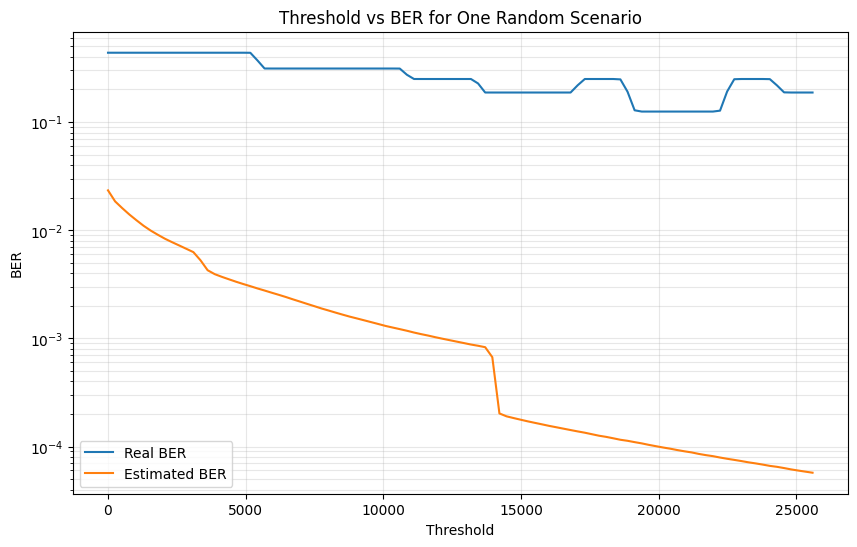

In [1]:
import os
import re
import joblib
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from scipy.special import erfc
from itertools import product as iproduct

EPS = 1e-12

# =========================
# Paths
# =========================
MODEL_PATH = "ber_multiscale_rescnn_firstflag_posemb_selfattn_best_stable_large.pth"
SCALER_PATH = "ber_multiscale_rescnn_firstflag_posemb_selfattn_scalers_large.pkl"

# =========================
# Config
# =========================
RANDOM_MAX_MEM_LEN = 14
N_THRESHOLDS = 100
RANDOM_SEED = 42

# =========================
# Utilities
# =========================
def get_sorted_seq_cols(columns, prefix):
    pattern = re.compile(rf"^{re.escape(prefix)}_(\d+)$")
    matched = []
    for col in columns:
        m = pattern.match(col)
        if m:
            matched.append((int(m.group(1)), col))
    matched.sort(key=lambda x: x[0])
    return [col for _, col in matched]

def add_fixed_width_columns(row, values, max_len, prefix):
    for i in range(max_len):
        row[f"{prefix}_{i+1}"] = float(values[i]) if i < len(values) else np.nan
    return row

# =========================
# Real BER calculator
# =========================
def calculate_ber_vectorized(mem_len, threshold, P_scaled, variances):
    P_arr = np.asarray(P_scaled, dtype=float)[:mem_len]
    vars_arr = np.asarray(variances, dtype=float)[:mem_len]

    seqs = np.array(list(iproduct([0, 1], repeat=mem_len)), dtype=np.float64)[:, ::-1]
    c_bit = seqs[:, 0]

    mu = (seqs * P_arr).sum(axis=1)
    var_total = (seqs * vars_arr).sum(axis=1)
    std = np.sqrt(np.maximum(var_total, 0.0))

    pe = np.empty_like(mu)

    zero_std = (std == 0)
    if np.any(zero_std):
        pe[zero_std & (c_bit == 1)] = np.where(
            mu[zero_std & (c_bit == 1)] < threshold, 1.0, 0.0
        )
        pe[zero_std & (c_bit == 0)] = np.where(
            mu[zero_std & (c_bit == 0)] >= threshold, 1.0, 0.0
        )

    nz = ~zero_std
    if np.any(nz):
        pe[nz & (c_bit == 1)] = 0.5 * erfc(
            (mu[nz & (c_bit == 1)] - threshold) /
            (std[nz & (c_bit == 1)] * np.sqrt(2))
        )
        pe[nz & (c_bit == 0)] = 0.5 * erfc(
            (threshold - mu[nz & (c_bit == 0)]) /
            (std[nz & (c_bit == 0)] * np.sqrt(2))
        )

    return float(np.mean(pe))

# =========================
# Random scenario generator
# =========================
def generate_random_case(rng, max_mem_len=14):
    mem_len = int(rng.integers(3, max_mem_len + 1))
    N = int(10 ** rng.uniform(3.0, 6.0))

    P = np.empty(mem_len)
    P[0] = rng.uniform(0.05, 0.95)
    for i in range(1, mem_len):
        P[i] = P[i - 1] * rng.uniform(0.35, 0.98)
    P = np.clip(P, 1e-6, 1 - 1e-6)

    P_scaled = P * N
    variances = N * P * (1.0 - P)

    case = {
        "mem_len": mem_len,
        "N": N,
        "P": P,
        "P_scaled": P_scaled,
        "variances": variances,
    }
    return case

# =========================
# Model blocks
# =========================
class SqueezeExcite1D(nn.Module):
    def __init__(self, channels, reduction=8):
        super().__init__()
        hidden = max(channels // reduction, 8)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(
            nn.Conv1d(channels, hidden, kernel_size=1),
            nn.GELU(),
            nn.Conv1d(hidden, channels, kernel_size=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        scale = self.pool(x)
        scale = self.fc(scale)
        return x * scale

class ConvBNAct(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size, dilation=1, stride=1, groups=1):
        super().__init__()
        padding = ((kernel_size - 1) // 2) * dilation
        self.block = nn.Sequential(
            nn.Conv1d(
                in_ch, out_ch,
                kernel_size=kernel_size,
                stride=stride,
                padding=padding,
                dilation=dilation,
                groups=groups,
                bias=False
            ),
            nn.BatchNorm1d(out_ch),
            nn.GELU()
        )

    def forward(self, x):
        return self.block(x)

class MultiScaleResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.1, se=True):
        super().__init__()
        b1 = out_ch // 3
        b2 = out_ch // 3
        b3 = out_ch - b1 - b2

        self.branch1 = ConvBNAct(in_ch, b1, kernel_size=3, dilation=1)
        self.branch2 = ConvBNAct(in_ch, b2, kernel_size=5, dilation=1)
        self.branch3 = ConvBNAct(in_ch, b3, kernel_size=3, dilation=2)

        self.mix = nn.Sequential(
            nn.Conv1d(out_ch, out_ch, kernel_size=1, bias=False),
            nn.BatchNorm1d(out_ch),
            nn.GELU(),
            nn.Dropout(dropout)
        )

        self.se = SqueezeExcite1D(out_ch) if se else nn.Identity()
        self.skip = (
            nn.Sequential(
                nn.Conv1d(in_ch, out_ch, kernel_size=1, bias=False),
                nn.BatchNorm1d(out_ch)
            )
            if in_ch != out_ch else nn.Identity()
        )
        self.out_act = nn.GELU()

    def forward(self, x):
        residual = self.skip(x)
        out = torch.cat(
            [self.branch1(x), self.branch2(x), self.branch3(x)],
            dim=1
        )
        out = self.mix(out)
        out = self.se(out)
        out = out + residual
        out = self.out_act(out)
        return out

class DownsampleResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.1, se=True):
        super().__init__()
        self.pre = MultiScaleResidualBlock(in_ch, out_ch, dropout=dropout, se=se)
        self.down = nn.Sequential(
            nn.Conv1d(out_ch, out_ch, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm1d(out_ch),
            nn.GELU()
        )

    def forward(self, x):
        x = self.pre(x)
        x = self.down(x)
        return x

class ThresholdFiLM(nn.Module):
    def __init__(self, threshold_dim, feature_dim, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(threshold_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, feature_dim * 2)
        )
        self.scale = nn.Parameter(torch.tensor(0.25, dtype=torch.float32))

    def forward(self, x, thr_emb):
        gamma_beta = self.net(thr_emb)
        gamma, beta = torch.chunk(gamma_beta, 2, dim=1)
        gamma = gamma.unsqueeze(-1)
        beta = beta.unsqueeze(-1)
        return x * (1.0 + self.scale * gamma) + self.scale * beta

class SequenceStem(nn.Module):
    def __init__(self, in_ch, stem_ch=32):
        super().__init__()
        self.net = nn.Sequential(
            ConvBNAct(in_ch, stem_ch, kernel_size=5),
            MultiScaleResidualBlock(stem_ch, stem_ch, dropout=0.05, se=True)
        )

    def forward(self, x):
        return self.net(x)

class LightSelfAttention1D(nn.Module):
    def __init__(self, dim, num_heads=4, mlp_ratio=2.0, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(
            embed_dim=dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )
        self.norm2 = nn.LayerNorm(dim)

        hidden = int(dim * mlp_ratio)
        self.mlp = nn.Sequential(
            nn.Linear(dim, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, dim),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        x_seq = x.transpose(1, 2)
        y = self.norm1(x_seq)
        attn_out, _ = self.attn(y, y, y, need_weights=False)
        x_seq = x_seq + attn_out
        x_seq = x_seq + self.mlp(self.norm2(x_seq))
        return x_seq.transpose(1, 2)

class MultiHeadAttentionPooling(nn.Module):
    def __init__(self, input_dim, attn_dim=128, num_heads=4):
        super().__init__()
        self.score = nn.Sequential(
            nn.Conv1d(input_dim, attn_dim, kernel_size=1),
            nn.GELU(),
            nn.Conv1d(attn_dim, num_heads, kernel_size=1)
        )
        self.num_heads = num_heads
        self.input_dim = input_dim

    def forward(self, x):
        logits = self.score(x)
        weights = torch.softmax(logits, dim=-1)
        pooled = torch.einsum("bhl,bcl->bhc", weights, x)
        pooled = pooled.reshape(x.size(0), self.num_heads * self.input_dim)
        return pooled

class StagePooling(nn.Module):
    def __init__(self, channels, num_attn_heads=2, attn_dim=64):
        super().__init__()
        self.attn_pool = MultiHeadAttentionPooling(
            input_dim=channels,
            attn_dim=attn_dim,
            num_heads=num_attn_heads
        )
        self.out_dim = num_attn_heads * channels + 3 * channels

    def forward(self, x):
        attn = self.attn_pool(x)
        mean = x.mean(dim=-1)
        std = x.std(dim=-1, unbiased=False)
        maxv = x.amax(dim=-1)
        return torch.cat([attn, mean, std, maxv], dim=1)

class BERMultiScaleResCNNv2(nn.Module):
    def __init__(
        self,
        seq_len,
        threshold_dim=1,
        stem_ch=32,
        channels=(64, 96, 128),
        dropout=0.10,
        stage_pool_heads=(2, 2, 2, 4),
        attn_heads=4,
        pos_emb_dim=8,
        use_self_attention=True,
    ):
        super().__init__()

        self.mean_stem = SequenceStem(in_ch=1, stem_ch=stem_ch)
        self.var_stem = SequenceStem(in_ch=1, stem_ch=stem_ch)

        self.extra_proj = nn.Sequential(
            nn.Conv1d(4, stem_ch, kernel_size=1, bias=False),
            nn.BatchNorm1d(stem_ch),
            nn.GELU()
        )

        self.pos_embedding = nn.Parameter(torch.randn(1, pos_emb_dim, seq_len) * 0.02)

        self.pos_emb_proj = nn.Sequential(
            nn.Conv1d(pos_emb_dim, stem_ch, kernel_size=1, bias=False),
            nn.BatchNorm1d(stem_ch),
            nn.GELU()
        )

        fusion_in = stem_ch * 4

        self.thr_embed = nn.Sequential(
            nn.Linear(threshold_dim, 32),
            nn.GELU(),
            nn.Linear(32, 32),
            nn.GELU()
        )

        self.stage1 = MultiScaleResidualBlock(fusion_in, channels[0], dropout=dropout, se=True)
        self.film1 = ThresholdFiLM(32, channels[0], hidden_dim=64)

        self.stage2 = DownsampleResidualBlock(channels[0], channels[1], dropout=dropout, se=True)
        self.film2 = ThresholdFiLM(32, channels[1], hidden_dim=64)

        self.stage3 = DownsampleResidualBlock(channels[1], channels[2], dropout=dropout, se=True)
        self.film3 = ThresholdFiLM(32, channels[2], hidden_dim=64)

        self.self_attn = LightSelfAttention1D(
            dim=channels[2],
            num_heads=attn_heads,
            mlp_ratio=2.0,
            dropout=dropout
        ) if use_self_attention else nn.Identity()

        self.bottleneck = nn.Sequential(
            MultiScaleResidualBlock(channels[2], channels[2], dropout=dropout, se=True),
            MultiScaleResidualBlock(channels[2], channels[2], dropout=dropout, se=True),
        )

        self.pool1 = StagePooling(channels[0], num_attn_heads=stage_pool_heads[0], attn_dim=64)
        self.pool2 = StagePooling(channels[1], num_attn_heads=stage_pool_heads[1], attn_dim=64)
        self.pool3 = StagePooling(channels[2], num_attn_heads=stage_pool_heads[2], attn_dim=64)
        self.poolb = StagePooling(channels[2], num_attn_heads=stage_pool_heads[3], attn_dim=128)

        head_in = (
            self.pool1.out_dim +
            self.pool2.out_dim +
            self.pool3.out_dim +
            self.poolb.out_dim +
            32
        )

        self.head = nn.Sequential(
            nn.Linear(head_in, 512),
            nn.GELU(),
            nn.Dropout(0.20),
            nn.Linear(512, 256),
            nn.GELU(),
            nn.Dropout(0.15),
            nn.Linear(256, 128),
            nn.GELU(),
            nn.Linear(128, 1)
        )

    def forward(self, seq, threshold):
        mean_x = seq[:, 0:1, :]
        var_x = seq[:, 1:2, :]
        extra_x = seq[:, 2:6, :]

        mean_f = self.mean_stem(mean_x)
        var_f = self.var_stem(var_x)
        extra_f = self.extra_proj(extra_x)

        pos_emb = self.pos_embedding.expand(seq.size(0), -1, -1)
        pos_f = self.pos_emb_proj(pos_emb)

        x = torch.cat([mean_f, var_f, extra_f, pos_f], dim=1)
        thr = self.thr_embed(threshold)

        x1 = self.stage1(x)
        x1 = self.film1(x1, thr)

        x2 = self.stage2(x1)
        x2 = self.film2(x2, thr)

        x3 = self.stage3(x2)
        x3 = self.film3(x3, thr)

        x3 = self.self_attn(x3)
        xb = self.bottleneck(x3)

        p1 = self.pool1(x1)
        p2 = self.pool2(x2)
        p3 = self.pool3(x3)
        pb = self.poolb(xb)

        fused = torch.cat([p1, p2, p3, pb, thr], dim=1)
        return self.head(fused)

# =========================
# Build model input for many thresholds
# =========================
def build_threshold_sweep_dataframe(case, thresholds, scaler_meta):
    tap_cols = scaler_meta["tap_cols"]
    var_cols = scaler_meta["var_cols"]
    max_len = len(tap_cols)

    P = case["P"]
    variances = case["variances"]

    rows = []
    for thr in thresholds:
        row = {
            "mem_len": case["mem_len"],
            "threshold": float(thr),
            "BER": np.nan,
        }
        row = add_fixed_width_columns(row, P, max_len, "tap")
        row = add_fixed_width_columns(row, variances / case["N"], max_len, "var")
        rows.append(row)

    return pd.DataFrame(rows)

def prepare_inference_features(df, scalers):
    tap_cols = scalers["tap_cols"]
    var_cols = scalers["var_cols"]

    X_taps_raw = df[tap_cols].fillna(0.0).to_numpy(dtype=np.float32)
    X_vars_raw = df[var_cols].fillna(0.0).to_numpy(dtype=np.float32)
    X_thr_raw = df["threshold"].to_numpy(dtype=np.float32).reshape(-1, 1)

    X_thr = np.log10(X_thr_raw + EPS).astype(np.float32)

    if np.all(X_vars_raw >= 0):
        X_vars_feat = np.log10(X_vars_raw + EPS).astype(np.float32)
        snr_raw = np.log10((X_taps_raw ** 2) / (X_vars_raw + 1e-12) + 1e-12).astype(np.float32)
    else:
        X_vars_feat = X_vars_raw.astype(np.float32)
        snr_raw = np.log10((X_taps_raw ** 2) / (np.abs(X_vars_raw) + 1e-12) + 1e-12).astype(np.float32)

    abs_taps_raw = np.abs(X_taps_raw).astype(np.float32)

    taps_scaled = scalers["tap_scaler"].transform(X_taps_raw).astype(np.float32)
    vars_scaled = scalers["var_scaler"].transform(X_vars_feat).astype(np.float32)
    abs_scaled = scalers["abs_scaler"].transform(abs_taps_raw).astype(np.float32)
    snr_scaled = scalers["snr_scaler"].transform(snr_raw).astype(np.float32)
    thr_scaled = scalers["thr_scaler"].transform(X_thr).astype(np.float32)

    L = taps_scaled.shape[1]
    pos = np.linspace(0.0, 1.0, L, dtype=np.float32)
    pos_ch = np.tile(pos, (len(df), 1)).astype(np.float32)

    first_flag = np.zeros((len(df), L), dtype=np.float32)
    first_flag[:, 0] = 1.0

    seq = np.stack(
        [taps_scaled, vars_scaled, pos_ch, abs_scaled, snr_scaled, first_flag],
        axis=1
    ).astype(np.float32)

    return seq, thr_scaled

# =========================
# Generate one random scenario
# =========================
rng = np.random.default_rng(RANDOM_SEED)
case = generate_random_case(rng, max_mem_len=RANDOM_MAX_MEM_LEN)

print("Generated random scenario")
print("mem_len =", case["mem_len"])
print("N       =", case["N"])
print("P       =", case["P"])
print("P_scaled=", case["P_scaled"])
print("vars    =", case["variances"])

# =========================
# Threshold sweep
# =========================
thr_min = 1.0
thr_max = max(2.0, 1.5 * case["P_scaled"][0])
thresholds = np.linspace(thr_min, thr_max, N_THRESHOLDS)

real_bers = np.array([
    calculate_ber_vectorized(
        mem_len=case["mem_len"],
        threshold=thr,
        P_scaled=case["P_scaled"],
        variances=case["variances"]
    )
    for thr in thresholds
])

# =========================
# Load scalers and model
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
scalers = joblib.load(SCALER_PATH)

seq_len = scalers["seq_len"]
model = BERMultiScaleResCNNv2(
    seq_len=seq_len,
    threshold_dim=1,
    stem_ch=32,
    channels=(64, 96, 128),
    dropout=0.10,
    stage_pool_heads=(2, 2, 2, 4),
    attn_heads=4,
    pos_emb_dim=8,
    use_self_attention=scalers.get("uses_self_attention", True),
).to(device)

state = torch.load(MODEL_PATH, map_location=device)
model.load_state_dict(state)
model.eval()

# =========================
# Build model inputs for all thresholds
# =========================
sweep_df = build_threshold_sweep_dataframe(case, thresholds, scalers)
seq, thr_scaled = prepare_inference_features(sweep_df, scalers)

seq_t = torch.from_numpy(seq).to(device)
thr_t = torch.from_numpy(thr_scaled).to(device)

with torch.no_grad():
    pred_log = model(seq_t, thr_t).cpu().numpy().reshape(-1)

pred_bers = np.clip(10 ** np.clip(pred_log, -12.0, 0.0), EPS, 1.0)

# =========================
# Comparison table
# =========================
results = pd.DataFrame({
    "threshold": thresholds,
    "real_BER": real_bers,
    "estimated_BER": pred_bers,
    "abs_error": np.abs(pred_bers - real_bers),
    "abs_log10_error": np.abs(
        np.log10(np.clip(pred_bers, EPS, None)) -
        np.log10(np.clip(real_bers, EPS, None))
    ),
})

display(results.head(10))

print("\nSummary")
print("Mean abs raw error   :", results["abs_error"].mean())
print("Mean abs log10 error :", results["abs_log10_error"].mean())
print("Max  abs log10 error :", results["abs_log10_error"].max())

# =========================
# Plot
# =========================
plt.figure(figsize=(10, 6))
plt.plot(results["threshold"], results["real_BER"], label="Real BER")
plt.plot(results["threshold"], results["estimated_BER"], label="Estimated BER")
plt.yscale("log")
plt.xlabel("Threshold")
plt.ylabel("BER")
plt.title("Threshold vs BER for One Random Scenario")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.show()

Generated physical scenario
radius    = 3.6485676254025527
distance  = 10.135731959475024
diffusion = 51.36802218605558
Ts        = 1.1933440649110825
N         = 388928
mem_len   = 6
P         = [0.0952836  0.04167955 0.02109599 0.01323983 0.00928885 0.00697681]
P_scaled  = [37058.46028454 16210.34416095  8204.82193215  5149.33902953
  3612.69537635  2713.47697434]
variances = [33527.39674923 15534.7043052   8031.73307524  5081.16267699
  3579.13757675  2694.54555955]
Threshold search interval: 0.0 to 72949.1377578628
sum(P_scaled) = 72949.1377578628


,threshold,real_BER,estimated_BER,abs_error,abs_log10_error
0,0.000000,0.500000,1.000000,0.500000,0.301030
1,146.190657,0.484375,0.438013,0.046362,0.043694
2,292.381314,0.484375,0.438447,0.045928,0.043265
3,438.571970,0.484375,0.438181,0.046194,0.043528
4,584.762627,0.484375,0.439298,0.045077,0.042422
5,730.953284,0.484375,0.440630,0.043745,0.041107
6,877.143941,0.484375,0.441456,0.042919,0.040294
7,1023.334598,0.484375,0.441633,0.042742,0.040120
8,1169.525255,0.484375,0.441337,0.043038,0.040411
9,1315.715911,0.484375,0.440721,0.043654,0.041018



Summary
Mean abs raw error   : 0.0350104237217041
Mean abs log10 error : 0.06738207328233167
Max  abs log10 error : 1.0268527067448163

Best threshold from real BER      : 36547.6642073461
Minimum real BER                  : 4.4650961715574345e-05
Best threshold from estimated BER : 36547.6642073461
Estimated BER at that threshold   : 0.00036341543


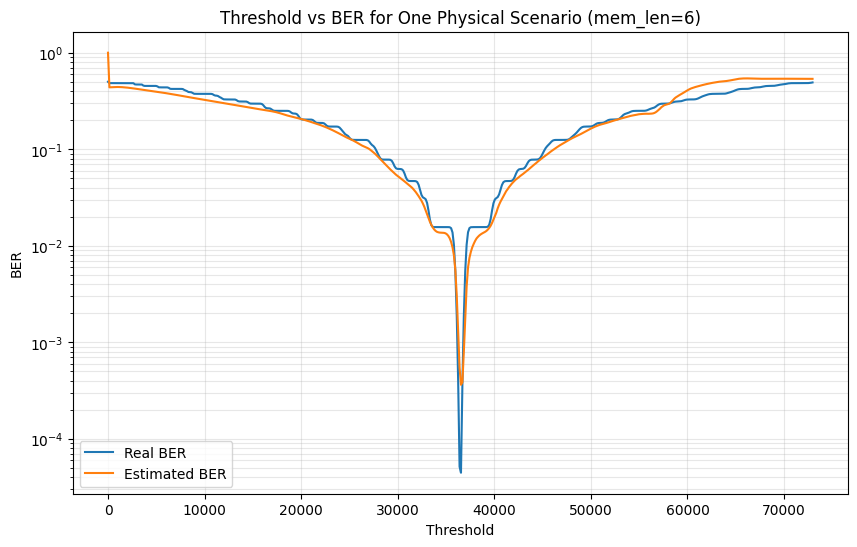

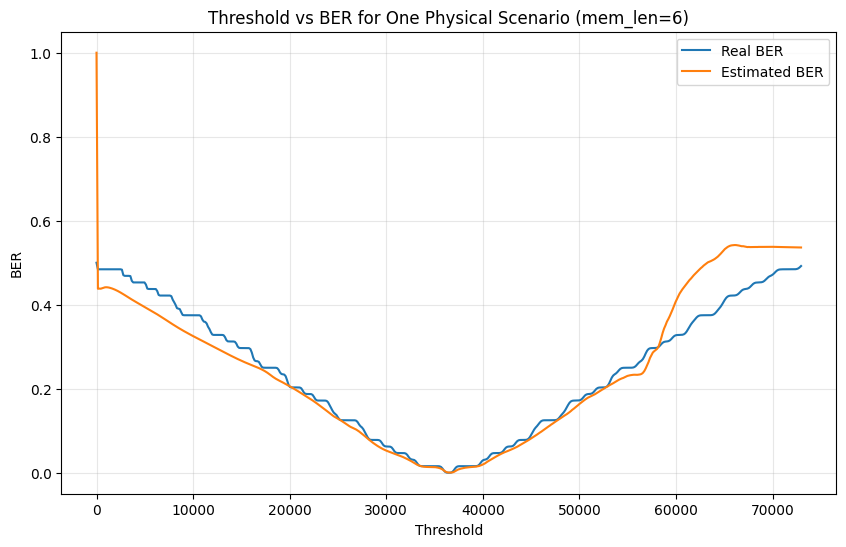

In [12]:
import os
import re
import joblib
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from scipy.special import erfc
from itertools import product as iproduct

EPS = 1e-12

# =========================
# Paths
# =========================
MODEL_PATH = "ber_multiscale_rescnn_firstflag_posemb_selfattn_best_stable_large.pth"
SCALER_PATH = "ber_multiscale_rescnn_firstflag_posemb_selfattn_scalers_large.pkl"

# =========================
# Config
# =========================
PHYSICS_MAX_MEM_LEN = 14
PHYSICS_MIN_MEM_LEN = 3   # increase this if you want larger memory, e.g. 11, 12
ARRIVAL_COVERAGE = 0.70
N_THRESHOLDS = 500
RANDOM_SEED = 60

# =========================
# Physics helpers
# =========================
def Fhit_function(radius, distance, diffusionCoef, t):
    if t <= 0:
        return 0.0
    return (radius / (distance + radius)) * erfc(distance / np.sqrt(4 * diffusionCoef * t))

def calculate_hitting_probabilities(mem_len, radius, distance, diffusionCoef, Ts):
    P = np.zeros(mem_len)
    for i in range(mem_len):
        t_end = (i + 1) * Ts
        t_start = i * Ts
        P[i] = Fhit_function(radius, distance, diffusionCoef, t_end) - Fhit_function(
            radius, distance, diffusionCoef, t_start
        )
    return P

def calculate_ber_vectorized(mem_len, threshold, P_scaled, variances):
    P_arr = np.asarray(P_scaled, dtype=float)[:mem_len]
    vars_arr = np.asarray(variances, dtype=float)[:mem_len]

    seqs = np.array(list(iproduct([0, 1], repeat=mem_len)), dtype=np.float64)[:, ::-1]
    c_bit = seqs[:, 0]

    mu = (seqs * P_arr).sum(axis=1)
    var_total = (seqs * vars_arr).sum(axis=1)
    std = np.sqrt(np.maximum(var_total, 0.0))

    pe = np.empty_like(mu)

    zero_std = (std == 0)
    if np.any(zero_std):
        pe[zero_std & (c_bit == 1)] = np.where(
            mu[zero_std & (c_bit == 1)] < threshold, 1.0, 0.0
        )
        pe[zero_std & (c_bit == 0)] = np.where(
            mu[zero_std & (c_bit == 0)] >= threshold, 1.0, 0.0
        )

    nz = ~zero_std
    if np.any(nz):
        pe[nz & (c_bit == 1)] = 0.5 * erfc(
            (mu[nz & (c_bit == 1)] - threshold) /
            (std[nz & (c_bit == 1)] * np.sqrt(2))
        )
        pe[nz & (c_bit == 0)] = 0.5 * erfc(
            (threshold - mu[nz & (c_bit == 0)]) /
            (std[nz & (c_bit == 0)] * np.sqrt(2))
        )

    return float(np.mean(pe))

def add_fixed_width_columns(row, values, max_len, prefix):
    for i in range(max_len):
        row[f"{prefix}_{i+1}"] = float(values[i]) if i < len(values) else np.nan
    return row

# =========================
# One physical scenario
# =========================
def generate_physical_case(
    rng,
    min_mem_len=10,
    max_mem_len=14,
    arrival_coverage=0.70,
    max_tries=5000
):
    """
    Generate one physical scenario with mem_len >= min_mem_len.
    The parameter ranges are slightly biased toward larger memory length.
    """
    for _ in range(max_tries):
        radius = rng.uniform(3.0, 5.0)
        distance = rng.uniform(10.0, 15.0)
        diff = rng.uniform(50.0, 75.0)
        Ts = rng.uniform(0.5, 1.2)
        N = int(10 ** rng.uniform(3.0, 6.0))

        f_inf = radius / (radius + distance)
        target = arrival_coverage * f_inf

        cumsum, k = 0.0, 0
        while k < max_mem_len:
            pk = Fhit_function(radius, distance, diff, (k + 1) * Ts) - Fhit_function(
                radius, distance, diff, k * Ts
            )
            cumsum += pk
            k += 1
            if cumsum >= target:
                break

        if k < min_mem_len:
            continue

        P_ext = calculate_hitting_probabilities(k + 1, radius, distance, diff, Ts)
        P_main = P_ext[:k]
        P_extra = float(P_ext[k]) if k < len(P_ext) else 0.0

        P_scaled = P_main * N
        variances = N * P_main * (1.0 - P_main)

        case = {
            "radius": radius,
            "distance": distance,
            "diffusion": diff,
            "Ts": Ts,
            "N": N,
            "mem_len": k,
            "P": P_main,
            "P_scaled": P_scaled,
            "variances": variances,
            "P_mem_len_extra": P_extra,
            "P_mem_len_extra_var": P_extra * (1.0 - P_extra),
        }
        return case

    raise RuntimeError(
        f"Could not generate a physical case with mem_len >= {min_mem_len} "
        f"after {max_tries} tries. Lower PHYSICS_MIN_MEM_LEN or raise max_tries."
    )

# =========================
# Model blocks
# =========================
class SqueezeExcite1D(nn.Module):
    def __init__(self, channels, reduction=8):
        super().__init__()
        hidden = max(channels // reduction, 8)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(
            nn.Conv1d(channels, hidden, kernel_size=1),
            nn.GELU(),
            nn.Conv1d(hidden, channels, kernel_size=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        scale = self.pool(x)
        scale = self.fc(scale)
        return x * scale

class ConvBNAct(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size, dilation=1, stride=1, groups=1):
        super().__init__()
        padding = ((kernel_size - 1) // 2) * dilation
        self.block = nn.Sequential(
            nn.Conv1d(
                in_ch, out_ch,
                kernel_size=kernel_size,
                stride=stride,
                padding=padding,
                dilation=dilation,
                groups=groups,
                bias=False
            ),
            nn.BatchNorm1d(out_ch),
            nn.GELU()
        )

    def forward(self, x):
        return self.block(x)

class MultiScaleResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.1, se=True):
        super().__init__()
        b1 = out_ch // 3
        b2 = out_ch // 3
        b3 = out_ch - b1 - b2

        self.branch1 = ConvBNAct(in_ch, b1, kernel_size=3, dilation=1)
        self.branch2 = ConvBNAct(in_ch, b2, kernel_size=5, dilation=1)
        self.branch3 = ConvBNAct(in_ch, b3, kernel_size=3, dilation=2)

        self.mix = nn.Sequential(
            nn.Conv1d(out_ch, out_ch, kernel_size=1, bias=False),
            nn.BatchNorm1d(out_ch),
            nn.GELU(),
            nn.Dropout(dropout)
        )

        self.se = SqueezeExcite1D(out_ch) if se else nn.Identity()
        self.skip = (
            nn.Sequential(
                nn.Conv1d(in_ch, out_ch, kernel_size=1, bias=False),
                nn.BatchNorm1d(out_ch)
            )
            if in_ch != out_ch else nn.Identity()
        )
        self.out_act = nn.GELU()

    def forward(self, x):
        residual = self.skip(x)
        out = torch.cat(
            [self.branch1(x), self.branch2(x), self.branch3(x)],
            dim=1
        )
        out = self.mix(out)
        out = self.se(out)
        out = out + residual
        out = self.out_act(out)
        return out

class DownsampleResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.1, se=True):
        super().__init__()
        self.pre = MultiScaleResidualBlock(in_ch, out_ch, dropout=dropout, se=se)
        self.down = nn.Sequential(
            nn.Conv1d(out_ch, out_ch, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm1d(out_ch),
            nn.GELU()
        )

    def forward(self, x):
        x = self.pre(x)
        x = self.down(x)
        return x

class ThresholdFiLM(nn.Module):
    def __init__(self, threshold_dim, feature_dim, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(threshold_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, feature_dim * 2)
        )
        self.scale = nn.Parameter(torch.tensor(0.25, dtype=torch.float32))

    def forward(self, x, thr_emb):
        gamma_beta = self.net(thr_emb)
        gamma, beta = torch.chunk(gamma_beta, 2, dim=1)
        gamma = gamma.unsqueeze(-1)
        beta = beta.unsqueeze(-1)
        return x * (1.0 + self.scale * gamma) + self.scale * beta

class SequenceStem(nn.Module):
    def __init__(self, in_ch, stem_ch=32):
        super().__init__()
        self.net = nn.Sequential(
            ConvBNAct(in_ch, stem_ch, kernel_size=5),
            MultiScaleResidualBlock(stem_ch, stem_ch, dropout=0.05, se=True)
        )

    def forward(self, x):
        return self.net(x)

class LightSelfAttention1D(nn.Module):
    def __init__(self, dim, num_heads=4, mlp_ratio=2.0, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(
            embed_dim=dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )
        self.norm2 = nn.LayerNorm(dim)

        hidden = int(dim * mlp_ratio)
        self.mlp = nn.Sequential(
            nn.Linear(dim, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, dim),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        x_seq = x.transpose(1, 2)
        y = self.norm1(x_seq)
        attn_out, _ = self.attn(y, y, y, need_weights=False)
        x_seq = x_seq + attn_out
        x_seq = x_seq + self.mlp(self.norm2(x_seq))
        return x_seq.transpose(1, 2)

class MultiHeadAttentionPooling(nn.Module):
    def __init__(self, input_dim, attn_dim=128, num_heads=4):
        super().__init__()
        self.score = nn.Sequential(
            nn.Conv1d(input_dim, attn_dim, kernel_size=1),
            nn.GELU(),
            nn.Conv1d(attn_dim, num_heads, kernel_size=1)
        )
        self.num_heads = num_heads
        self.input_dim = input_dim

    def forward(self, x):
        logits = self.score(x)
        weights = torch.softmax(logits, dim=-1)
        pooled = torch.einsum("bhl,bcl->bhc", weights, x)
        pooled = pooled.reshape(x.size(0), self.num_heads * self.input_dim)
        return pooled

class StagePooling(nn.Module):
    def __init__(self, channels, num_attn_heads=2, attn_dim=64):
        super().__init__()
        self.attn_pool = MultiHeadAttentionPooling(
            input_dim=channels,
            attn_dim=attn_dim,
            num_heads=num_attn_heads
        )
        self.out_dim = num_attn_heads * channels + 3 * channels

    def forward(self, x):
        attn = self.attn_pool(x)
        mean = x.mean(dim=-1)
        std = x.std(dim=-1, unbiased=False)
        maxv = x.amax(dim=-1)
        return torch.cat([attn, mean, std, maxv], dim=1)

class BERMultiScaleResCNNv2(nn.Module):
    def __init__(
        self,
        seq_len,
        threshold_dim=1,
        stem_ch=32,
        channels=(64, 96, 128),
        dropout=0.10,
        stage_pool_heads=(2, 2, 2, 4),
        attn_heads=4,
        pos_emb_dim=8,
        use_self_attention=True,
    ):
        super().__init__()

        self.mean_stem = SequenceStem(in_ch=1, stem_ch=stem_ch)
        self.var_stem = SequenceStem(in_ch=1, stem_ch=stem_ch)

        self.extra_proj = nn.Sequential(
            nn.Conv1d(4, stem_ch, kernel_size=1, bias=False),
            nn.BatchNorm1d(stem_ch),
            nn.GELU()
        )

        self.pos_embedding = nn.Parameter(torch.randn(1, pos_emb_dim, seq_len) * 0.02)

        self.pos_emb_proj = nn.Sequential(
            nn.Conv1d(pos_emb_dim, stem_ch, kernel_size=1, bias=False),
            nn.BatchNorm1d(stem_ch),
            nn.GELU()
        )

        fusion_in = stem_ch * 4

        self.thr_embed = nn.Sequential(
            nn.Linear(threshold_dim, 32),
            nn.GELU(),
            nn.Linear(32, 32),
            nn.GELU()
        )

        self.stage1 = MultiScaleResidualBlock(fusion_in, channels[0], dropout=dropout, se=True)
        self.film1 = ThresholdFiLM(32, channels[0], hidden_dim=64)

        self.stage2 = DownsampleResidualBlock(channels[0], channels[1], dropout=dropout, se=True)
        self.film2 = ThresholdFiLM(32, channels[1], hidden_dim=64)

        self.stage3 = DownsampleResidualBlock(channels[1], channels[2], dropout=dropout, se=True)
        self.film3 = ThresholdFiLM(32, channels[2], hidden_dim=64)

        self.self_attn = LightSelfAttention1D(
            dim=channels[2],
            num_heads=attn_heads,
            mlp_ratio=2.0,
            dropout=dropout
        ) if use_self_attention else nn.Identity()

        self.bottleneck = nn.Sequential(
            MultiScaleResidualBlock(channels[2], channels[2], dropout=dropout, se=True),
            MultiScaleResidualBlock(channels[2], channels[2], dropout=dropout, se=True),
        )

        self.pool1 = StagePooling(channels[0], num_attn_heads=stage_pool_heads[0], attn_dim=64)
        self.pool2 = StagePooling(channels[1], num_attn_heads=stage_pool_heads[1], attn_dim=64)
        self.pool3 = StagePooling(channels[2], num_attn_heads=stage_pool_heads[2], attn_dim=64)
        self.poolb = StagePooling(channels[2], num_attn_heads=stage_pool_heads[3], attn_dim=128)

        head_in = (
            self.pool1.out_dim +
            self.pool2.out_dim +
            self.pool3.out_dim +
            self.poolb.out_dim +
            32
        )

        self.head = nn.Sequential(
            nn.Linear(head_in, 512),
            nn.GELU(),
            nn.Dropout(0.20),
            nn.Linear(512, 256),
            nn.GELU(),
            nn.Dropout(0.15),
            nn.Linear(256, 128),
            nn.GELU(),
            nn.Linear(128, 1)
        )

    def forward(self, seq, threshold):
        mean_x = seq[:, 0:1, :]
        var_x = seq[:, 1:2, :]
        extra_x = seq[:, 2:6, :]

        mean_f = self.mean_stem(mean_x)
        var_f = self.var_stem(var_x)
        extra_f = self.extra_proj(extra_x)

        pos_emb = self.pos_embedding.expand(seq.size(0), -1, -1)
        pos_f = self.pos_emb_proj(pos_emb)

        x = torch.cat([mean_f, var_f, extra_f, pos_f], dim=1)
        thr = self.thr_embed(threshold)

        x1 = self.stage1(x)
        x1 = self.film1(x1, thr)

        x2 = self.stage2(x1)
        x2 = self.film2(x2, thr)

        x3 = self.stage3(x2)
        x3 = self.film3(x3, thr)

        x3 = self.self_attn(x3)
        xb = self.bottleneck(x3)

        p1 = self.pool1(x1)
        p2 = self.pool2(x2)
        p3 = self.pool3(x3)
        pb = self.poolb(xb)

        fused = torch.cat([p1, p2, p3, pb, thr], dim=1)
        return self.head(fused)

# =========================
# Build model inputs
# =========================
def build_threshold_sweep_dataframe(case, thresholds, scaler_meta):
    tap_cols = scaler_meta["tap_cols"]
    max_len = len(tap_cols)

    rows = []
    for thr in thresholds:
        row = {
            "mem_len": case["mem_len"],
            "threshold": float(thr),
            "BER": np.nan,
            "radius": case["radius"],
            "distance": case["distance"],
            "diffusion": case["diffusion"],
            "Ts": case["Ts"],
            "N": case["N"],
            "P_mem_len_extra": case["P_mem_len_extra"],
            "P_mem_len_extra_var": case["P_mem_len_extra_var"],
        }
        # Correct match to training CSV convention
        row = add_fixed_width_columns(row, case["P"], max_len, "tap")
        row = add_fixed_width_columns(row, case["variances"], max_len, "var")
        rows.append(row)

    return pd.DataFrame(rows)

def prepare_inference_features(df, scalers):
    tap_cols = scalers["tap_cols"]
    var_cols = scalers["var_cols"]

    X_taps_raw = df[tap_cols].fillna(0.0).to_numpy(dtype=np.float32)
    X_vars_raw = df[var_cols].fillna(0.0).to_numpy(dtype=np.float32)
    X_thr_raw = df["threshold"].to_numpy(dtype=np.float32).reshape(-1, 1)

    X_thr = np.log10(X_thr_raw + EPS).astype(np.float32)

    if np.all(X_vars_raw >= 0):
        X_vars_feat = np.log10(X_vars_raw + EPS).astype(np.float32)
        snr_raw = np.log10((X_taps_raw ** 2) / (X_vars_raw + 1e-12) + 1e-12).astype(np.float32)
    else:
        X_vars_feat = X_vars_raw.astype(np.float32)
        snr_raw = np.log10((X_taps_raw ** 2) / (np.abs(X_vars_raw) + 1e-12) + 1e-12).astype(np.float32)

    abs_taps_raw = np.abs(X_taps_raw).astype(np.float32)

    taps_scaled = scalers["tap_scaler"].transform(X_taps_raw).astype(np.float32)
    vars_scaled = scalers["var_scaler"].transform(X_vars_feat).astype(np.float32)
    abs_scaled = scalers["abs_scaler"].transform(abs_taps_raw).astype(np.float32)
    snr_scaled = scalers["snr_scaler"].transform(snr_raw).astype(np.float32)
    thr_scaled = scalers["thr_scaler"].transform(X_thr).astype(np.float32)

    L = taps_scaled.shape[1]
    pos = np.linspace(0.0, 1.0, L, dtype=np.float32)
    pos_ch = np.tile(pos, (len(df), 1)).astype(np.float32)

    first_flag = np.zeros((len(df), L), dtype=np.float32)
    first_flag[:, 0] = 1.0

    seq = np.stack(
        [taps_scaled, vars_scaled, pos_ch, abs_scaled, snr_scaled, first_flag],
        axis=1
    ).astype(np.float32)

    return seq, thr_scaled

# =========================
# Generate one physical scenario
# =========================
rng = np.random.default_rng(RANDOM_SEED)
case = generate_physical_case(
    rng,
    min_mem_len=PHYSICS_MIN_MEM_LEN,
    max_mem_len=PHYSICS_MAX_MEM_LEN,
    arrival_coverage=ARRIVAL_COVERAGE
)

print("Generated physical scenario")
print("radius    =", case["radius"])
print("distance  =", case["distance"])
print("diffusion =", case["diffusion"])
print("Ts        =", case["Ts"])
print("N         =", case["N"])
print("mem_len   =", case["mem_len"])
print("P         =", case["P"])
print("P_scaled  =", case["P_scaled"])
print("variances =", case["variances"])

# =========================
# Threshold sweep
# =========================
thr_min = 0.0
thr_max = float(np.sum(case["P_scaled"]))
thresholds = np.linspace(thr_min, thr_max, N_THRESHOLDS)

print("Threshold search interval:", thr_min, "to", thr_max)
print("sum(P_scaled) =", np.sum(case["P_scaled"]))
real_bers = np.array([
    calculate_ber_vectorized(
        mem_len=case["mem_len"],
        threshold=thr,
        P_scaled=case["P_scaled"],
        variances=case["variances"]
    )
    for thr in thresholds
])

# =========================
# Load model + scalers
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
scalers = joblib.load(SCALER_PATH)

seq_len = scalers["seq_len"]
model = BERMultiScaleResCNNv2(
    seq_len=seq_len,
    threshold_dim=1,
    stem_ch=32,
    channels=(64, 96, 128),
    dropout=0.10,
    stage_pool_heads=(2, 2, 2, 4),
    attn_heads=4,
    pos_emb_dim=8,
    use_self_attention=scalers.get("uses_self_attention", True),
).to(device)

state = torch.load(MODEL_PATH, map_location=device)
model.load_state_dict(state)
model.eval()

# =========================
# Predict across thresholds
# =========================
sweep_df = build_threshold_sweep_dataframe(case, thresholds, scalers)
seq, thr_scaled = prepare_inference_features(sweep_df, scalers)

seq_t = torch.from_numpy(seq).to(device)
thr_t = torch.from_numpy(thr_scaled).to(device)

with torch.no_grad():
    pred_log = model(seq_t, thr_t).cpu().numpy().reshape(-1)

pred_bers = np.clip(10 ** np.clip(pred_log, -12.0, 0.0), EPS, 1.0)

# =========================
# Comparison table
# =========================
results = pd.DataFrame({
    "threshold": thresholds,
    "real_BER": real_bers,
    "estimated_BER": pred_bers,
    "abs_error": np.abs(pred_bers - real_bers),
    "abs_log10_error": np.abs(
        np.log10(np.clip(pred_bers, EPS, None)) -
        np.log10(np.clip(real_bers, EPS, None))
    ),
})

display(results.head(15))

print("\nSummary")
print("Mean abs raw error   :", results["abs_error"].mean())
print("Mean abs log10 error :", results["abs_log10_error"].mean())
print("Max  abs log10 error :", results["abs_log10_error"].max())

best_real_idx = np.argmin(real_bers)
best_est_idx = np.argmin(pred_bers)

print("\nBest threshold from real BER      :", thresholds[best_real_idx])
print("Minimum real BER                  :", real_bers[best_real_idx])
print("Best threshold from estimated BER :", thresholds[best_est_idx])
print("Estimated BER at that threshold   :", pred_bers[best_est_idx])

# =========================
# Plot
# =========================
plt.figure(figsize=(10, 6))
plt.plot(results["threshold"], results["real_BER"], label="Real BER")
plt.plot(results["threshold"], results["estimated_BER"], label="Estimated BER")
plt.yscale("log")
plt.xlabel("Threshold")
plt.ylabel("BER")
plt.title(f"Threshold vs BER for One Physical Scenario (mem_len={case['mem_len']})")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.show()


plt.figure(figsize=(10, 6))
plt.plot(results["threshold"], results["real_BER"], label="Real BER")
plt.plot(results["threshold"], results["estimated_BER"], label="Estimated BER")
plt.yscale("linear")
plt.xlabel("Threshold")
plt.ylabel("BER")
plt.title(f"Threshold vs BER for One Physical Scenario (mem_len={case['mem_len']})")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.show()

In [11]:
print("pred_log min/max:", pred_log.min(), pred_log.max())
print("pred_BER min/max:", pred_bers.min(), pred_bers.max())

thr_log = np.log10(thresholds + EPS).reshape(-1, 1)
thr_scaled_dbg = scalers["thr_scaler"].transform(thr_log)
print("scaled threshold min/max:", thr_scaled_dbg.min(), thr_scaled_dbg.max())

pred_log min/max: -10.246951 55.696228
pred_BER min/max: 5.6630305e-11 1.0
scaled threshold min/max: -15.799774138262656 1.5975551752174446


Using device: cuda

--- Running Scenarios for Seed 42 ---


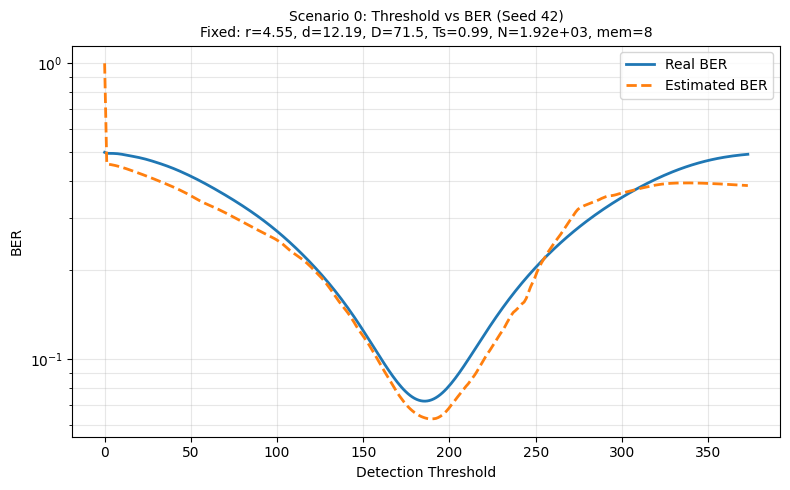

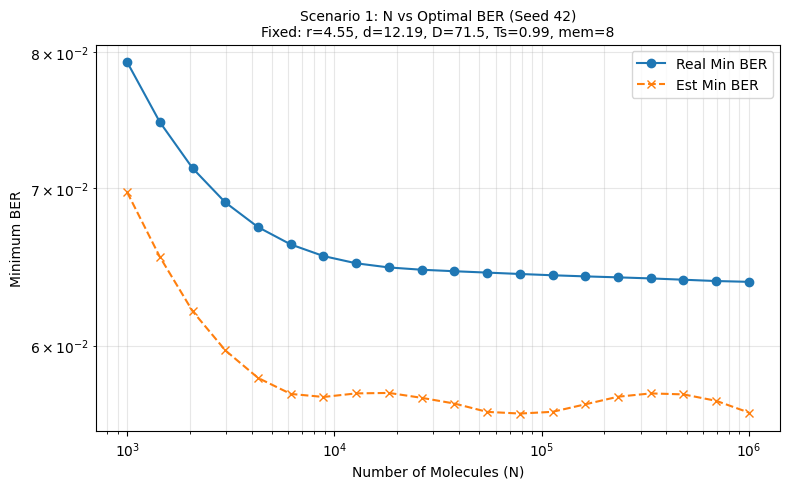

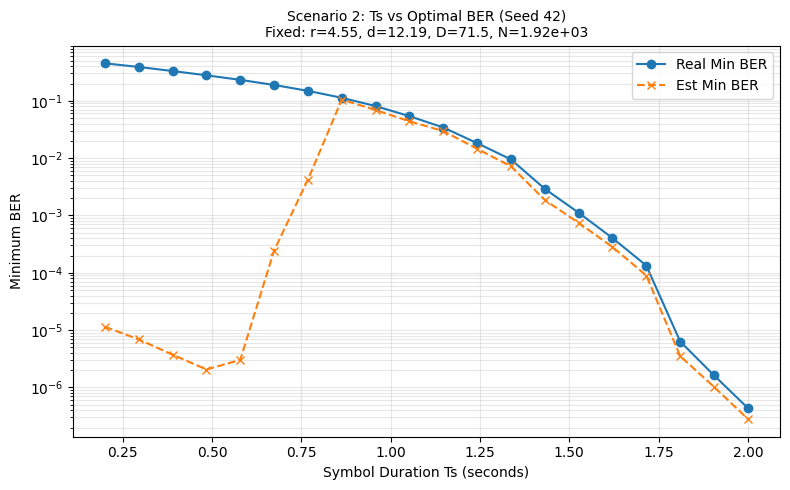

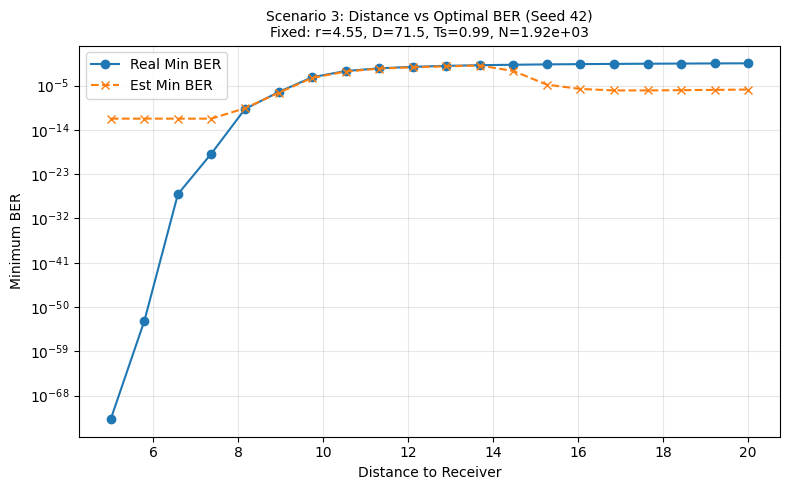


--- Running Scenarios for Seed 100 ---


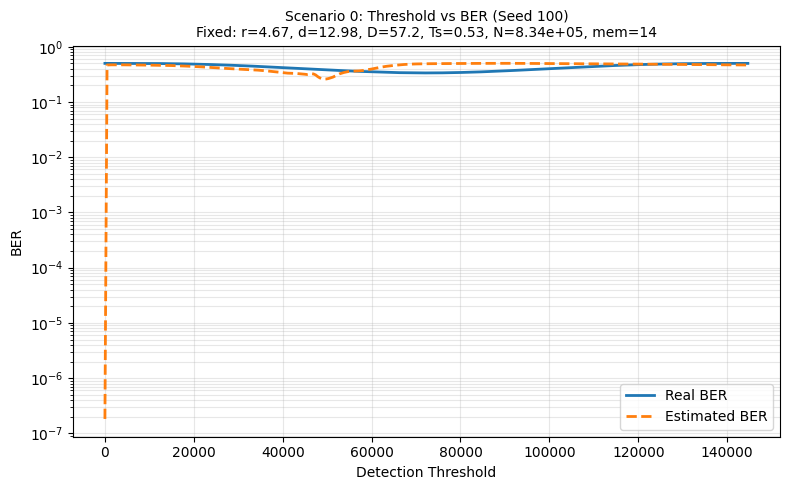

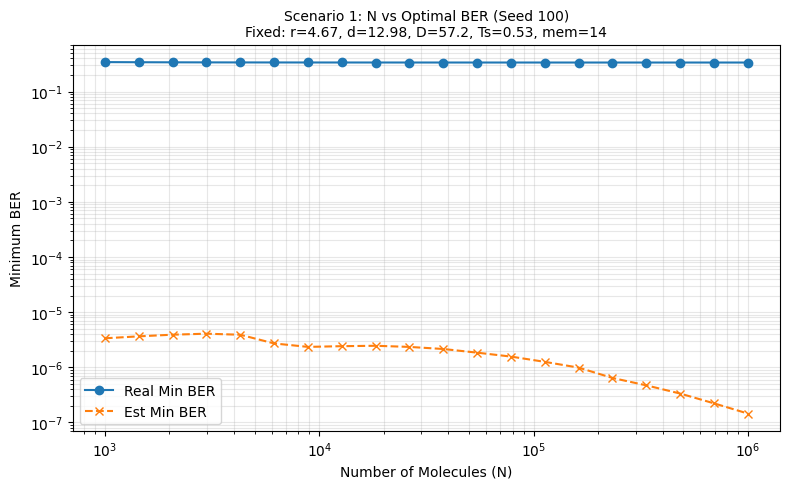

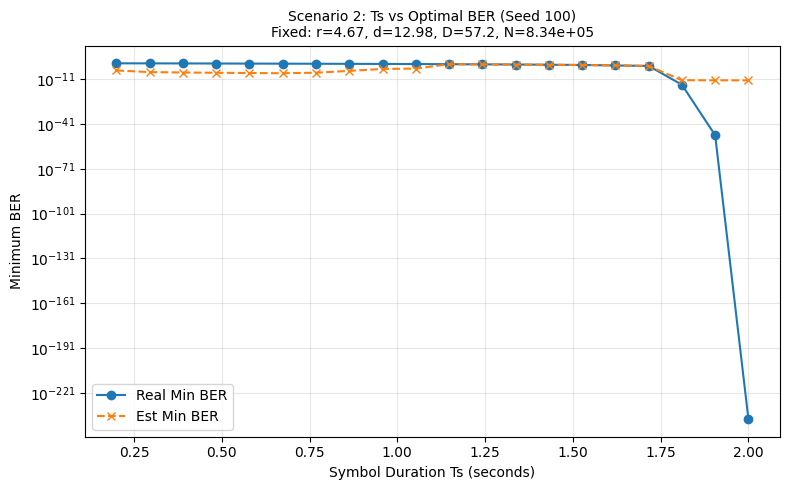

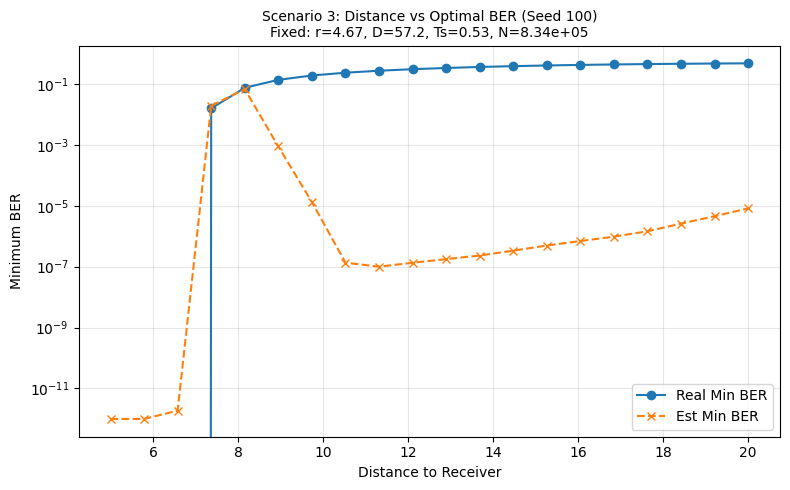

In [3]:
import os
import re
import joblib
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from scipy.special import erfc
from itertools import product as iproduct

EPS = 1e-12

# =========================
# Paths
# =========================
MODEL_PATH = "ber_multiscale_rescnn_firstflag_posemb_selfattn_best_stable_large.pth"
SCALER_PATH = "ber_multiscale_rescnn_firstflag_posemb_selfattn_scalers_large.pkl"

# =========================
# Config
# =========================
PHYSICS_MAX_MEM_LEN = 14
PHYSICS_MIN_MEM_LEN = 3   # increase this if you want larger memory, e.g. 11, 12
ARRIVAL_COVERAGE = 0.70
N_THRESHOLDS = 500
RANDOM_SEED = 60

# =========================
# Physics helpers
# =========================
def Fhit_function(radius, distance, diffusionCoef, t):
    if t <= 0:
        return 0.0
    return (radius / (distance + radius)) * erfc(distance / np.sqrt(4 * diffusionCoef * t))

def calculate_hitting_probabilities(mem_len, radius, distance, diffusionCoef, Ts):
    P = np.zeros(mem_len)
    for i in range(mem_len):
        t_end = (i + 1) * Ts
        t_start = i * Ts
        P[i] = Fhit_function(radius, distance, diffusionCoef, t_end) - Fhit_function(
            radius, distance, diffusionCoef, t_start
        )
    return P

def calculate_ber_vectorized(mem_len, threshold, P_scaled, variances):
    P_arr = np.asarray(P_scaled, dtype=float)[:mem_len]
    vars_arr = np.asarray(variances, dtype=float)[:mem_len]

    seqs = np.array(list(iproduct([0, 1], repeat=mem_len)), dtype=np.float64)[:, ::-1]
    c_bit = seqs[:, 0]

    mu = (seqs * P_arr).sum(axis=1)
    var_total = (seqs * vars_arr).sum(axis=1)
    std = np.sqrt(np.maximum(var_total, 0.0))

    pe = np.empty_like(mu)

    zero_std = (std == 0)
    if np.any(zero_std):
        pe[zero_std & (c_bit == 1)] = np.where(
            mu[zero_std & (c_bit == 1)] < threshold, 1.0, 0.0
        )
        pe[zero_std & (c_bit == 0)] = np.where(
            mu[zero_std & (c_bit == 0)] >= threshold, 1.0, 0.0
        )

    nz = ~zero_std
    if np.any(nz):
        pe[nz & (c_bit == 1)] = 0.5 * erfc(
            (mu[nz & (c_bit == 1)] - threshold) /
            (std[nz & (c_bit == 1)] * np.sqrt(2))
        )
        pe[nz & (c_bit == 0)] = 0.5 * erfc(
            (threshold - mu[nz & (c_bit == 0)]) /
            (std[nz & (c_bit == 0)] * np.sqrt(2))
        )

    return float(np.mean(pe))

def add_fixed_width_columns(row, values, max_len, prefix):
    for i in range(max_len):
        row[f"{prefix}_{i+1}"] = float(values[i]) if i < len(values) else np.nan
    return row

# =========================
# Case Generators
# =========================
def generate_physical_case(rng, min_mem_len=10, max_mem_len=14, arrival_coverage=0.70, max_tries=5000):
    for _ in range(max_tries):
        radius = rng.uniform(3.0, 5.0)
        distance = rng.uniform(10.0, 15.0)
        diff = rng.uniform(50.0, 75.0)
        Ts = rng.uniform(0.5, 1.2)
        N = int(10 ** rng.uniform(3.0, 6.0))

        f_inf = radius / (radius + distance)
        target = arrival_coverage * f_inf

        cumsum, k = 0.0, 0
        while k < max_mem_len:
            pk = Fhit_function(radius, distance, diff, (k + 1) * Ts) - Fhit_function(
                radius, distance, diff, k * Ts
            )
            cumsum += pk
            k += 1
            if cumsum >= target:
                break

        if k < min_mem_len:
            continue

        P_ext = calculate_hitting_probabilities(k + 1, radius, distance, diff, Ts)
        P_main = P_ext[:k]
        P_extra = float(P_ext[k]) if k < len(P_ext) else 0.0

        P_scaled = P_main * N
        variances = N * P_main * (1.0 - P_main)

        case = {
            "radius": radius,
            "distance": distance,
            "diffusion": diff,
            "Ts": Ts,
            "N": N,
            "mem_len": k,
            "P": P_main,
            "P_scaled": P_scaled,
            "variances": variances,
            "P_mem_len_extra": P_extra,
            "P_mem_len_extra_var": P_extra * (1.0 - P_extra),
        }
        return case

    raise RuntimeError(
        f"Could not generate a physical case with mem_len >= {min_mem_len} "
        f"after {max_tries} tries. Lower PHYSICS_MIN_MEM_LEN or raise max_tries."
    )

def compute_case_from_params(radius, distance, diff, Ts, N, max_mem_len=14, arrival_coverage=0.70):
    f_inf = radius / (radius + distance)
    target = arrival_coverage * f_inf

    cumsum, k = 0.0, 0
    while k < max_mem_len:
        pk = Fhit_function(radius, distance, diff, (k + 1) * Ts) - Fhit_function(
            radius, distance, diff, k * Ts
        )
        cumsum += pk
        k += 1
        if cumsum >= target:
            break

    P_ext = calculate_hitting_probabilities(k + 1, radius, distance, diff, Ts)
    P_main = P_ext[:k]
    P_extra = float(P_ext[k]) if k < len(P_ext) else 0.0

    P_scaled = P_main * N
    variances = N * P_main * (1.0 - P_main)

    return {
        "radius": radius,
        "distance": distance,
        "diffusion": diff,
        "Ts": Ts,
        "N": N,
        "mem_len": k,
        "P": P_main,
        "P_scaled": P_scaled,
        "variances": variances,
        "P_mem_len_extra": P_extra,
        "P_mem_len_extra_var": P_extra * (1.0 - P_extra),
    }

def get_minimum_ber_for_case(case, model, scalers, device, n_thresholds=200):
    thr_max = float(np.sum(case["P_scaled"]))
    thresholds = np.linspace(0.0, thr_max, n_thresholds)
    
    real_bers = [
        calculate_ber_vectorized(case["mem_len"], thr, case["P_scaled"], case["variances"])
        for thr in thresholds
    ]
    
    sweep_df = build_threshold_sweep_dataframe(case, thresholds, scalers)
    seq, thr_scaled = prepare_inference_features(sweep_df, scalers)
    
    seq_t = torch.from_numpy(seq).to(device)
    thr_t = torch.from_numpy(thr_scaled).to(device)
    
    with torch.no_grad():
        pred_log = model(seq_t, thr_t).cpu().numpy().reshape(-1)
    pred_bers = np.clip(10 ** np.clip(pred_log, -12.0, 0.0), EPS, 1.0)
    
    return np.min(real_bers), np.min(pred_bers)

# =========================
# Model blocks
# =========================
class SqueezeExcite1D(nn.Module):
    def __init__(self, channels, reduction=8):
        super().__init__()
        hidden = max(channels // reduction, 8)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(
            nn.Conv1d(channels, hidden, kernel_size=1),
            nn.GELU(),
            nn.Conv1d(hidden, channels, kernel_size=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        scale = self.pool(x)
        scale = self.fc(scale)
        return x * scale

class ConvBNAct(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size, dilation=1, stride=1, groups=1):
        super().__init__()
        padding = ((kernel_size - 1) // 2) * dilation
        self.block = nn.Sequential(
            nn.Conv1d(
                in_ch, out_ch,
                kernel_size=kernel_size,
                stride=stride,
                padding=padding,
                dilation=dilation,
                groups=groups,
                bias=False
            ),
            nn.BatchNorm1d(out_ch),
            nn.GELU()
        )

    def forward(self, x):
        return self.block(x)

class MultiScaleResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.1, se=True):
        super().__init__()
        b1 = out_ch // 3
        b2 = out_ch // 3
        b3 = out_ch - b1 - b2

        self.branch1 = ConvBNAct(in_ch, b1, kernel_size=3, dilation=1)
        self.branch2 = ConvBNAct(in_ch, b2, kernel_size=5, dilation=1)
        self.branch3 = ConvBNAct(in_ch, b3, kernel_size=3, dilation=2)

        self.mix = nn.Sequential(
            nn.Conv1d(out_ch, out_ch, kernel_size=1, bias=False),
            nn.BatchNorm1d(out_ch),
            nn.GELU(),
            nn.Dropout(dropout)
        )

        self.se = SqueezeExcite1D(out_ch) if se else nn.Identity()
        self.skip = (
            nn.Sequential(
                nn.Conv1d(in_ch, out_ch, kernel_size=1, bias=False),
                nn.BatchNorm1d(out_ch)
            )
            if in_ch != out_ch else nn.Identity()
        )
        self.out_act = nn.GELU()

    def forward(self, x):
        residual = self.skip(x)
        out = torch.cat(
            [self.branch1(x), self.branch2(x), self.branch3(x)],
            dim=1
        )
        out = self.mix(out)
        out = self.se(out)
        out = out + residual
        out = self.out_act(out)
        return out

class DownsampleResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.1, se=True):
        super().__init__()
        self.pre = MultiScaleResidualBlock(in_ch, out_ch, dropout=dropout, se=se)
        self.down = nn.Sequential(
            nn.Conv1d(out_ch, out_ch, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm1d(out_ch),
            nn.GELU()
        )

    def forward(self, x):
        x = self.pre(x)
        x = self.down(x)
        return x

class ThresholdFiLM(nn.Module):
    def __init__(self, threshold_dim, feature_dim, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(threshold_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, feature_dim * 2)
        )
        self.scale = nn.Parameter(torch.tensor(0.25, dtype=torch.float32))

    def forward(self, x, thr_emb):
        gamma_beta = self.net(thr_emb)
        gamma, beta = torch.chunk(gamma_beta, 2, dim=1)
        gamma = gamma.unsqueeze(-1)
        beta = beta.unsqueeze(-1)
        return x * (1.0 + self.scale * gamma) + self.scale * beta

class SequenceStem(nn.Module):
    def __init__(self, in_ch, stem_ch=32):
        super().__init__()
        self.net = nn.Sequential(
            ConvBNAct(in_ch, stem_ch, kernel_size=5),
            MultiScaleResidualBlock(stem_ch, stem_ch, dropout=0.05, se=True)
        )

    def forward(self, x):
        return self.net(x)

class LightSelfAttention1D(nn.Module):
    def __init__(self, dim, num_heads=4, mlp_ratio=2.0, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(
            embed_dim=dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )
        self.norm2 = nn.LayerNorm(dim)

        hidden = int(dim * mlp_ratio)
        self.mlp = nn.Sequential(
            nn.Linear(dim, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, dim),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        x_seq = x.transpose(1, 2)
        y = self.norm1(x_seq)
        attn_out, _ = self.attn(y, y, y, need_weights=False)
        x_seq = x_seq + attn_out
        x_seq = x_seq + self.mlp(self.norm2(x_seq))
        return x_seq.transpose(1, 2)

class MultiHeadAttentionPooling(nn.Module):
    def __init__(self, input_dim, attn_dim=128, num_heads=4):
        super().__init__()
        self.score = nn.Sequential(
            nn.Conv1d(input_dim, attn_dim, kernel_size=1),
            nn.GELU(),
            nn.Conv1d(attn_dim, num_heads, kernel_size=1)
        )
        self.num_heads = num_heads
        self.input_dim = input_dim

    def forward(self, x):
        logits = self.score(x)
        weights = torch.softmax(logits, dim=-1)
        pooled = torch.einsum("bhl,bcl->bhc", weights, x)
        pooled = pooled.reshape(x.size(0), self.num_heads * self.input_dim)
        return pooled

class StagePooling(nn.Module):
    def __init__(self, channels, num_attn_heads=2, attn_dim=64):
        super().__init__()
        self.attn_pool = MultiHeadAttentionPooling(
            input_dim=channels,
            attn_dim=attn_dim,
            num_heads=num_attn_heads
        )
        self.out_dim = num_attn_heads * channels + 3 * channels

    def forward(self, x):
        attn = self.attn_pool(x)
        mean = x.mean(dim=-1)
        std = x.std(dim=-1, unbiased=False)
        maxv = x.amax(dim=-1)
        return torch.cat([attn, mean, std, maxv], dim=1)

class BERMultiScaleResCNNv2(nn.Module):
    def __init__(
        self,
        seq_len,
        threshold_dim=1,
        stem_ch=32,
        channels=(64, 96, 128),
        dropout=0.10,
        stage_pool_heads=(2, 2, 2, 4),
        attn_heads=4,
        pos_emb_dim=8,
        use_self_attention=True,
    ):
        super().__init__()

        self.mean_stem = SequenceStem(in_ch=1, stem_ch=stem_ch)
        self.var_stem = SequenceStem(in_ch=1, stem_ch=stem_ch)

        self.extra_proj = nn.Sequential(
            nn.Conv1d(4, stem_ch, kernel_size=1, bias=False),
            nn.BatchNorm1d(stem_ch),
            nn.GELU()
        )

        self.pos_embedding = nn.Parameter(torch.randn(1, pos_emb_dim, seq_len) * 0.02)

        self.pos_emb_proj = nn.Sequential(
            nn.Conv1d(pos_emb_dim, stem_ch, kernel_size=1, bias=False),
            nn.BatchNorm1d(stem_ch),
            nn.GELU()
        )

        fusion_in = stem_ch * 4

        self.thr_embed = nn.Sequential(
            nn.Linear(threshold_dim, 32),
            nn.GELU(),
            nn.Linear(32, 32),
            nn.GELU()
        )

        self.stage1 = MultiScaleResidualBlock(fusion_in, channels[0], dropout=dropout, se=True)
        self.film1 = ThresholdFiLM(32, channels[0], hidden_dim=64)

        self.stage2 = DownsampleResidualBlock(channels[0], channels[1], dropout=dropout, se=True)
        self.film2 = ThresholdFiLM(32, channels[1], hidden_dim=64)

        self.stage3 = DownsampleResidualBlock(channels[1], channels[2], dropout=dropout, se=True)
        self.film3 = ThresholdFiLM(32, channels[2], hidden_dim=64)

        self.self_attn = LightSelfAttention1D(
            dim=channels[2],
            num_heads=attn_heads,
            mlp_ratio=2.0,
            dropout=dropout
        ) if use_self_attention else nn.Identity()

        self.bottleneck = nn.Sequential(
            MultiScaleResidualBlock(channels[2], channels[2], dropout=dropout, se=True),
            MultiScaleResidualBlock(channels[2], channels[2], dropout=dropout, se=True),
        )

        self.pool1 = StagePooling(channels[0], num_attn_heads=stage_pool_heads[0], attn_dim=64)
        self.pool2 = StagePooling(channels[1], num_attn_heads=stage_pool_heads[1], attn_dim=64)
        self.pool3 = StagePooling(channels[2], num_attn_heads=stage_pool_heads[2], attn_dim=64)
        self.poolb = StagePooling(channels[2], num_attn_heads=stage_pool_heads[3], attn_dim=128)

        head_in = (
            self.pool1.out_dim +
            self.pool2.out_dim +
            self.pool3.out_dim +
            self.poolb.out_dim +
            32
        )

        self.head = nn.Sequential(
            nn.Linear(head_in, 512),
            nn.GELU(),
            nn.Dropout(0.20),
            nn.Linear(512, 256),
            nn.GELU(),
            nn.Dropout(0.15),
            nn.Linear(256, 128),
            nn.GELU(),
            nn.Linear(128, 1)
        )

    def forward(self, seq, threshold):
        mean_x = seq[:, 0:1, :]
        var_x = seq[:, 1:2, :]
        extra_x = seq[:, 2:6, :]

        mean_f = self.mean_stem(mean_x)
        var_f = self.var_stem(var_x)
        extra_f = self.extra_proj(extra_x)

        pos_emb = self.pos_embedding.expand(seq.size(0), -1, -1)
        pos_f = self.pos_emb_proj(pos_emb)

        x = torch.cat([mean_f, var_f, extra_f, pos_f], dim=1)
        thr = self.thr_embed(threshold)

        x1 = self.stage1(x)
        x1 = self.film1(x1, thr)

        x2 = self.stage2(x1)
        x2 = self.film2(x2, thr)

        x3 = self.stage3(x2)
        x3 = self.film3(x3, thr)

        x3 = self.self_attn(x3)
        xb = self.bottleneck(x3)

        p1 = self.pool1(x1)
        p2 = self.pool2(x2)
        p3 = self.pool3(x3)
        pb = self.poolb(xb)

        fused = torch.cat([p1, p2, p3, pb, thr], dim=1)
        return self.head(fused)

# =========================
# Build model inputs
# =========================
def build_threshold_sweep_dataframe(case, thresholds, scaler_meta):
    tap_cols = scaler_meta["tap_cols"]
    max_len = len(tap_cols)

    rows = []
    for thr in thresholds:
        row = {
            "mem_len": case["mem_len"],
            "threshold": float(thr),
            "BER": np.nan,
            "radius": case["radius"],
            "distance": case["distance"],
            "diffusion": case["diffusion"],
            "Ts": case["Ts"],
            "N": case["N"],
            "P_mem_len_extra": case["P_mem_len_extra"],
            "P_mem_len_extra_var": case["P_mem_len_extra_var"],
        }
        row = add_fixed_width_columns(row, case["P"], max_len, "tap")
        row = add_fixed_width_columns(row, case["variances"], max_len, "var")
        rows.append(row)

    return pd.DataFrame(rows)

def prepare_inference_features(df, scalers):
    tap_cols = scalers["tap_cols"]
    var_cols = scalers["var_cols"]

    X_taps_raw = df[tap_cols].fillna(0.0).to_numpy(dtype=np.float32)
    X_vars_raw = df[var_cols].fillna(0.0).to_numpy(dtype=np.float32)
    X_thr_raw = df["threshold"].to_numpy(dtype=np.float32).reshape(-1, 1)

    X_thr = np.log10(X_thr_raw + EPS).astype(np.float32)

    if np.all(X_vars_raw >= 0):
        X_vars_feat = np.log10(X_vars_raw + EPS).astype(np.float32)
        snr_raw = np.log10((X_taps_raw ** 2) / (X_vars_raw + 1e-12) + 1e-12).astype(np.float32)
    else:
        X_vars_feat = X_vars_raw.astype(np.float32)
        snr_raw = np.log10((X_taps_raw ** 2) / (np.abs(X_vars_raw) + 1e-12) + 1e-12).astype(np.float32)

    abs_taps_raw = np.abs(X_taps_raw).astype(np.float32)

    taps_scaled = scalers["tap_scaler"].transform(X_taps_raw).astype(np.float32)
    vars_scaled = scalers["var_scaler"].transform(X_vars_feat).astype(np.float32)
    abs_scaled = scalers["abs_scaler"].transform(abs_taps_raw).astype(np.float32)
    snr_scaled = scalers["snr_scaler"].transform(snr_raw).astype(np.float32)
    thr_scaled = scalers["thr_scaler"].transform(X_thr).astype(np.float32)

    L = taps_scaled.shape[1]
    pos = np.linspace(0.0, 1.0, L, dtype=np.float32)
    pos_ch = np.tile(pos, (len(df), 1)).astype(np.float32)

    first_flag = np.zeros((len(df), L), dtype=np.float32)
    first_flag[:, 0] = 1.0

    seq = np.stack(
        [taps_scaled, vars_scaled, pos_ch, abs_scaled, snr_scaled, first_flag],
        axis=1
    ).astype(np.float32)

    return seq, thr_scaled

# =========================
# Scenario Plotting Functions
# =========================
def plot_scenario_0_threshold(seed, model, scalers, device):
    """Original Scenario: Fix physics, sweep threshold."""
    rng = np.random.default_rng(seed)
    case = generate_physical_case(rng, min_mem_len=PHYSICS_MIN_MEM_LEN, max_mem_len=PHYSICS_MAX_MEM_LEN)
    
    thr_max = float(np.sum(case["P_scaled"]))
    thresholds = np.linspace(0.0, thr_max, 300)
    
    real_bers = [calculate_ber_vectorized(case["mem_len"], thr, case["P_scaled"], case["variances"]) for thr in thresholds]
    
    sweep_df = build_threshold_sweep_dataframe(case, thresholds, scalers)
    seq, thr_scaled = prepare_inference_features(sweep_df, scalers)
    with torch.no_grad():
        pred_log = model(torch.from_numpy(seq).to(device), torch.from_numpy(thr_scaled).to(device)).cpu().numpy().reshape(-1)
    pred_bers = np.clip(10 ** np.clip(pred_log, -12.0, 0.0), EPS, 1.0)
    
    plt.figure(figsize=(8, 5))
    plt.plot(thresholds, real_bers, label="Real BER", linewidth=2)
    plt.plot(thresholds, pred_bers, label="Estimated BER", linestyle="--", linewidth=2)
    plt.yscale("log")
    plt.xlabel("Detection Threshold")
    plt.ylabel("BER")
    
    title = (f"Scenario 0: Threshold vs BER (Seed {seed})\n"
             f"Fixed: r={case['radius']:.2f}, d={case['distance']:.2f}, "
             f"D={case['diffusion']:.1f}, Ts={case['Ts']:.2f}, "
             f"N={case['N']:.2e}, mem={case['mem_len']}")
    plt.title(title, fontsize=10)
    plt.legend()
    plt.grid(True, which="both", alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_scenario_1_N(seed, model, scalers, device):
    """Scenario 1: Fix physics, sweep Number of Molecules (Waterfall curve)."""
    rng = np.random.default_rng(seed)
    base_case = generate_physical_case(rng, min_mem_len=PHYSICS_MIN_MEM_LEN, max_mem_len=PHYSICS_MAX_MEM_LEN)
    
    N_values = np.logspace(3, 6, 20) # Sweep N from 1,000 to 1,000,000
    real_mins, pred_mins = [], []
    
    for n in N_values:
        case = compute_case_from_params(base_case["radius"], base_case["distance"], base_case["diffusion"], base_case["Ts"], n)
        r_min, p_min = get_minimum_ber_for_case(case, model, scalers, device)
        real_mins.append(r_min)
        pred_mins.append(p_min)
        
    plt.figure(figsize=(8, 5))
    plt.plot(N_values, real_mins, label="Real Min BER", marker='o')
    plt.plot(N_values, pred_mins, label="Est Min BER", marker='x', linestyle="--")
    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel("Number of Molecules (N)")
    plt.ylabel("Minimum BER")
    
    title = (f"Scenario 1: N vs Optimal BER (Seed {seed})\n"
             f"Fixed: r={base_case['radius']:.2f}, d={base_case['distance']:.2f}, "
             f"D={base_case['diffusion']:.1f}, Ts={base_case['Ts']:.2f}, mem={base_case['mem_len']}")
    plt.title(title, fontsize=10)
    plt.legend()
    plt.grid(True, which="both", alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_scenario_2_Ts(seed, model, scalers, device):
    """Scenario 2: Fix physics, sweep Symbol Duration (ISI Stress Test)."""
    rng = np.random.default_rng(seed)
    base_case = generate_physical_case(rng, min_mem_len=PHYSICS_MIN_MEM_LEN, max_mem_len=PHYSICS_MAX_MEM_LEN)
    
    Ts_values = np.linspace(0.2, 2.0, 20) # Sweep Ts from 0.2s (high ISI) to 2.0s (low ISI)
    real_mins, pred_mins = [], []
    
    for ts in Ts_values:
        case = compute_case_from_params(base_case["radius"], base_case["distance"], base_case["diffusion"], ts, base_case["N"])
        r_min, p_min = get_minimum_ber_for_case(case, model, scalers, device)
        real_mins.append(r_min)
        pred_mins.append(p_min)
        
    plt.figure(figsize=(8, 5))
    plt.plot(Ts_values, real_mins, label="Real Min BER", marker='o')
    plt.plot(Ts_values, pred_mins, label="Est Min BER", marker='x', linestyle="--")
    plt.yscale("log")
    plt.xlabel("Symbol Duration Ts (seconds)")
    plt.ylabel("Minimum BER")
    
    title = (f"Scenario 2: Ts vs Optimal BER (Seed {seed})\n"
             f"Fixed: r={base_case['radius']:.2f}, d={base_case['distance']:.2f}, "
             f"D={base_case['diffusion']:.1f}, N={base_case['N']:.2e}")
    plt.title(title, fontsize=10)
    plt.legend()
    plt.grid(True, which="both", alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_scenario_3_Distance(seed, model, scalers, device):
    """Scenario 3: Fix physics, sweep Distance (Signal Decay)."""
    rng = np.random.default_rng(seed)
    base_case = generate_physical_case(rng, min_mem_len=PHYSICS_MIN_MEM_LEN, max_mem_len=PHYSICS_MAX_MEM_LEN)
    
    dist_values = np.linspace(5.0, 20.0, 20) # Sweep distance
    real_mins, pred_mins = [], []
    
    for d in dist_values:
        case = compute_case_from_params(base_case["radius"], d, base_case["diffusion"], base_case["Ts"], base_case["N"])
        r_min, p_min = get_minimum_ber_for_case(case, model, scalers, device)
        real_mins.append(r_min)
        pred_mins.append(p_min)
        
    plt.figure(figsize=(8, 5))
    plt.plot(dist_values, real_mins, label="Real Min BER", marker='o')
    plt.plot(dist_values, pred_mins, label="Est Min BER", marker='x', linestyle="--")
    plt.yscale("log")
    plt.xlabel("Distance to Receiver")
    plt.ylabel("Minimum BER")
    
    title = (f"Scenario 3: Distance vs Optimal BER (Seed {seed})\n"
             f"Fixed: r={base_case['radius']:.2f}, D={base_case['diffusion']:.1f}, "
             f"Ts={base_case['Ts']:.2f}, N={base_case['N']:.2e}")
    plt.title(title, fontsize=10)
    plt.legend()
    plt.grid(True, which="both", alpha=0.3)
    plt.tight_layout()
    plt.show()

# =========================
# Main Execution
# =========================
if __name__ == "__main__":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")
    
    # Load scalers
    scalers = joblib.load(SCALER_PATH)
    
    # Initialize Model
    model = BERMultiScaleResCNNv2(
        seq_len=scalers["seq_len"],
        threshold_dim=1,
        stem_ch=32,
        channels=(64, 96, 128),
        dropout=0.10,
        stage_pool_heads=(2, 2, 2, 4),
        attn_heads=4,
        pos_emb_dim=8,
        use_self_attention=scalers.get("uses_self_attention", True),
    ).to(device)
    
    # Load Weights
    state = torch.load(MODEL_PATH, map_location=device)
    model.load_state_dict(state)
    model.eval()

    # Define random seeds to test
    test_seeds = [42, 100]
    
    for seed in test_seeds:
        print(f"\n--- Running Scenarios for Seed {seed} ---")
        plot_scenario_0_threshold(seed, model, scalers, device)
        plot_scenario_1_N(seed, model, scalers, device)
        plot_scenario_2_Ts(seed, model, scalers, device)
        plot_scenario_3_Distance(seed, model, scalers, device)